# EDA + Modelos: KNN, Logistic



## Importar Librerías

Se importan las librerías esenciales para facilitar el análisis que abarca la carga de datos, la evaluación estadística, la visualización, la transformación de datos, la fusión y la unión.

In [71]:
import warnings
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import kruskal
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from imblearn.over_sampling import SMOTE
warnings.filterwarnings("ignore")

## Lectura de Datos

Se Importa la función `fetch_ucirepo` del paquete `ucimlrepo`.  
`fetch_ucirepo` es la función clave para descargar datasets usando su ID único.

In [72]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

# Se unen X e y (ambos son DataFrames) con el fin de facilitar el EDA
df = pd.concat([X, y], axis=1) 


---
Se muestran las primeras filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [73]:
print(df.head().to_string())

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
0       1         1          1   40       1       0                     0             0       0        1                  0              1            0        5        18        15         1    0    9          4       3                0
1       0         0          0   25       1       0                     0             1       0        0                  0              0            1        3         0         0         0    0    7          6       1                0
2       1         1          1   28       0       0                     0             0       1        0                  0              1            1        5        30        30         1    0    9          4       8                0
3       1         0          1   27       0       0 

Se muestran las últimas filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [74]:
print(df.tail().to_string())

        HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary
253675       1         1          1   45       0       0                     0             0       1        1                  0              1            0        3         0         5         0    1    5          6       7                0
253676       1         1          1   18       0       0                     0             0       0        0                  0              1            0        4         0         0         1    0   11          2       4                1
253677       0         0          1   28       0       0                     0             1       1        0                  0              1            0        1         0         0         0    0    2          5       2                0
253678       1         0        

Se presenta un resumen detallado de todas las variables del dataset, incluyendo su rol (predictora o objetivo), el tipo de dato (numérico, categórico, binario) y la identificación de valores faltantes, lo que permite evaluar la integridad y estructura de los datos para su posterior procesamiento.

In [75]:
print(cdc_diabetes_health_indicators.variables) 

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

**Interpretación del Dataset:**

Este conjunto de datos contiene información relacionada con factores de salud y demográficos asociados a la diabetes. La variable objetivo (`Diabetes_binary`) indica si un paciente tiene diabetes o prediabetes (1) o no (0). Entre las características destacan variables binarias como `HighBP` (hipertensión), `HighChol` (colesterol alto) y `Smoker` (fumador), que representan condiciones médicas o hábitos relevantes. También se incluyen variables numéricas como `BMI` (índice de masa corporal) y escalas de salud general (`GenHlth`, `MentHlth`, `PhysHlth`), que miden percepciones y estados de salud física y mental. Además, hay atributos demográficos como `Sex` (sexo), `Age` (edad), `Education` (nivel educativo) e `Income` (ingresos), que permiten analizar patrones según grupos poblacionales. La ausencia de valores faltantes facilita el análisis, y las descripciones detalladas de cada campo ayudan a contextualizar su relevancia clínica. 

### Valores únicos

Se calcula el número de valores únicos para cada variable del DataFrame.

In [76]:
df.nunique()

HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
Diabetes_binary          2
dtype: int64

**Interpretación del Conteo de Valores Únicos:**

El análisis de valores únicos revela una estructura clara y consistente con la naturaleza de las variables descritas. Las variables binarias muestran exactamente 2 valores únicos (0 y 1), confirmando su correcta codificación como indicadores binarios de presencia/ausencia de condiciones médicas, hábitos o características demográficas. Las variables numéricas muestran mayor dispersión: `BMI` presenta 84 valores únicos, reflejando la diversidad esperada en índices de masa corporal, mientras que `MentHlth` y `PhysHlth` muestran 31 valores cada una (correspondiendo a los posibles días de afectación de salud en un mes). Estos resultados validan la integridad del conjunto de datos y confirman que todas las variables mantienen los rangos y categorías esperados según su descripción.

## Análisis Univariado
El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.

### Variables Binarias

Se identifican y analizan las variables binarias (aquellas con solo 2 valores únicos) en el DataFrame.  

Mostrando: 

1. Conteo absoluto de ocurrencias para cada valor (0 y 1).  

2. Porcentaje respecto al total (redondeado a 1 decimal).

In [77]:

binarias = [col for col in df.columns if df[col].nunique() == 2]


data = {
    col: [
        f"{df[col].value_counts().get(0, 0)} ({round(df[col].value_counts(normalize=True).get(0, 0)*100, 1)}%)",  # No (0)
        f"{df[col].value_counts().get(1, 0)} ({round(df[col].value_counts(normalize=True).get(1, 0)*100, 1)}%)"   # Sí (1)
    ] for col in binarias
}

tabla_porcentajes = pd.DataFrame(data, index=['No (0)', 'Si (1)'])

display(tabla_porcentajes)  

,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Diabetes_binary
No (0),144851 (57.1%),146089 (57.6%),9470 (3.7%),141257 (55.7%),243388 (95.9%),229787 (90.6%),61760 (24.3%),92782 (36.6%),47839 (18.9%),239424 (94.4%),12417 (4.9%),232326 (91.6%),211005 (83.2%),141974 (56.0%),218334 (86.1%)
Si (1),108829 (42.9%),107591 (42.4%),244210 (96.3%),112423 (44.3%),10292 (4.1%),23893 (9.4%),191920 (75.7%),160898 (63.4%),205841 (81.1%),14256 (5.6%),241263 (95.1%),21354 (8.4%),42675 (16.8%),111706 (44.0%),35346 (13.9%)


Luego, se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:

1. **Gráfico de Barras**:  
    - Muestra el conteo absoluto de cada categoría (0 y 1).  
    - Ideal para comparar magnitudes visualmente.
    
2. **Gráfico de Torta**:  
    - Muestra la proporción porcentual de cada categoría.  
    - Útil para entender el balance/imbalance entre clases.

Column: HighBP


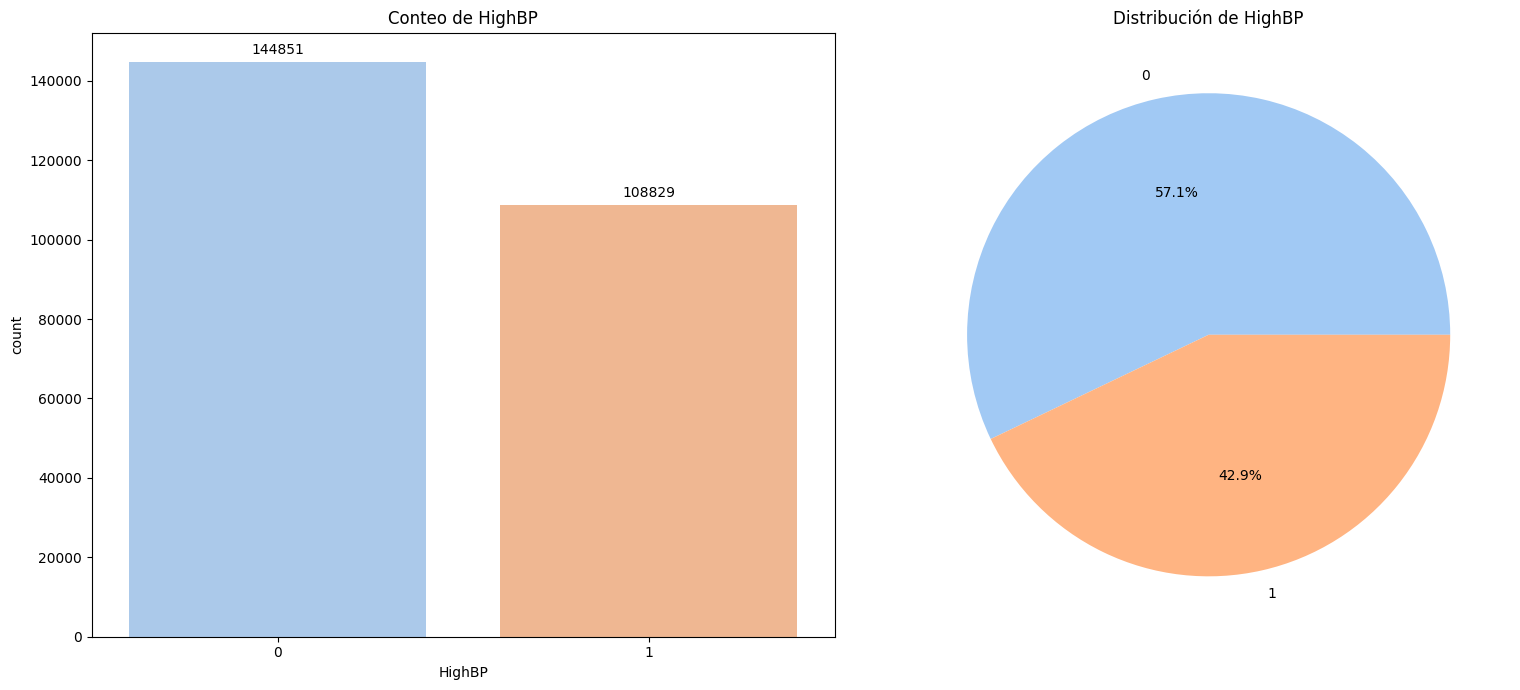

Column: HighChol


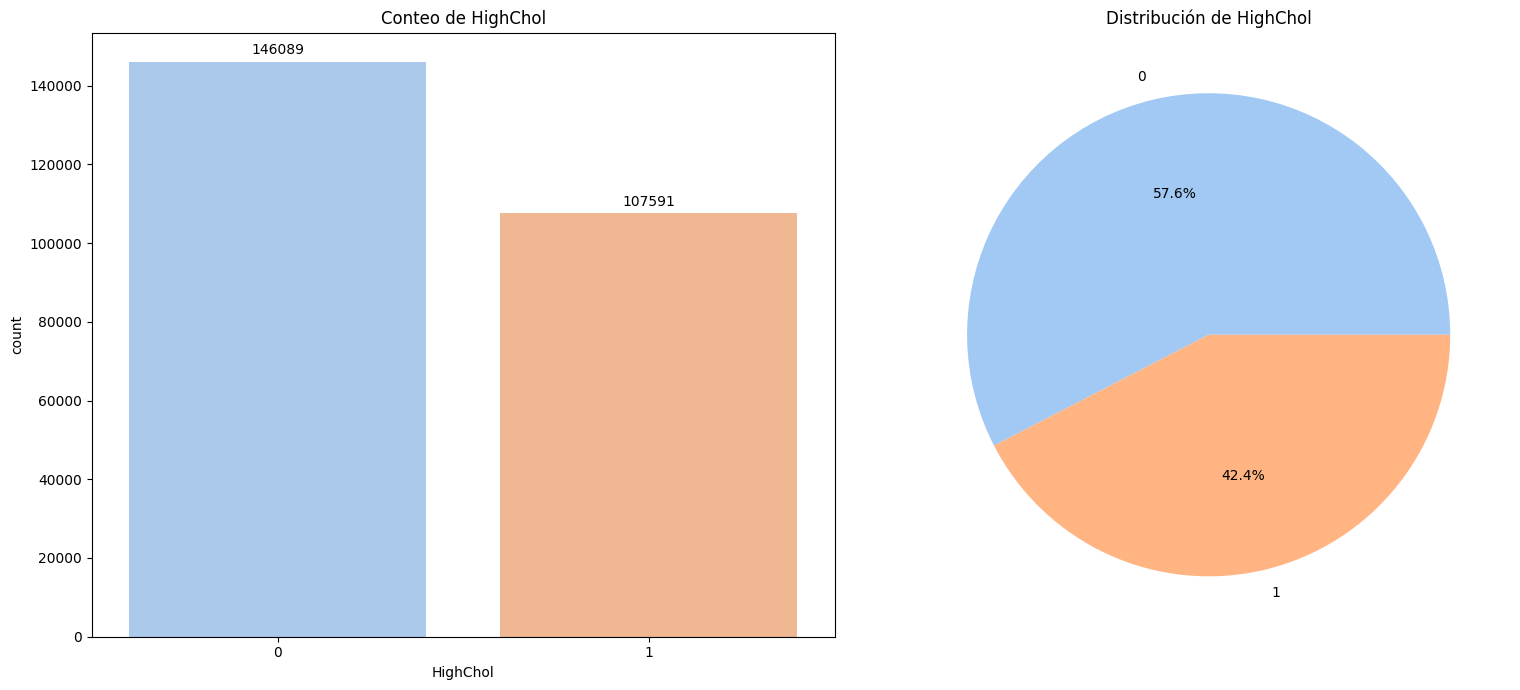

Column: CholCheck


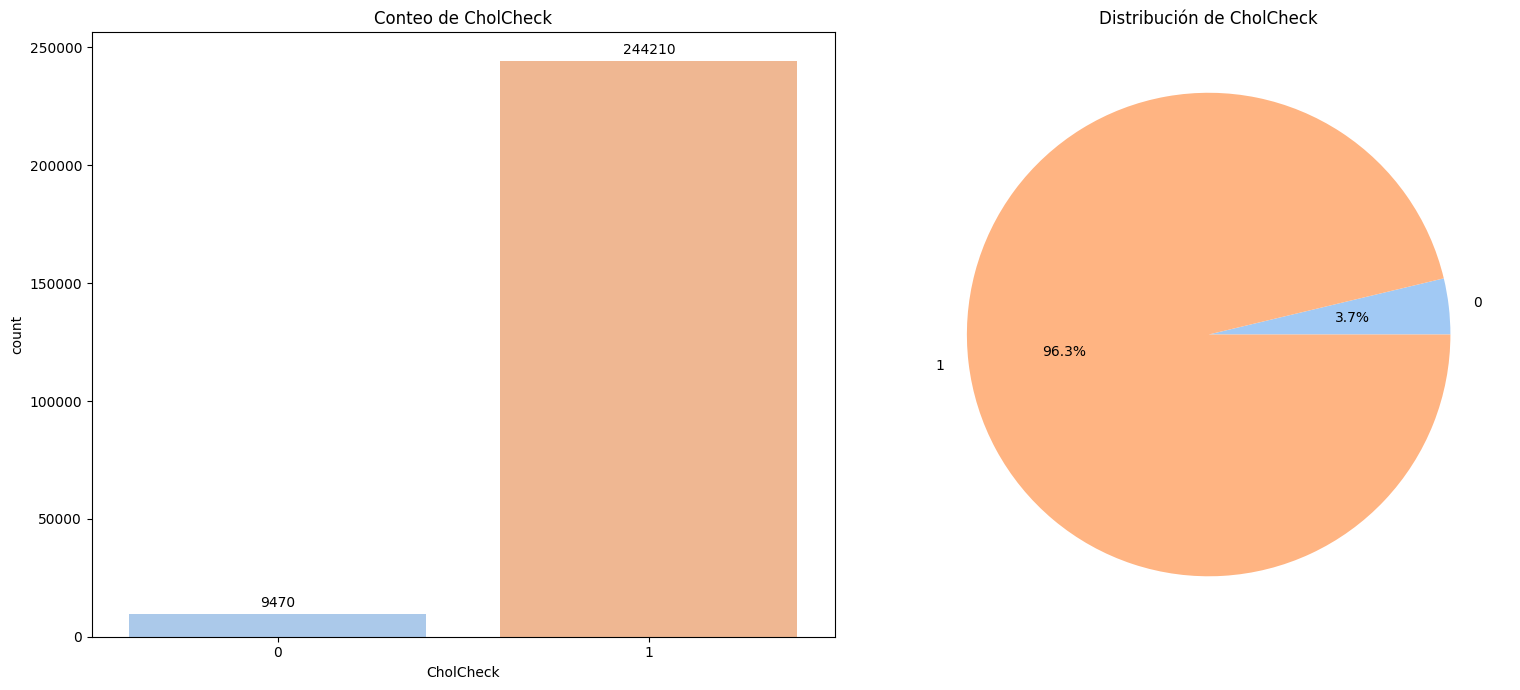

Column: Smoker


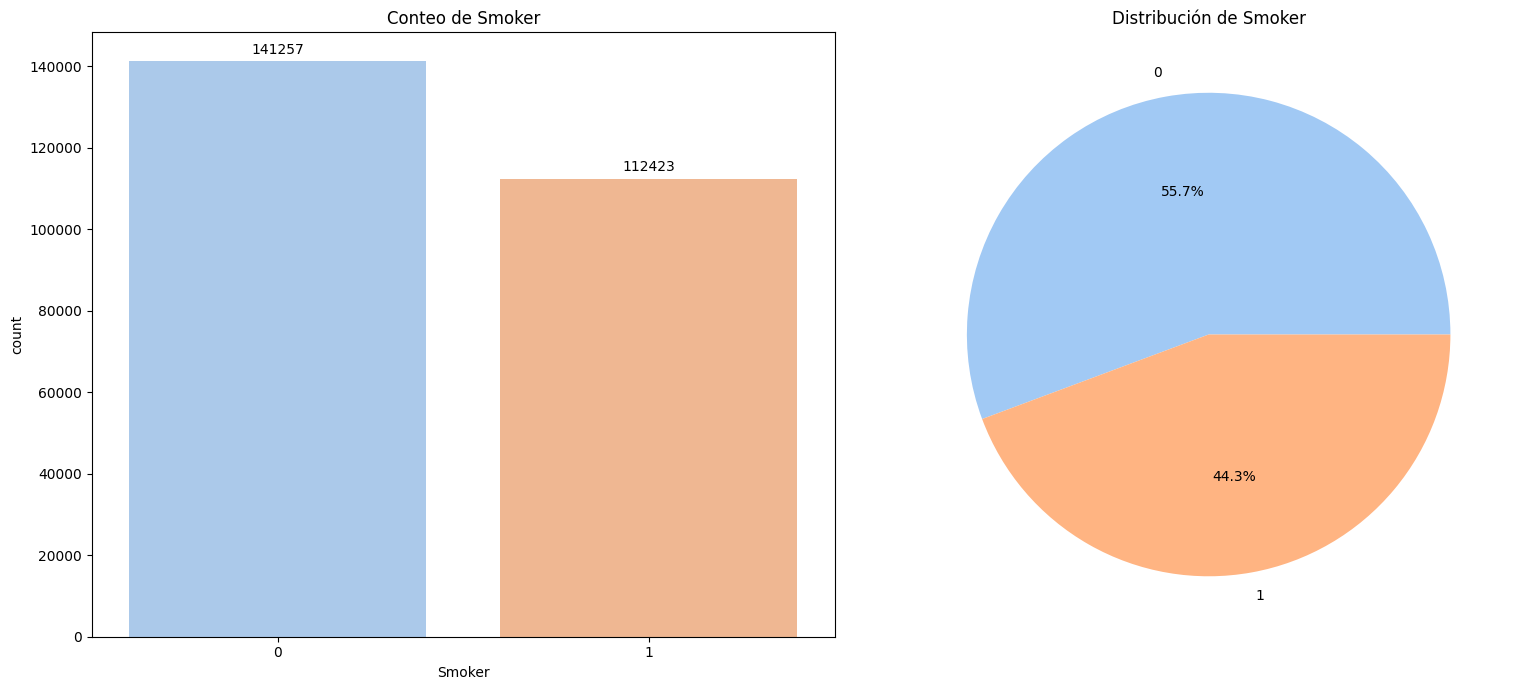

Column: Stroke


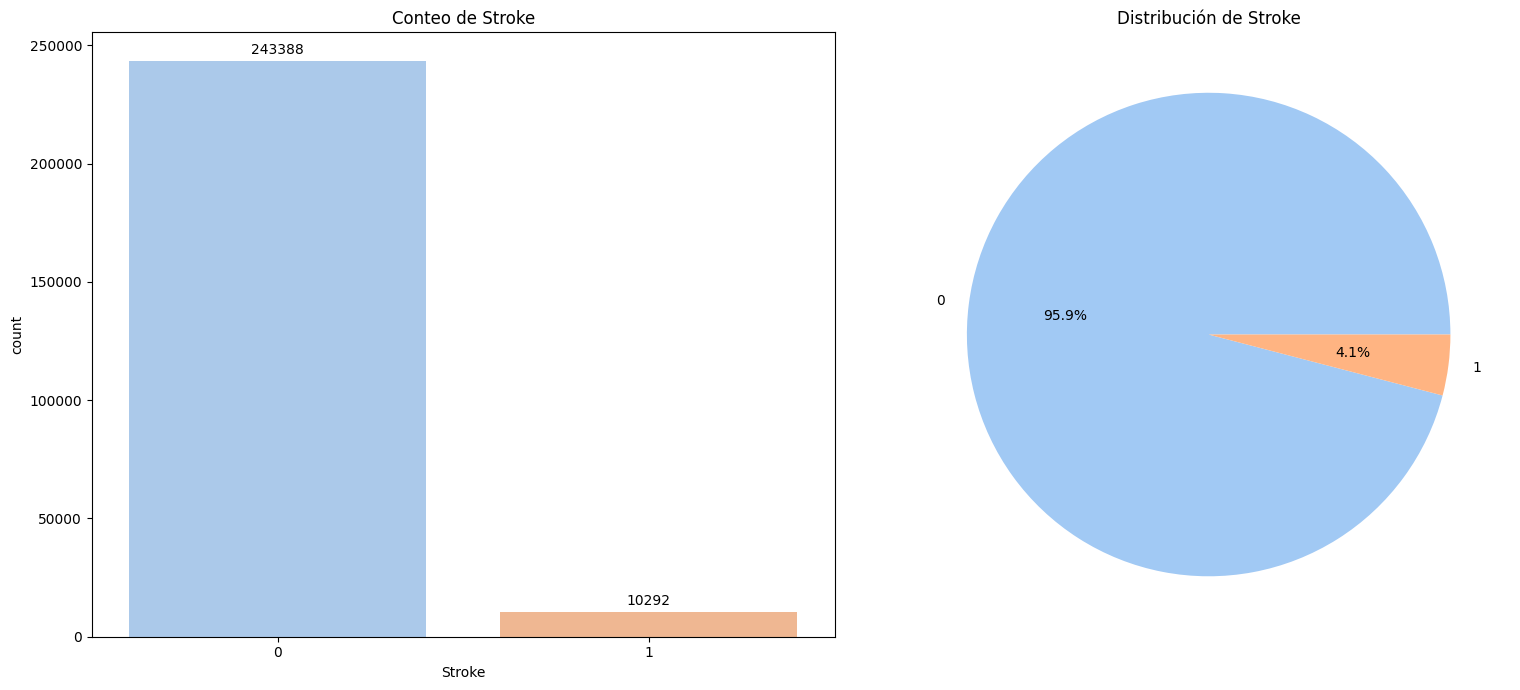

Column: HeartDiseaseorAttack


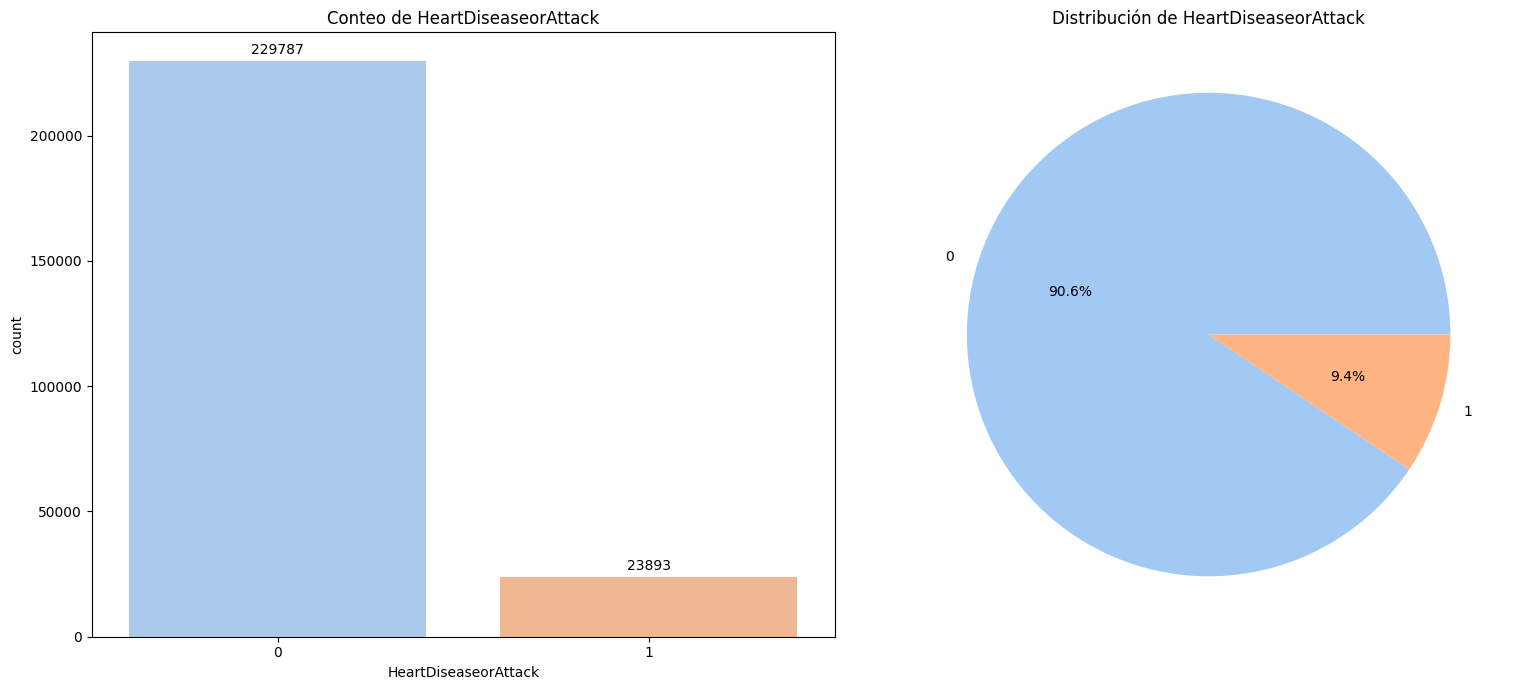

Column: PhysActivity


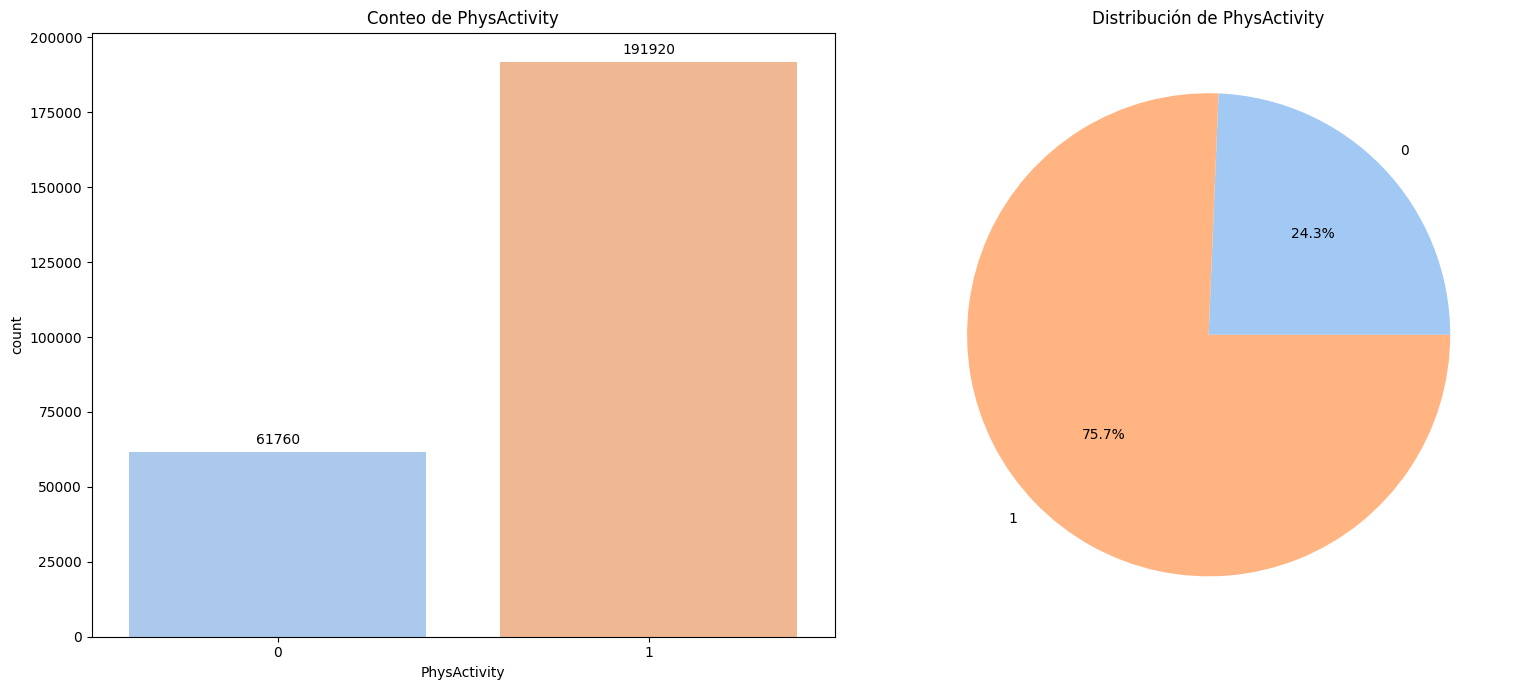

Column: Fruits


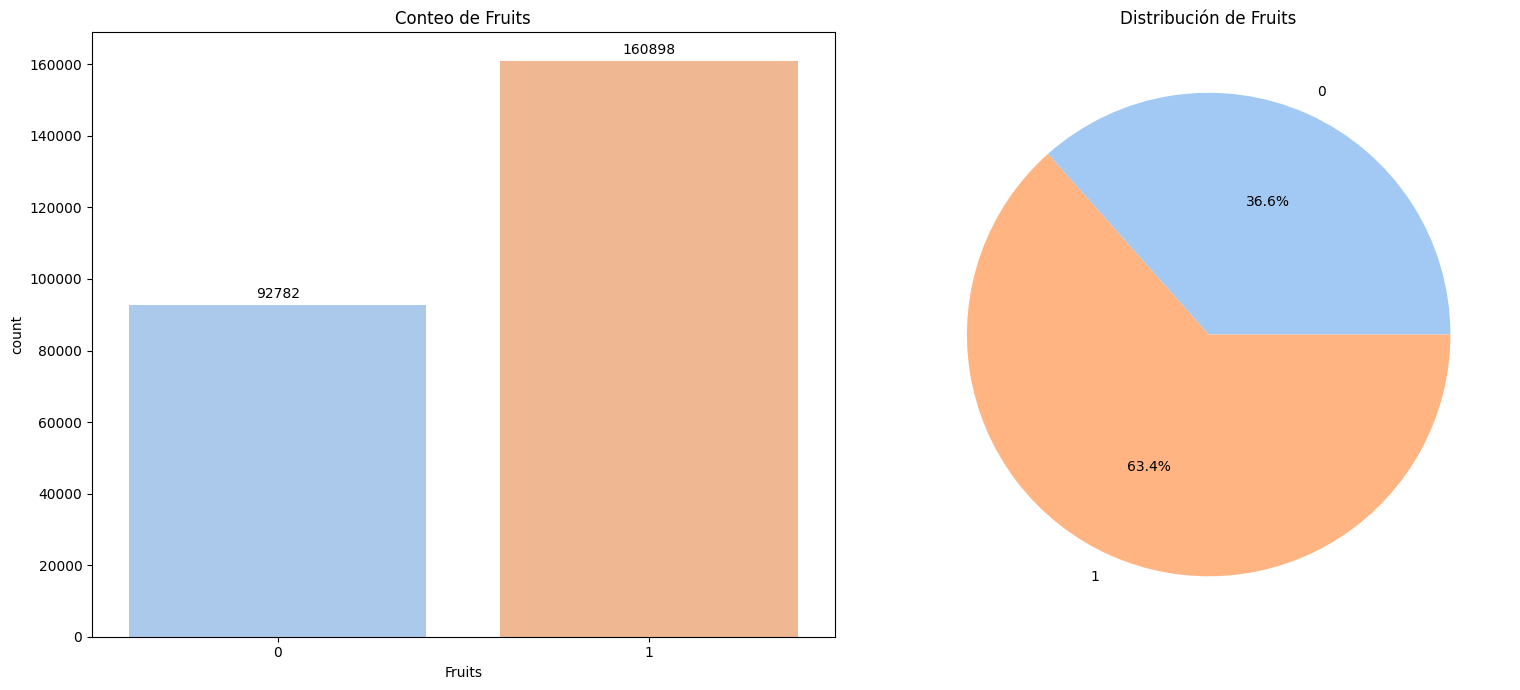

Column: Veggies


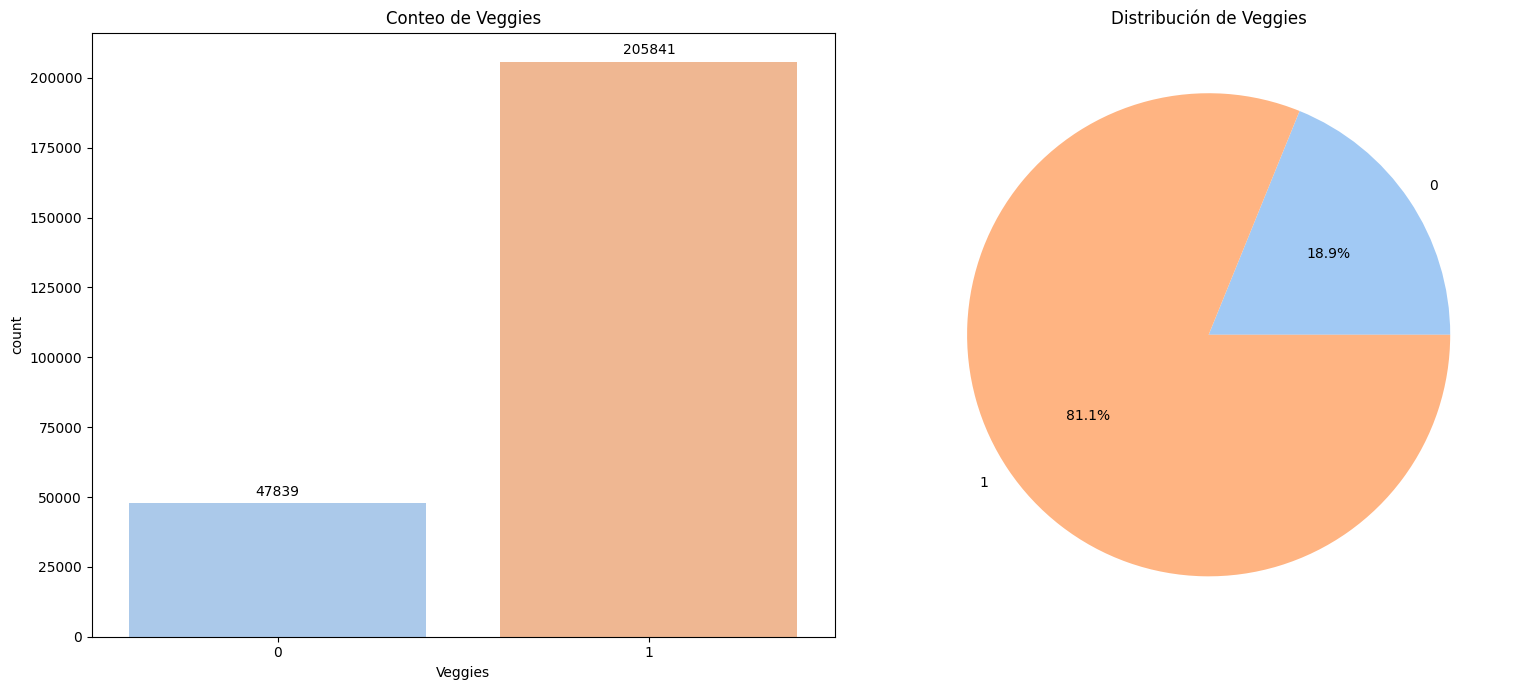

Column: HvyAlcoholConsump


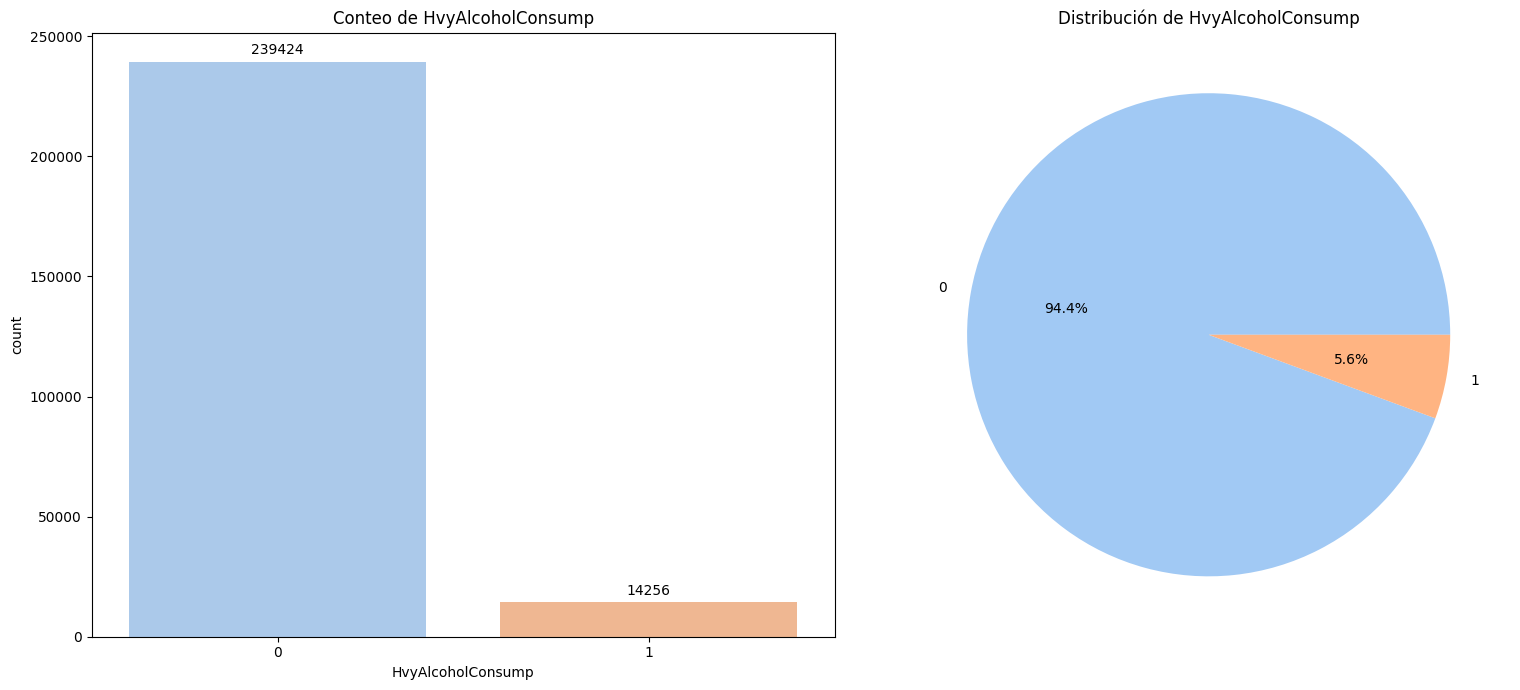

Column: AnyHealthcare


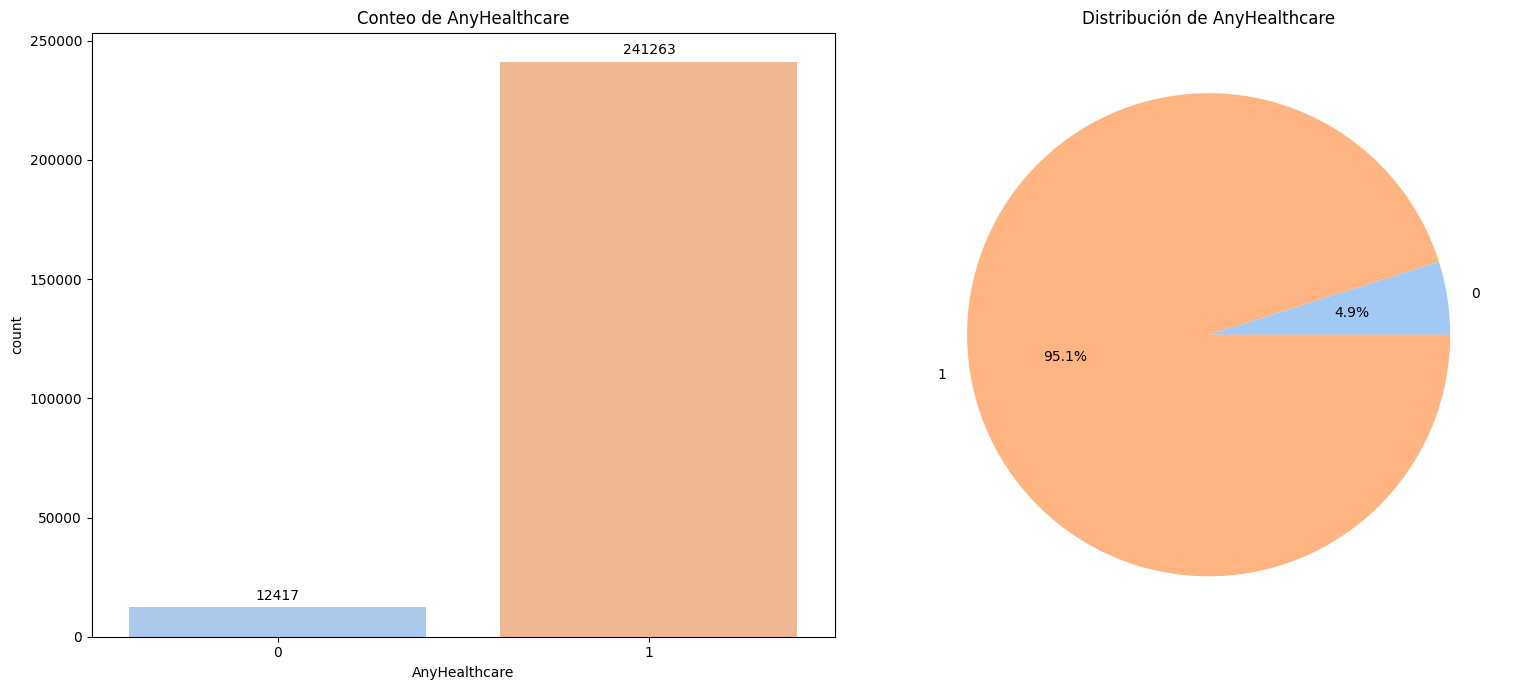

Column: NoDocbcCost


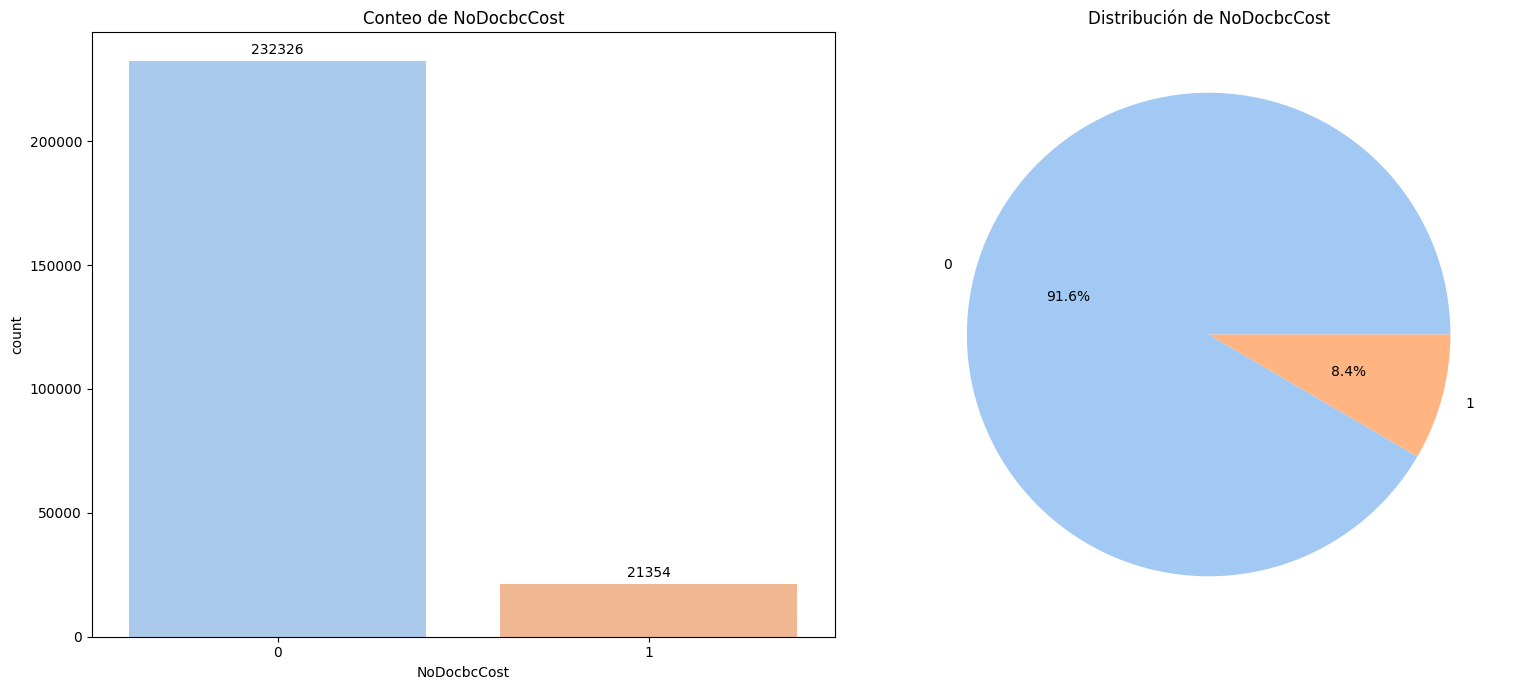

Column: DiffWalk


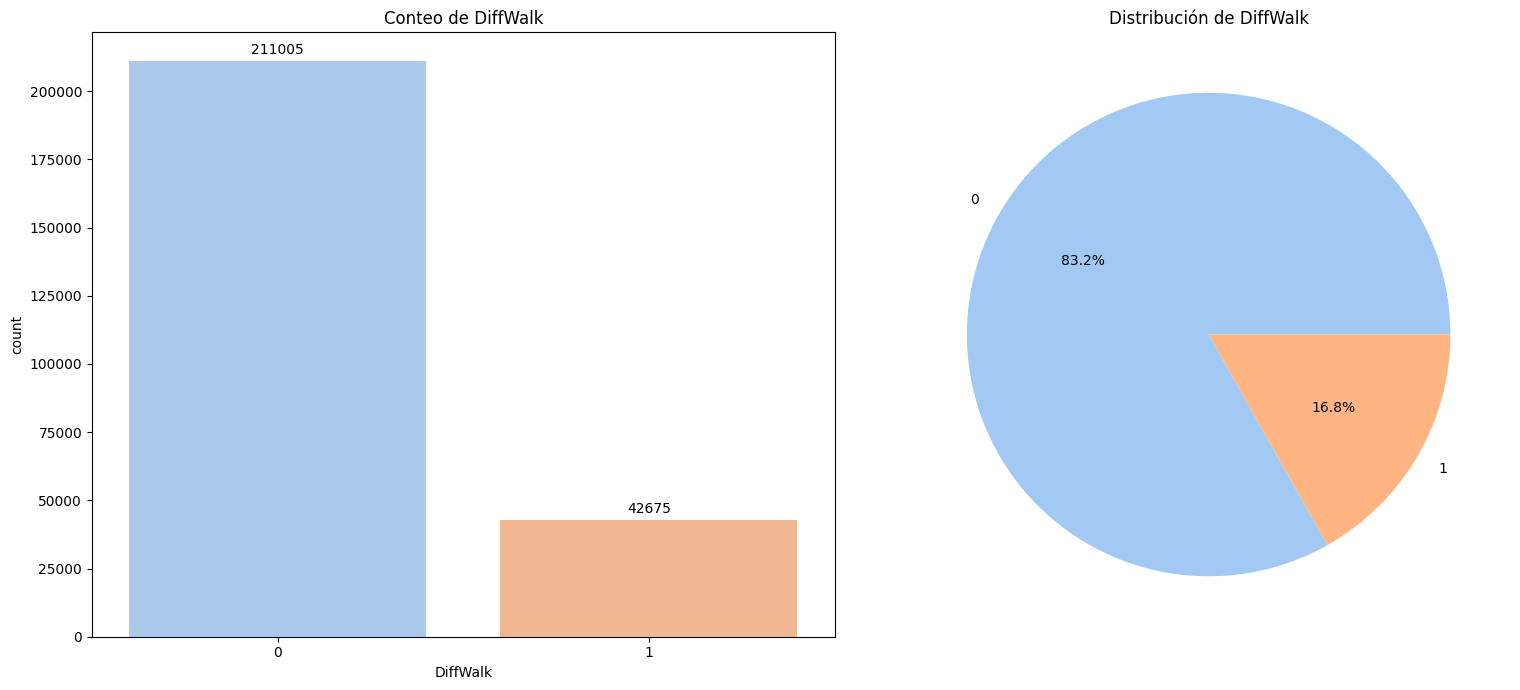

Column: Sex


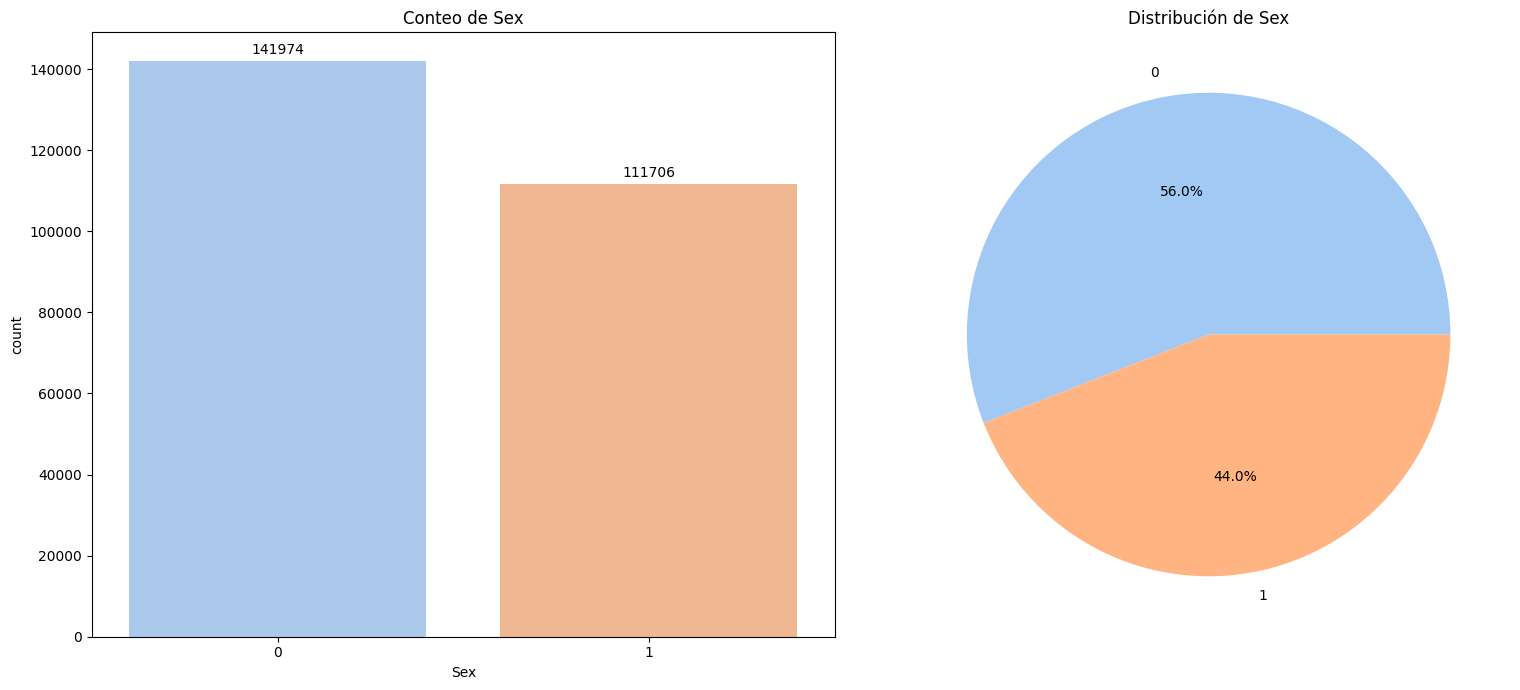

Column: Diabetes_binary


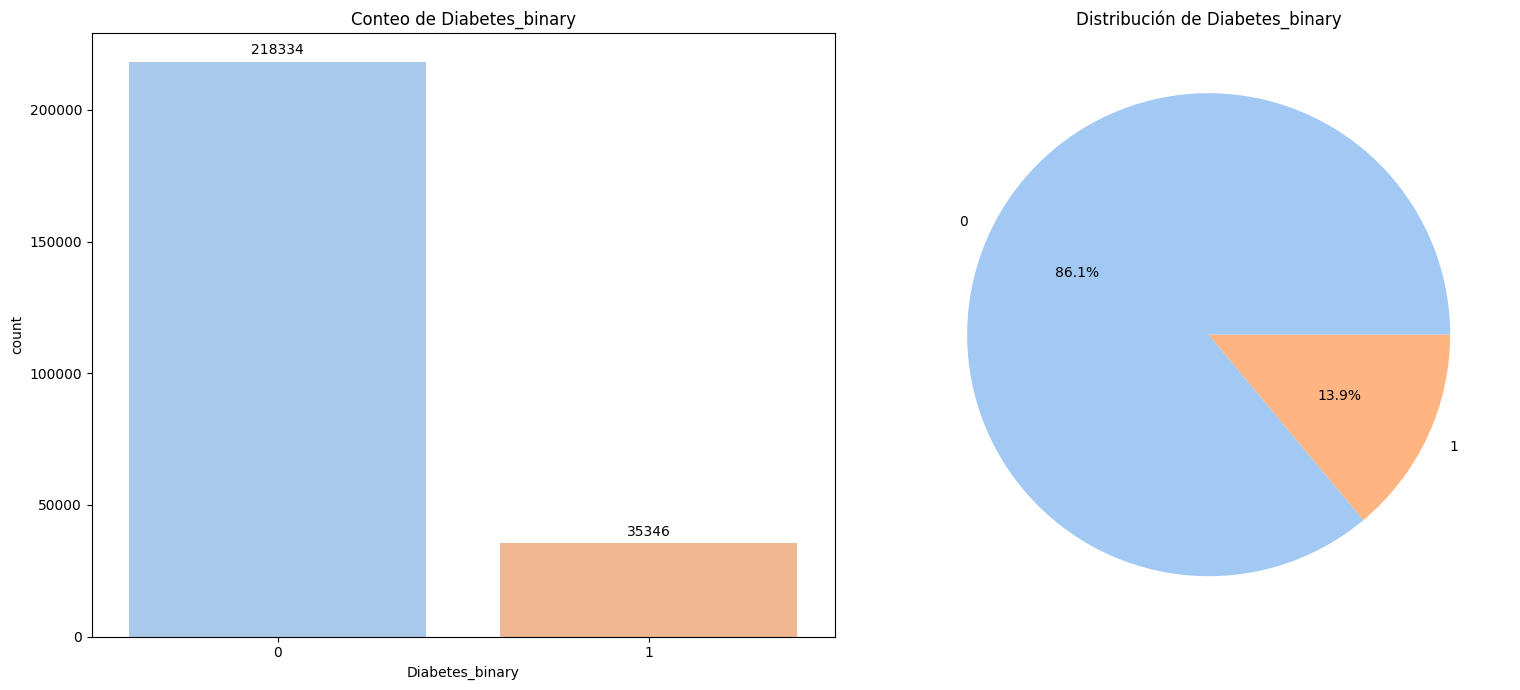

In [78]:
for col in binarias:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    
    # Definir el orden y los colores consistentes
    value_order = sorted(df[col].unique())
    colors = sns.color_palette('pastel')  # Misma paleta para ambos gráficos
    
    # Primer subplot - Gráfico de barras
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    # Añadir los valores encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    
    # Segundo subplot - Diagrama de torta
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order]  # Ordenar los conteos
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors)  # Usar la misma paleta ordenada
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

**Interpretación de Variables Binarias:**

El análisis de las proporciones revela un marcado desbalance en varias variables binarias, lo que tiene implicaciones importantes para el análisis y modelado:

- **Variables con Distribución Relativamente Equilibrada**: Algunas características como `HighBP` (42.9% positivos) y `HighChol` (42.4% positivos) presentan una distribución cercana al equilibrio, lo que facilita su análisis sin necesidad de ajustes especiales. Esto sugiere que estas condiciones son comunes en la población estudiada, lo que podría reflejar factores de riesgo prevalentes en el perfil demográfico de la muestra.

- **Desbalance Moderado**: Variables como `Fruits` (36.6% negativos) y `Veggies` (18.9% negativos) muestran un desbalance moderado. Aunque no son extremos, estos casos podrían beneficiarse de técnicas en modelos predictivos para asegurar que la clase minoritaria tenga suficiente representación en las predicciones.

- **Desbalance Extremo**: En contraste, variables como `Stroke` (4.1% positivos), `HvyAlcoholConsump` (5.6% positivos) e incluso la variable objetivo `Diabetes_binary` presentan un desbalance pronunciado, donde la clase positiva es significativamente menor. Esto implica riesgos como:

    - Sesgo en Modelos: Los algoritmos podrían ignorar la clase minoritaria al optimizar la precisión global, subestimando patrones críticos.

    - Sobreajuste: Con tan pocos casos positivos, el modelo podría memorizar ruido en lugar de aprender relaciones generalizables.

### Variables Categóricas

Se generan gráficos de barras para visualizar la distribución de cada variable categórica. Cada gráfico muestra:

- El número absoluto de observaciones (conteo).
- El porcentaje relativo respecto al total.
- Las categorías ordenadas según su escala natural.

Column: GenHlth


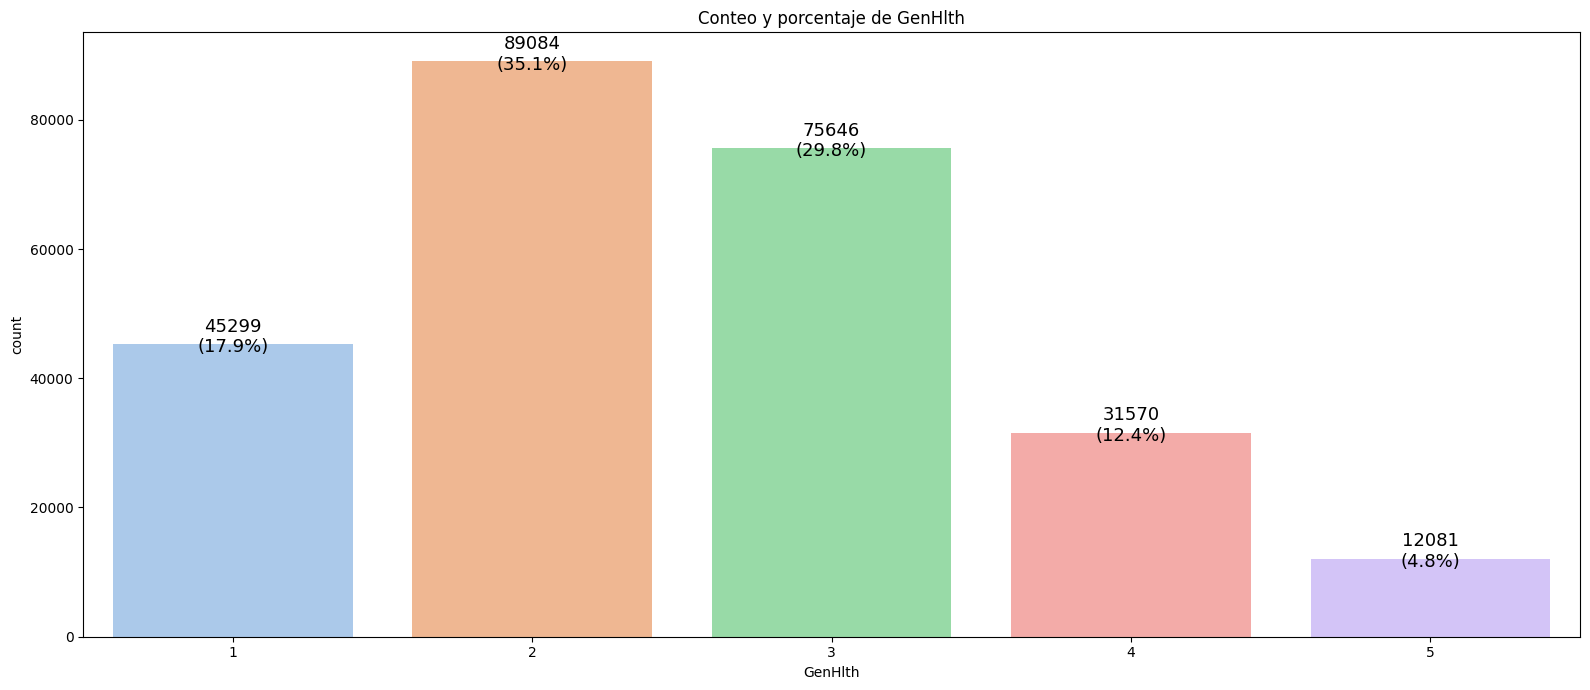

Column: Age


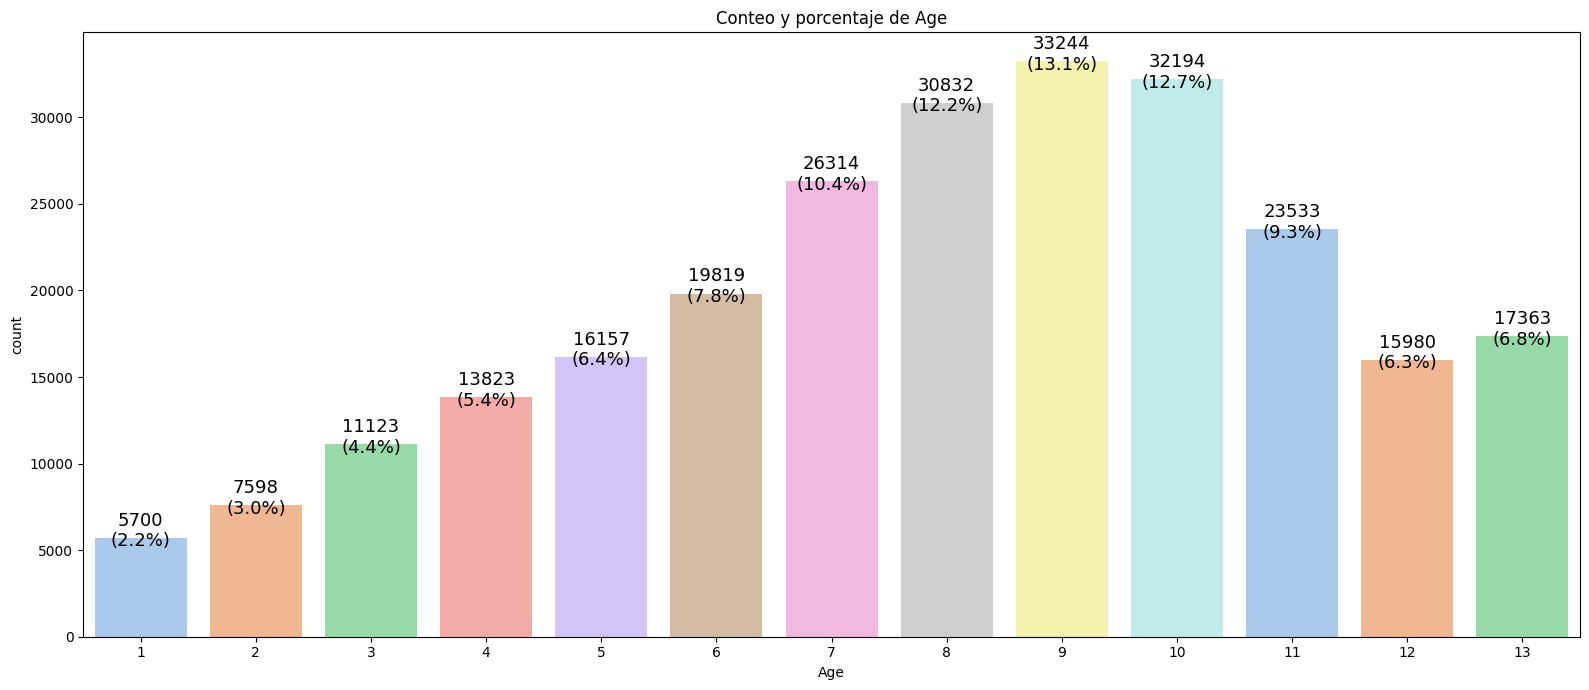

Column: Education


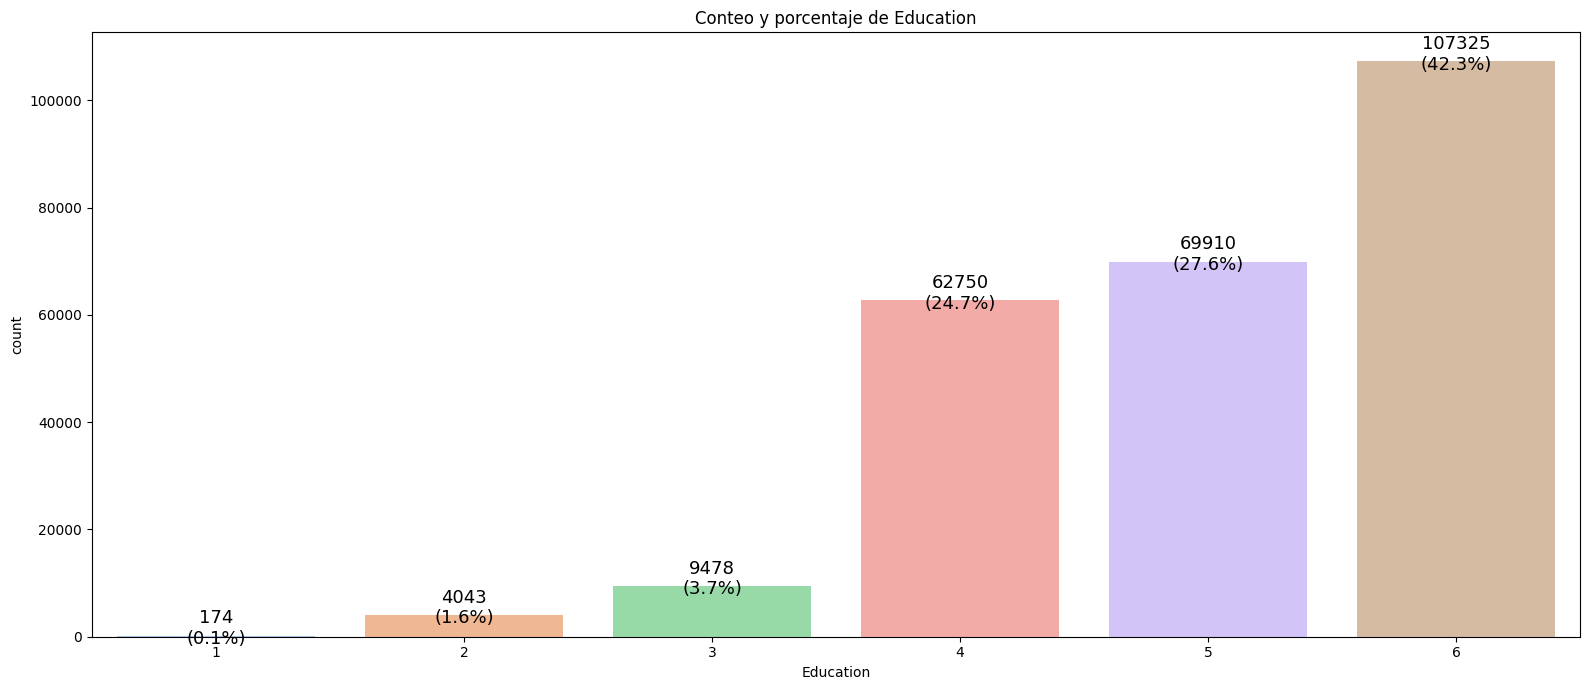

Column: Income


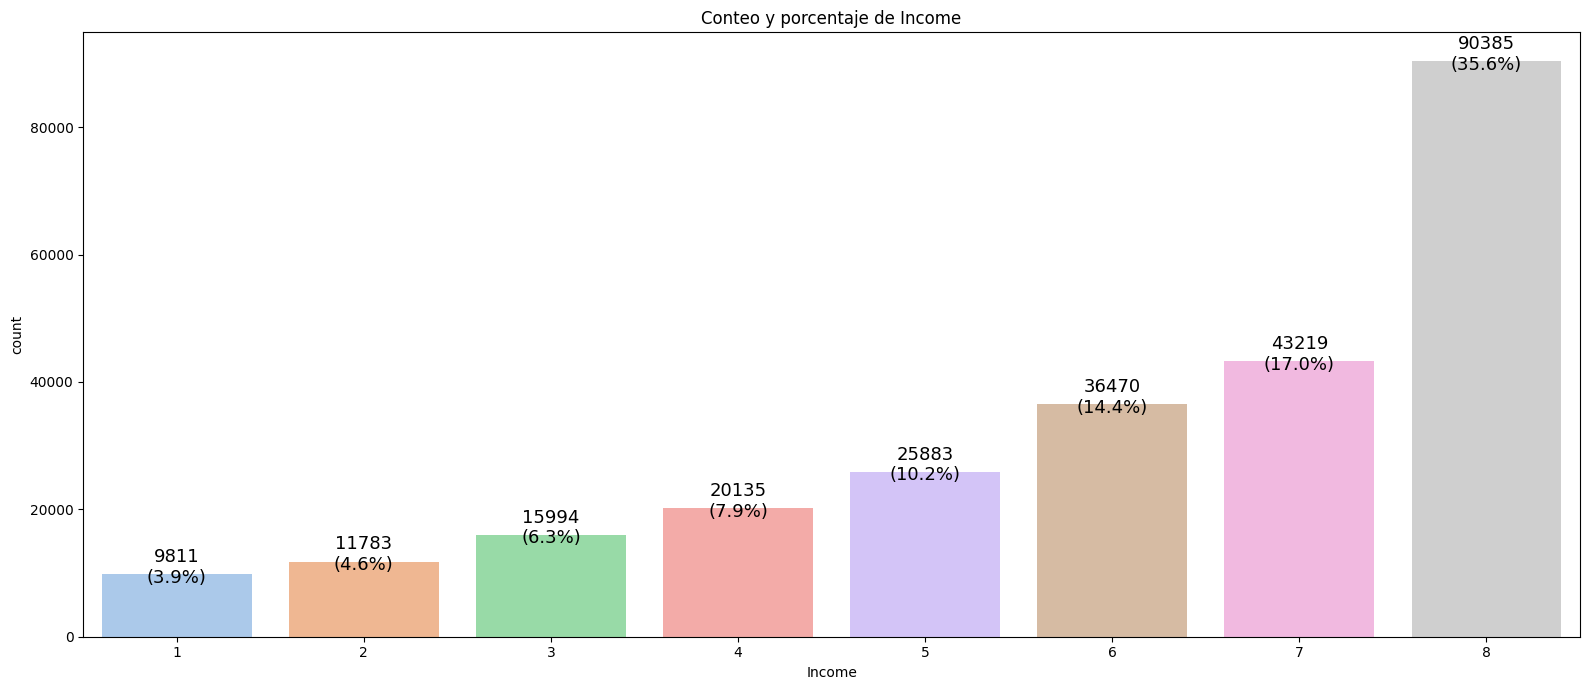

In [79]:
categoricas = ['GenHlth', 'Age', 'Education', 'Income']

for col in categoricas:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    
    # Obtener el orden de las categorías según el diccionario
    value_order = sorted(df[col].unique())  
    
    # Crear el gráfico de barras ordenado
    ax = sns.countplot(x=df[col], order=value_order, palette='pastel')
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * p.get_height() / len(df[col])
        ax.annotate(f'{count}\n({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=13)
    plt.title(f'Conteo y porcentaje de {col}')
    
    plt.tight_layout()
    plt.show()
  

**Interpretación de Variables Categóricas:**

El análisis de las distribuciones revela patrones demográficos y socioeconómicos clave en la población estudiada:

- `GenHlth`
La distribución muestra una tendencia hacia percepciones positivas de salud: el 53.0% de los encuestados reporta salud "muy buena" (35.1%) o "excelente" (17.9%), mientras solo el 4.8% la califica como "pobre".

- `Age`
 Se observa una concentración alta en edades entre 50 y 69 años (grupos 7 a 10), lo cual sugiere que la mayoría de los participantes o casos en este conjunto de datos son personas de mediana edad a adultos mayores. Los grupos con menor representación son:
    - 18–24 años (grupo 1): 5,700 personas (2.2%).
    - 25–29 años (grupo 2): 7,598 personas (3.0%),
Esto indica que hay menos jóvenes en el conjunto de datos, posiblemente porque se trata de una muestra relacionada con condiciones de salud que afectan más a personas mayores.

-  `Education`
Se observa una marcada sobrerrepresentación de educación superior: el 42.3% corresponde a graduados universitarios (categoría 6), seguido por "algo de universidad" (27.6%). Esto se evidencia al compararlo con el 0.1%, 1.6% y 3.7% de las categorias 1, 2 y 3 respectivamente. Este perfil sugiere un sesgo de selección hacia población con mayor acceso a educación, lo que podría limitar la generalización de hallazgos a grupos menos educados.

- `Income`
La distribución económica muestra una concentración en la clase media-alta: el 35.6% pertenece a la categoría más alta, seguido por la segunda categoría mas alta con 17%. Esta estructura, combinada con los datos educativos, refuerza la hipótesis de que la muestra subrepresenta poblaciones vulnerables.

### Variables Númericas

Se genera una tabla para visualizar algunos estadísticos descriptivos para las variables númericas.

In [80]:
df[['MentHlth', 'PhysHlth','BMI']].describe().T

,count,mean,std,min,25%,50%,75%,max
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0


**Interpretación de Variables Númericas:**

- `MentHlth`: Los participantes reportaron un promedio de 3.18 días con salud mental afectada en los últimos 30 días. Con una desviación estándar de 7.41 días, indicando una variabilidad moderada en las respuestas.
- `PhysHlth`: El promedio fue ligeramente mayor (4.24 días), sugiriendo que los problemas físicos son más frecuentes que los mentales en esta muestra. Con una dispersión mayor (desviación estándar de 8.72 días), lo que sugiere que los problemas físicos muestran mayor variabilidad entre los individuos.

Ambas variables comparten un patrón similar en los percentiles:
- **25% inferior**: 0 días de afectación.
- **Mediana (50%)**: 0 días.
- **75% superior**: 2 días para salud mental y 3 días para salud física.

Este patrón revela que la mayoría de la población (al menos 50%) no reportó días con problemas de salud.

- `BMI`: El Índice de Masa Corporal (BMI) muestra una media de 28.38 y una desviación estándar de 6.61, indicando que la mayoría de los valores se agrupan alrededor de 28.38, con una dispersión moderada. La distribución está sesgada hacia valores más altos.
    - **Mediana (50%)**: 27.0 < Media (28.38), lo que sugiere una cola derecha (presencia de valores atípicos altos).
    - **Rango intercuartílico (IQR)**: 7.0 (Q3-Q1 = 31.0 - 24.0), capturando el 50% central de los datos.
    - **Valores extremos**: El mínimo (12.0) y máximo (98.0) son atípicos, especialmente el máximo (98.0), que está muy alejado del percentil 75% (31.0).

---

Se genera un histograma y un boxplot para visualizar la distribución de frecuencias e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.

Column: MentHlth
Skew: 2.72
Kurtosis:  6.44
Coeficiente de Variación:  232.76 %


<Figure size 1600x700 with 0 Axes>

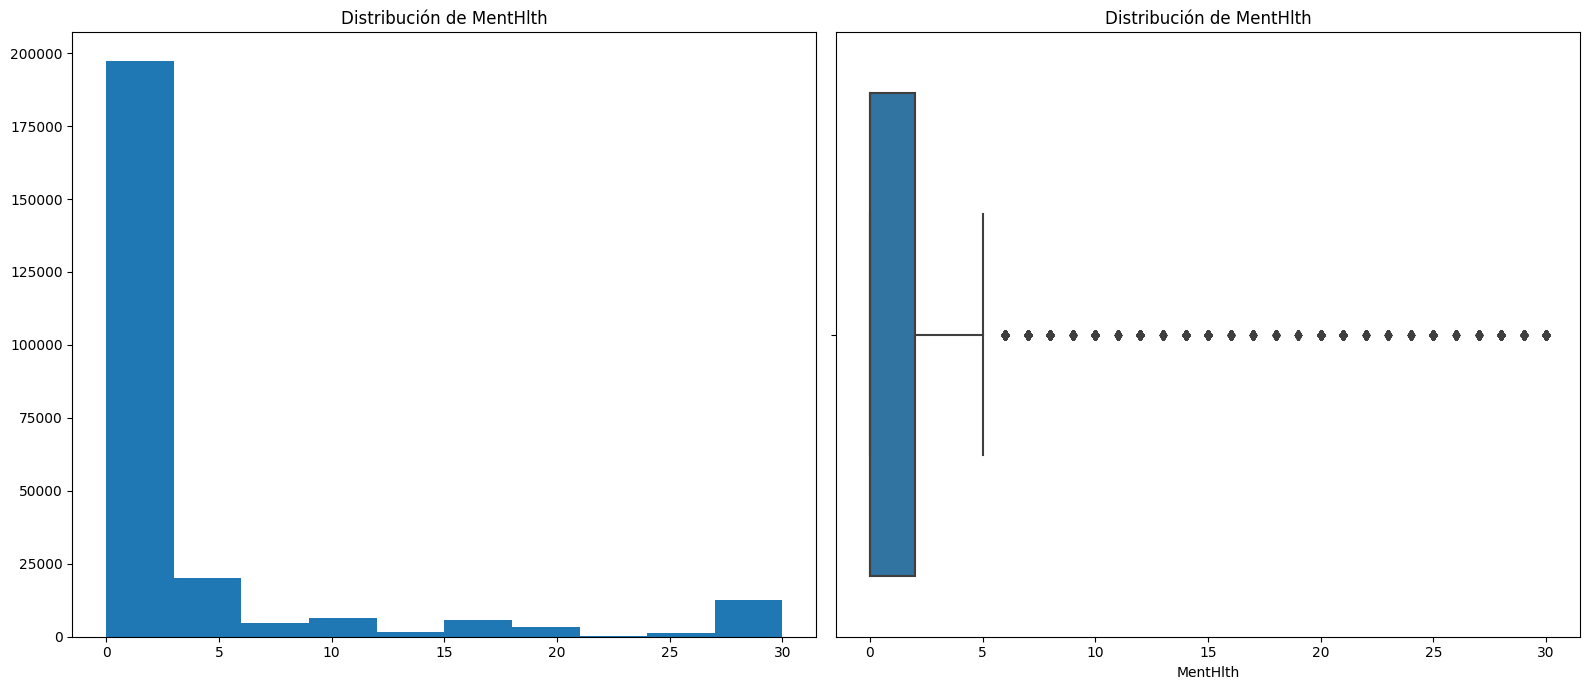

Column: PhysHlth
Skew: 2.21
Kurtosis:  3.5
Coeficiente de Variación:  205.51 %


<Figure size 1600x700 with 0 Axes>

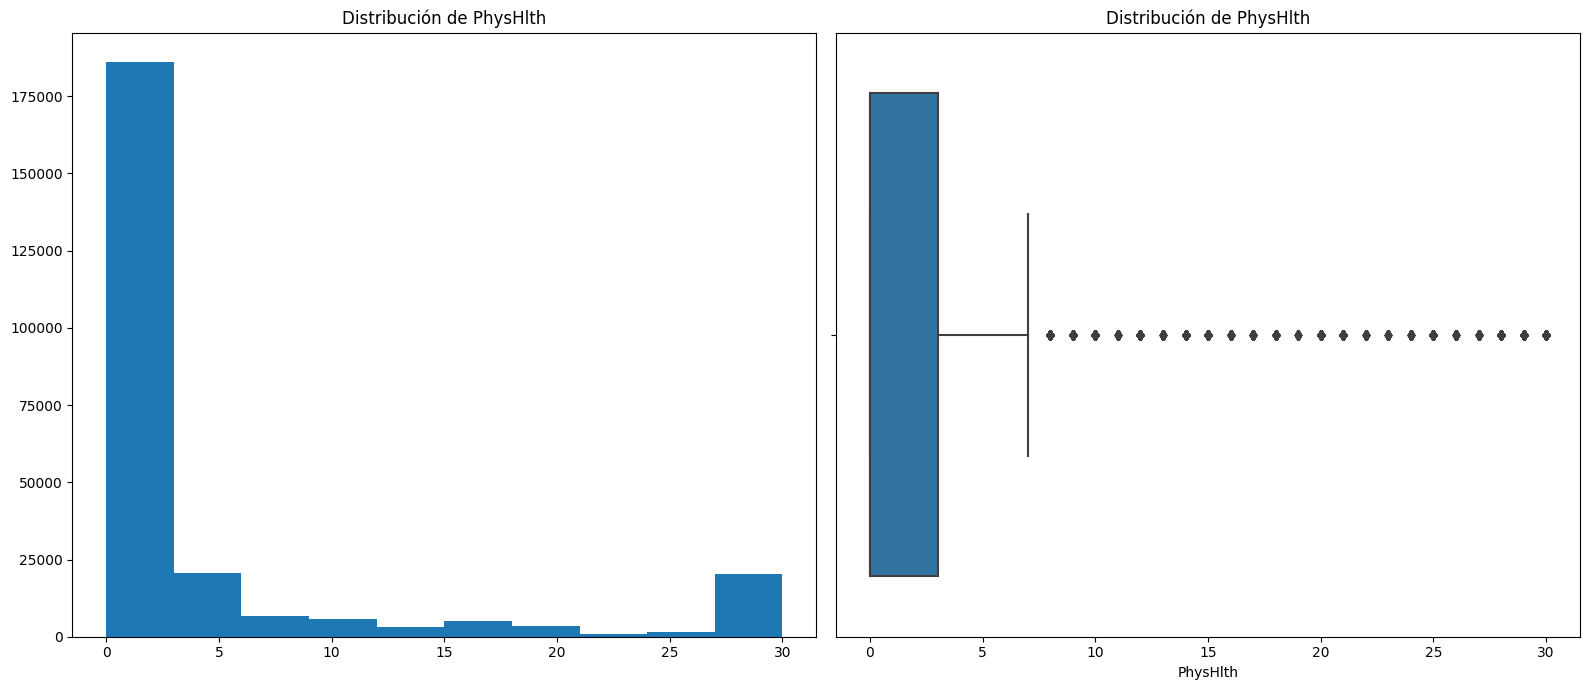

Column: BMI
Skew: 2.12
Kurtosis:  11.0
Coeficiente de Variación:  23.28 %


<Figure size 1600x700 with 0 Axes>

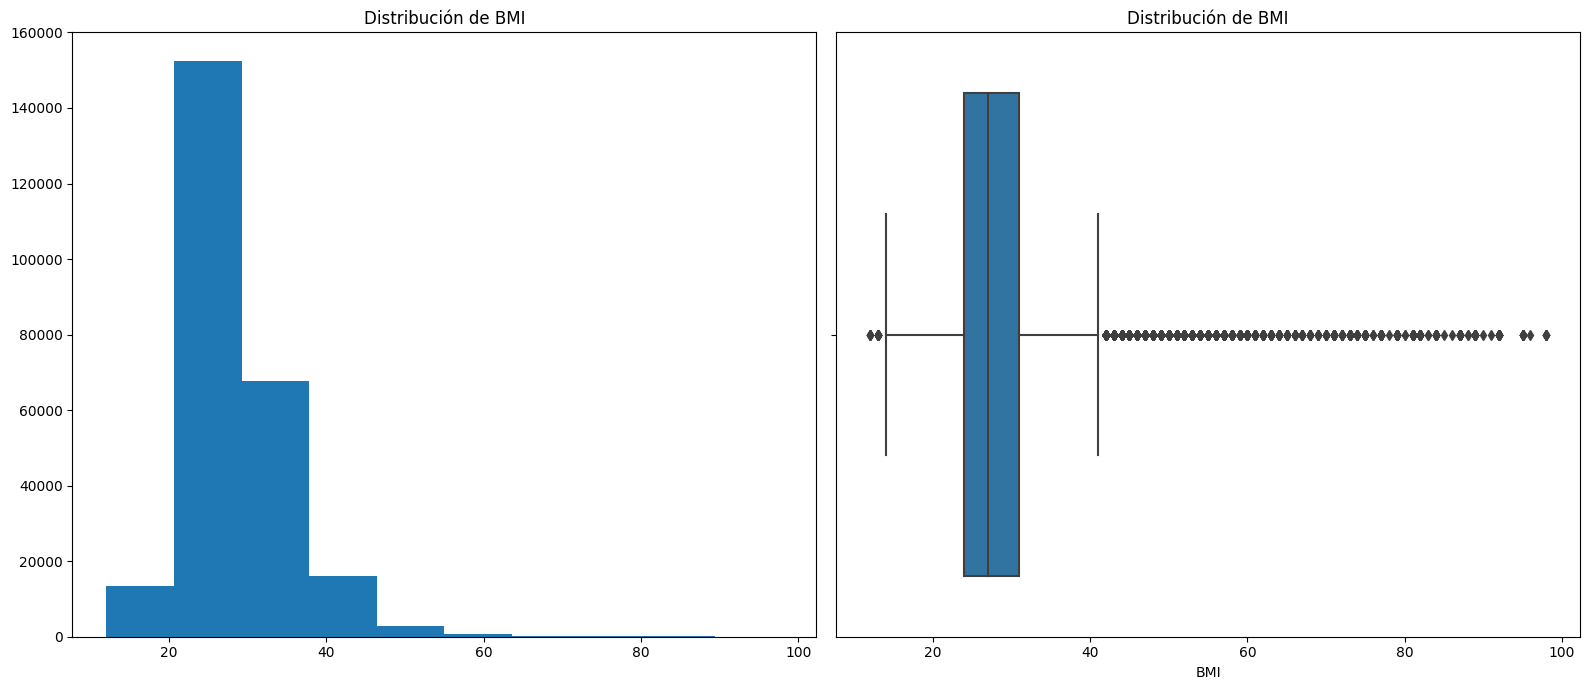

In [81]:
numericas = ['MentHlth', 'PhysHlth', 'BMI']

from scipy.stats import kurtosis

for col in numericas:
    print('Column:', col)
    plt.figure(figsize=(16, 7))
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    plt.figure(figsize = (16, 7))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False)
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

**Interpretación de Variables Númericas:**

Los datos muestran que la variable `MentHlth` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.72) con una kurtosis elevada (6.44), indicando:
- Una concentración extrema de valores bajos (cerca de 0 días).
- Una larga cola hacia valores altos.
- Presencia significativa de outliers, como evidencia el boxplot.
Esta distribución sugiere que la mayoría de la población reporta pocos o ningún día de afectación mental, mientras que un pequeño grupo muestra afectación persistente.

La variable `PhysHlth` también muestra sesgo positivo (skewness = 2.21) pero con una kurtosis menos pronunciada (3.5), lo que revela:
- Similar concentración en valores bajos.
- Cola derecha menos extrema que MentHlth.
- Menor cantidad de outliers extremos.

Los datos muestran que la variable `BMI` presenta una distribución fuertemente sesgada a la derecha (skewness = 2.12) con una kurtosis muy elevada (11.0), lo que indica:
- Una concentración extrema de valores en el rango bajo a moderado (probablemente entre 20-30).
- Una cola derecha muy larga que se extiende hacia valores altos de BMI.
- Presencia significativa de outliers extremos en los valores superiores.

Esta distribución sugiere que:
- La mayoría de la población tiene valores de BMI dentro del rango normal o ligeramente elevado.
- Existe un grupo más pequeño pero significativo con obesidad moderada.
- Un grupo muy reducido presenta valores extremadamente altos (obesidad mórbida).

La kurtosis excepcionalmente alta (11.0 vs 3.5 en `PhysHlth`) indica que:
- Los datos están mucho más concentrados alrededor de la media que en una distribución normal.
- Las colas son más pesadas de lo esperado.
- Los outliers son más extremos que en otras variables de salud analizadas.

Comparado con `MentHlth` y `PhysHlth`:
- El sesgo es similar pero ligeramente menos pronunciado.
- La kurtosis es notablemente más alta, mostrando mayor concentración en valores centrales.
- Los outliers parecen ser más extremos en BMI que en las variables de salud mental/física, debido a que en las variables de percepción el rango va desde 0 a 30 días del mes, en cambio el BMI no tiene limite.


### Análisis de Valores Atípicos en BMI

Para la identificación de valores atípicos en la variable `BMI`, se aplicó el método del rango intercuartílico (IQR). 

In [82]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['BMI'] < limite_inferior) | (df['BMI'] > limite_superior)]
print(f"Número de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {len(outliers)/len(df)*100:.2f}%")

Número de outliers: 9847
Porcentaje de outliers: 3.88%


---
Para el tratamiento de valores atípicos en la variable `BMI`, se aplicó la técnica de winsorización al 1% en el extremo superior de la distribución. Este método fue seleccionado por: 

- Su capacidad para preservar el tamaño completo de la muestra.

- Mantener la distribución general de los datos. 

- Minimizar el impacto de valores extremos y por ser conservador con la información original. 

El nivel del 1% se determinó en base al análisis previo de outliers, que mostró un 3.88% de valores atípicos, permitiendo un tratamiento balanceado que aborda la mayoría de los casos extremos sin alterar significativamente la estructura de los datos.

In [83]:
df['BMI'] = winsorize(df['BMI'], limits=[0, 0.01])
y_reg = df['BMI']

Se verifican los cambios realizados.

In [84]:
df['BMI'].describe().T

count    253680.000000
mean         28.277681
std           6.049009
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          50.000000
Name: BMI, dtype: float64

**Interpretación**

1. **Reducción de la desviación estándar**: 
   - De 6.61 a 6.05 (-8.5%).
   - Indica menor dispersión y datos más homogéneos, pero manteniendo variabilidad.

2. **Rango corregido**:
   - Mínimo: Se mantuvo en 12.0 (se preservaron valores bajos clínicamente relevantes).
   - Máximo: De 98.0 a 50.0 (dentro de rangos médicos realistas).
   - Se conservaron casos de bajo peso que podrían ser clínicamente válidos según la literatura.

3. **Media ajustada**:
   - De 28.38 a 28.28 (-0.10 puntos).
   - Cambio mínimo, lo que indica que la distribución central se mantuvo intacta.

Lo que se mantuvo estable:
- Mediana (50%): 27.0 → 27.0 (sin cambios).
- Primer cuartil (25%): 24.0 → 24.0 (sin cambios).  
- Tercer cuartil (75%): 31.0 → 31.0 (sin cambios).
- Tamaño de muestra: 253,680 → 253,680 (preservado).

La winsorización superior al 1% fue exitosa porque:
- Eliminó valores extremos clínicamente improbables en el extremo superior (BMI 98).
- Preservó valores bajos que pueden representar casos reales de bajo peso o desnutrición.
- Preservó completamente la distribución central (cuartiles idénticos).
- Mantuvo el tamaño de la muestra original.
- Redujo la varianza sin distorsionar la tendencia central.
- Los nuevos límites superiores (50) están dentro de rangos médicamente posibles mientras se conserva la variabilidad natural en valores bajos.

---
Se genera un histograma y un boxplot para visualizar la nueva distribución de frecuencias y dispersión de los datos.

Column: BMI
Skew: 1.06
Kurtosis:  1.48
Coeficiente de Variación:  21.39 %


<Figure size 1600x700 with 0 Axes>

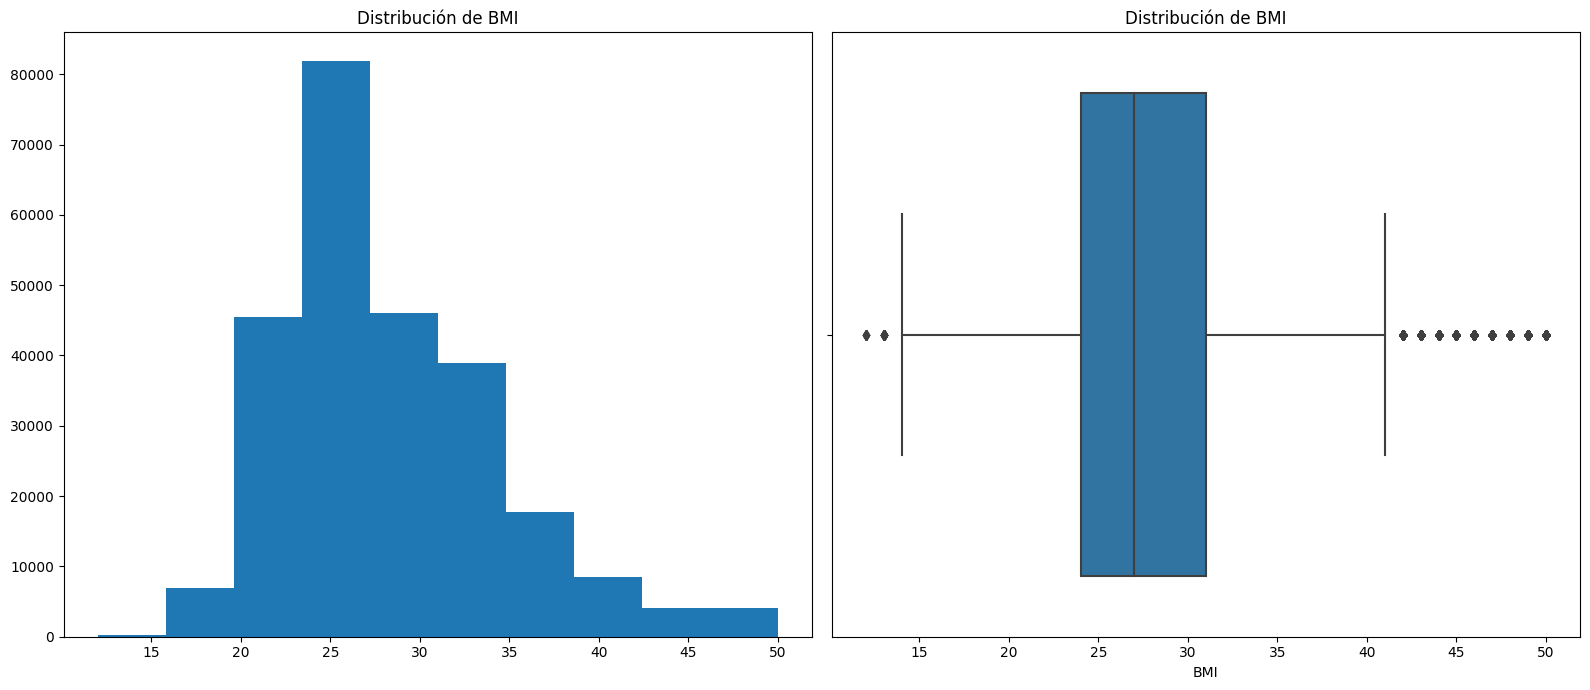

In [85]:
print('Column: BMI')
plt.figure(figsize=(16, 7))
print('Skew:', round(df['BMI'].skew(), 2))
print('Kurtosis: ', round(df['BMI'].kurtosis(), 2))
coef_variacion = (df['BMI'].std()/ df['BMI'].mean() ) * 100
print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
plt.figure(figsize = (16, 7))
plt.subplot(1, 2, 1)
df[col].hist(grid=False)
plt.title(f'Distribución de BMI')
plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f'Distribución de BMI')
plt.tight_layout()
plt.show()

**Interpretación**

1. **Reducción de asimetría (Skewness)**:
    - De 2.12 a 1.06 (-50% de reducción).
    - Interpretación: La distribución era altamente sesgada a la derecha (valores extremos altos) y ahora tiene un sesgo moderado.
    - Significado: Los valores extremos hacia la derecha (BMI altos) fueron tratados efectivamente, pero se preservó mayor asimetría natural al mantener los valores bajos intactos.

2. **Mejora en curtosis (Kurtosis)**:
    - De 11.0 a 1.48 (-86.5% de reducción).
    - Interpretación: Pasó de una distribución extremadamente leptocúrtica (pico muy agudo y colas pesadas) a una distribución ligeramente leptocúrtica.
    - Significado: Las colas extremadamente pesadas fueron eliminadas en su mayoría, pero se mantuvo cierta curtosis al preservar la variabilidad natural en el extremo inferior.

Comparación con una distribución normal:
- Skewness ideal: 0 (perfectamente simétrica).
- Kurtosis ideal: 0 (mesocúrtica, como la normal).
- Nuevos valores: 1.06 (skew) y 1.48 (kurtosis) → Más cercanos a la normalidad que el original, pero con mayor preservación de la distribución natural.

La winsorización superior al 1% fue exitosa porque:
- Transformó una distribución altamente no-normal en una moderadamente no-normal.
- Preservó la variabilidad natural en valores bajos que pueden ser clínicamente relevantes.
- Eliminó los valores extremos superiores que causaban las colas pesadas.
- Mejoró significativamente las propiedades estadísticas para modelamiento manteniendo mayor autenticidad en la distribución.

La variable BMI ahora es adecuada para: Modelos que requieren menor influencia de outliers extremos, mientras se preserva la información clínica potencialmente valiosa en el rango inferior.

## Análisis Bivariado
El análisis bivariado es la segunda fase del análisis exploratorio de datos. Se enfoca en las relaciones entre dos variables para obtener datos estadísticos sobre sus influencias mutuas.

### Variables Binarias vs Diabetes

Se generan graficos de barras para analizar la relación entre un conjunto de variables binarias y la presencia de diabetes con el fin de identificar qué variables binarias están asociadas a mayores proporciones de diabetes en el conjunto de datos.

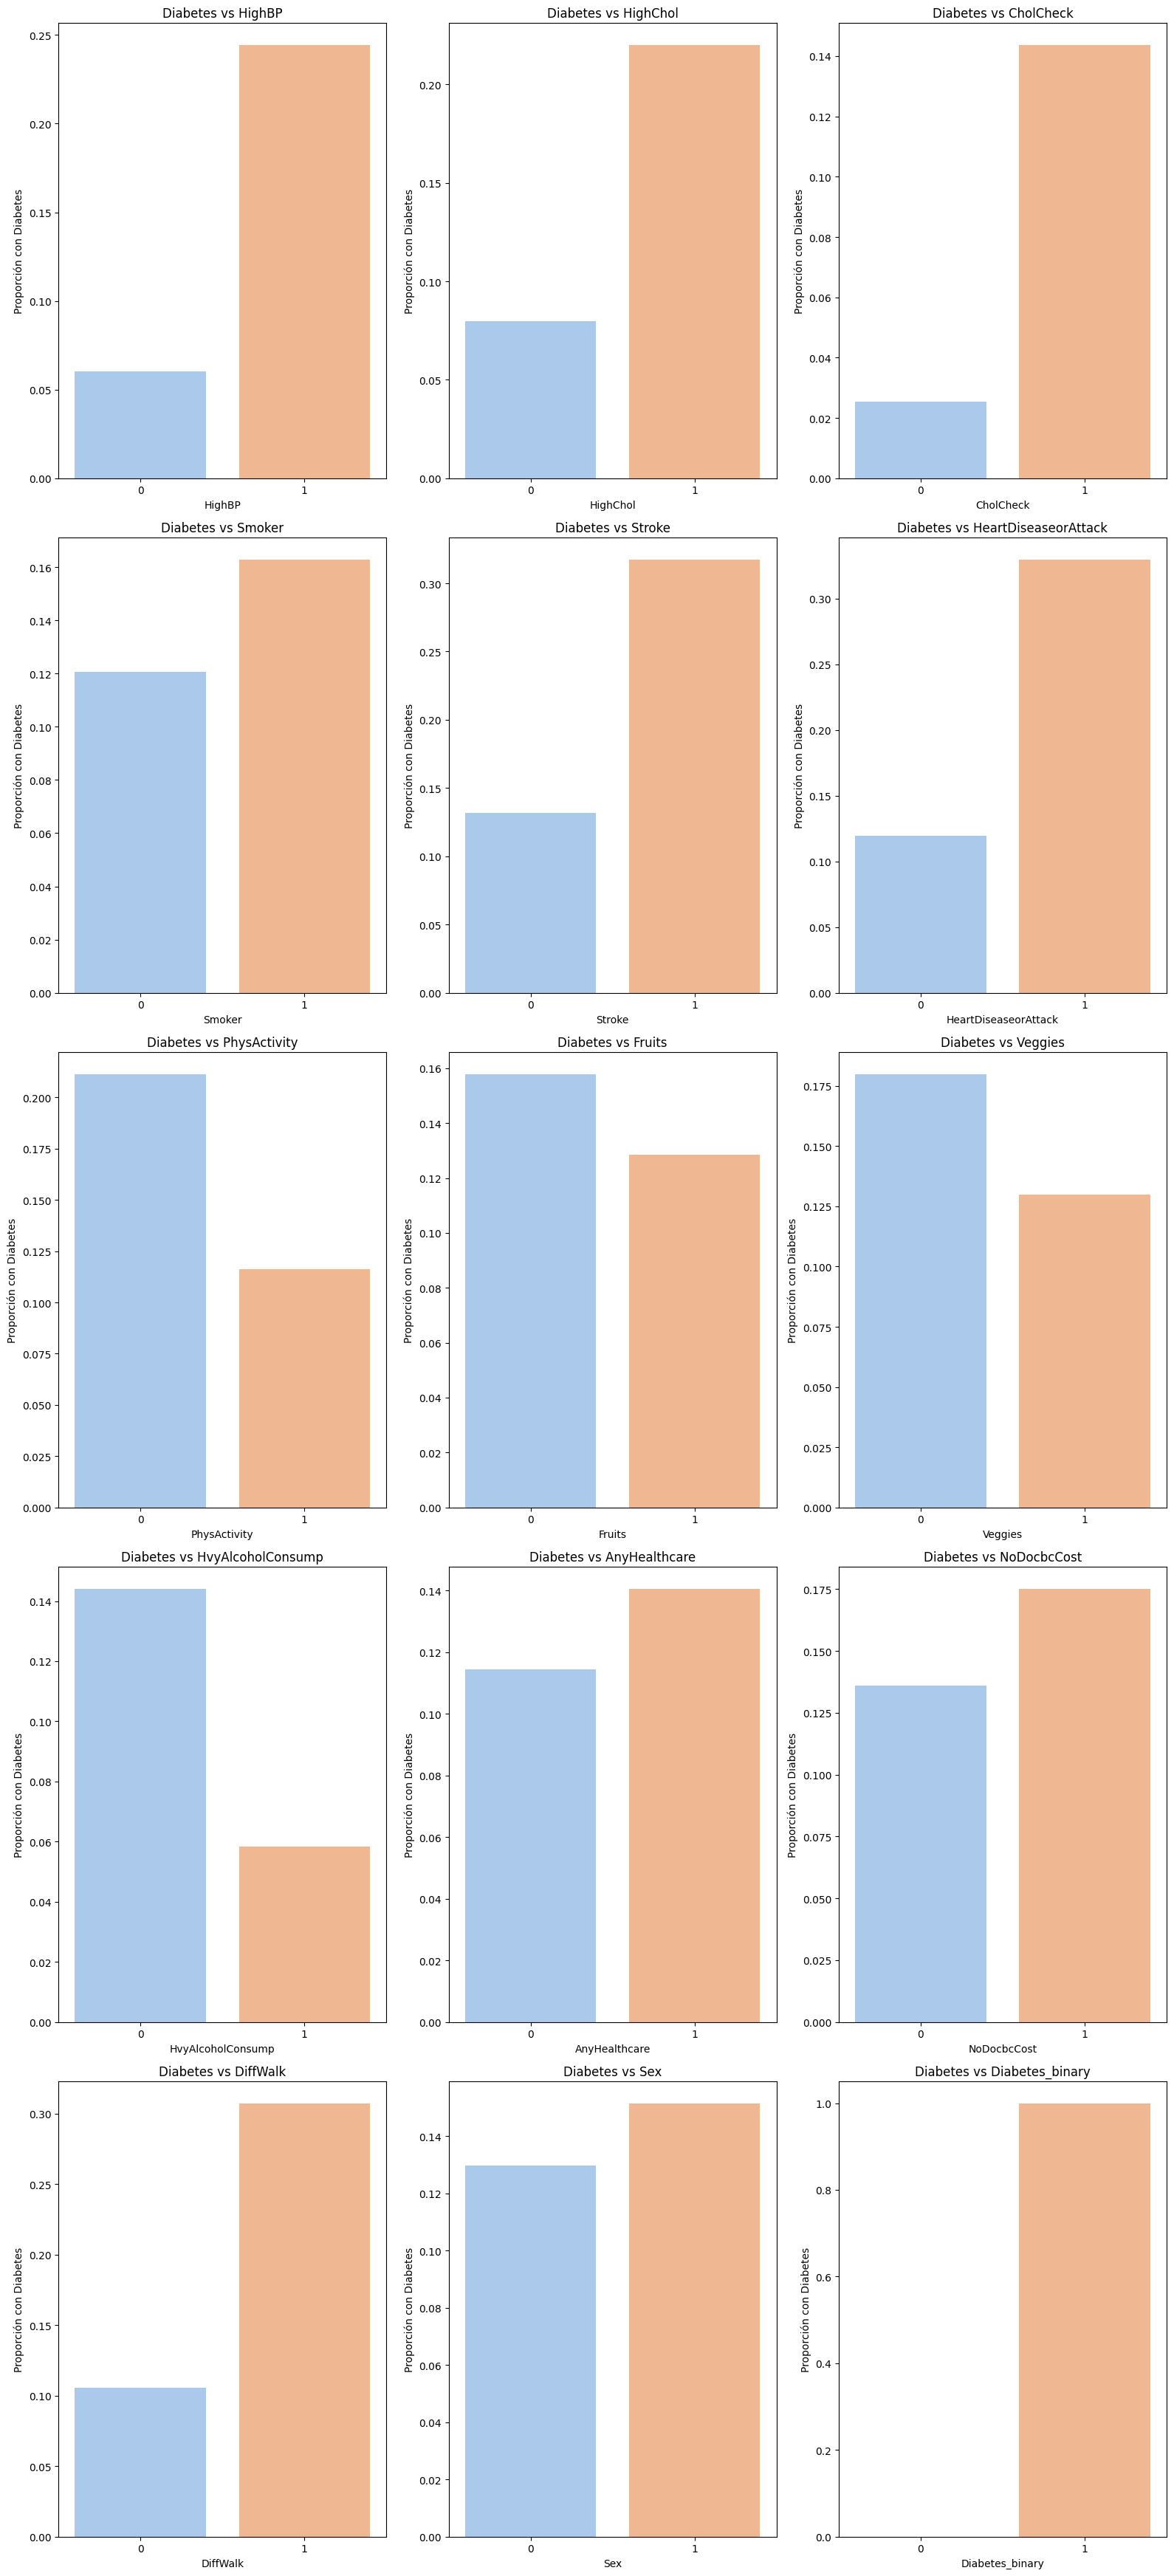

In [86]:
plt.figure(figsize=(16, 7 * 5)) 

for i, col in enumerate(binarias, 1):  
    plt.subplot(5, 3, i) 
    sns.barplot(
    x=col, 
    y='Diabetes_binary', 
    data=df, 
    palette='pastel',
    errorbar=None
    )
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Proporción con Diabetes')
plt.tight_layout()  
plt.show()

**Interpretación:**

Los resultados visualizados muestran que la proporción de personas con diabetes es notablemente mayor en aquellos que presentan condiciones crónicas como hipertensión, colesterol alto, enfermedades cardiovasculares, antecedentes de derrame cerebral y dificultades físicas para caminar. Esta tendencia sugiere una fuerte asociación entre la diabetes y la presencia de otras enfermedades no transmisibles. Además, se observa que ciertos comportamientos y estilos de vida, como la inactividad física y el consumo de tabaco, también están relacionados con una mayor prevalencia de diabetes. Por otro lado, factores como la actividad física regular y una alimentación con frutas y verduras parecen asociarse con una menor proporción de personas con diabetes. Finalmente, las barreras económicas y el acceso limitado a servicios de salud también muestran una posible relación con una mayor proporción de casos, lo cual resalta la importancia del contexto socioeconómico en el manejo y prevención de esta enfermedad. En conjunto, los gráficos evidencian que la diabetes no solo está influenciada por condiciones médicas, sino también por determinantes sociales y conductuales de la salud.

### Variables Categóricas vs Diabetes

Se generan graficos de barras para analizar la relación entre variables categóricas y la presencia de diabetes en la población estudiada. Con el fin de identificar qué categorías dentro de cada variable presentan mayores proporciones de diabetes, lo que podría indicar posibles factores de riesgo asociados.

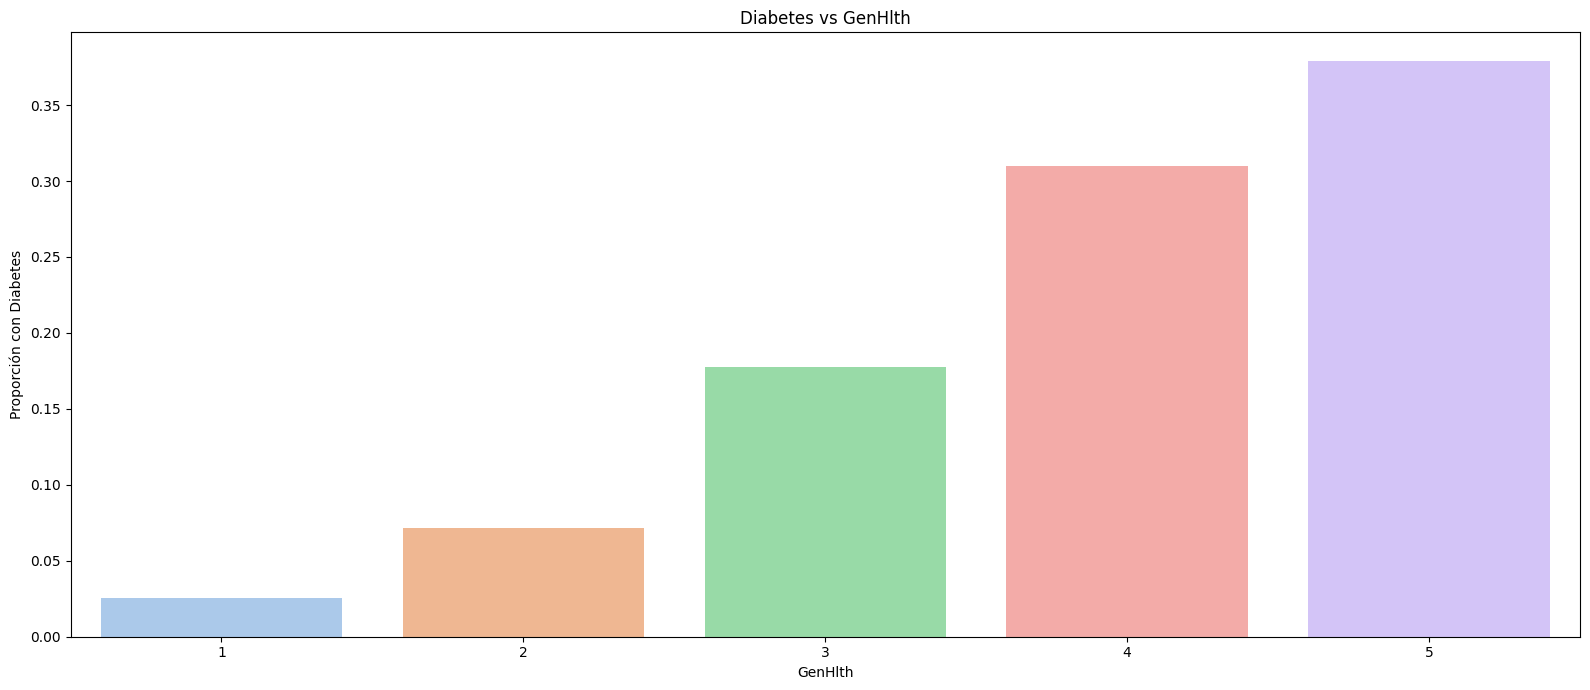

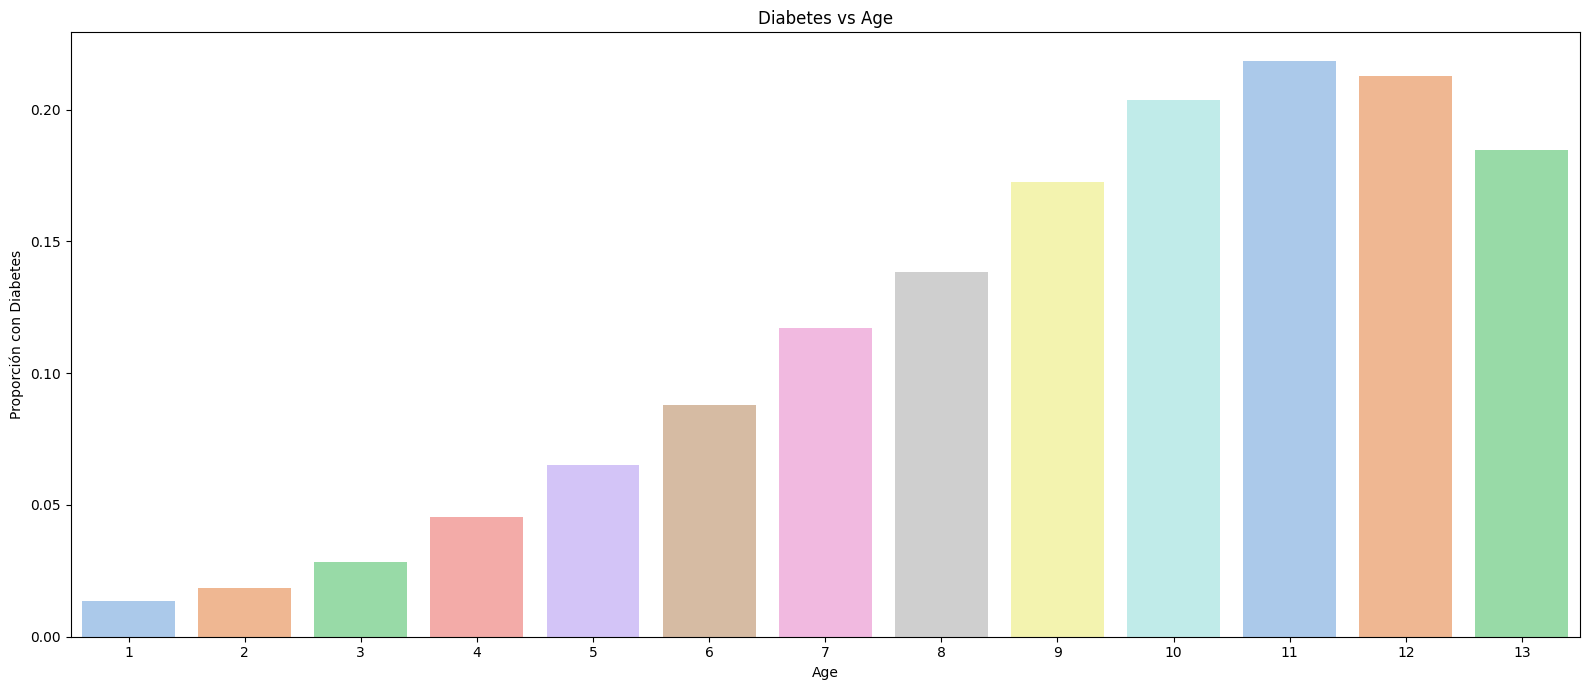

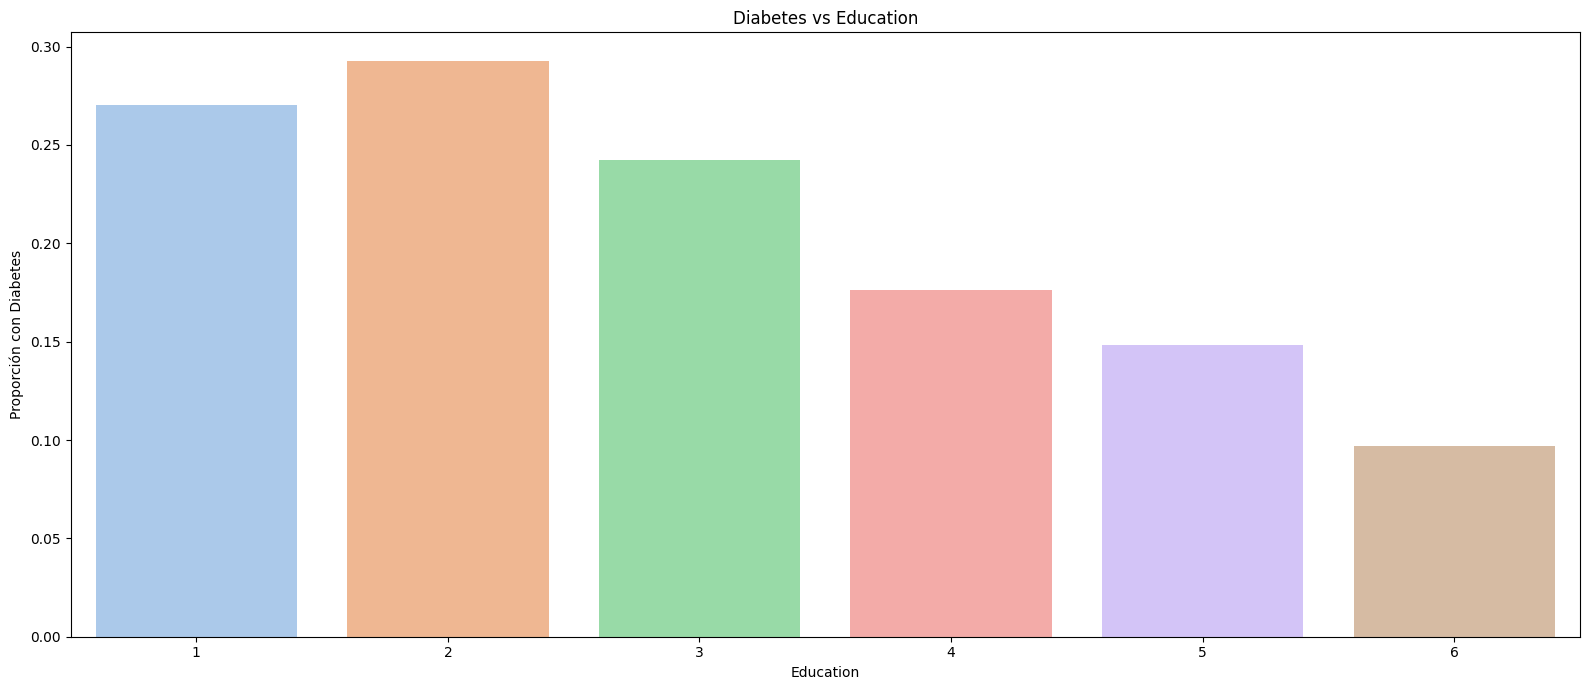

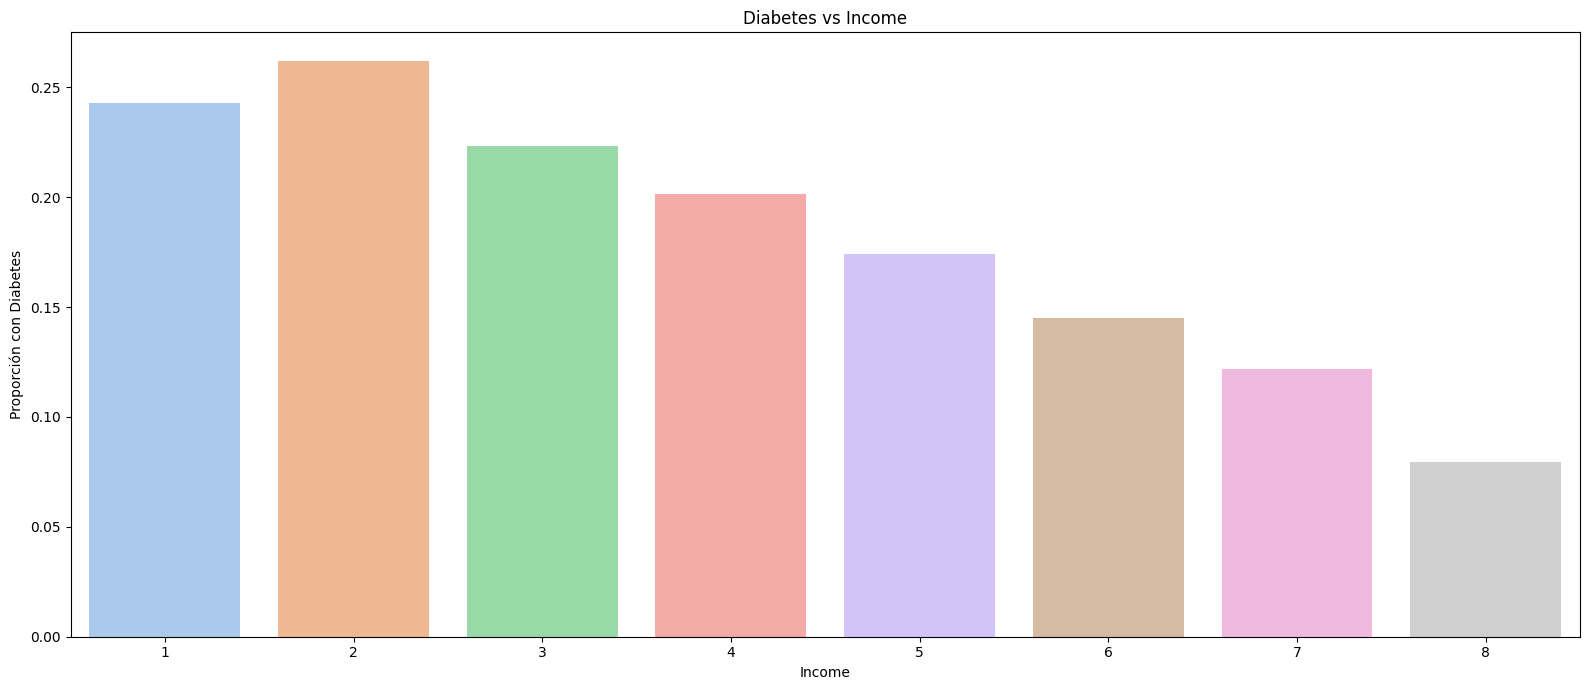

In [87]:
for col in categoricas:
    
    plt.figure(figsize=(16, 7))
    sns.barplot(
        x=col, 
        y='Diabetes_binary', 
        data=df, 
        palette='pastel',
        errorbar=None  
    )
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Proporción con Diabetes')
    plt.tight_layout()
    plt.show()

**Interpretación:**

Los resultados muestran una relación clara entre la proporción de personas con diabetes y diversas variables sociodemográficas. En cuanto al estado general de salud percibido `GenHlth`, se observa que a medida que las personas reportan una peor salud (del valor 1 al 5), la proporción de casos de diabetes aumenta progresivamente, lo que indica una fuerte asociación entre la autopercepción negativa de la salud y la presencia de diabetes. En relación con la `Age`, los datos revelan una tendencia ascendente en la proporción de diabetes conforme se avanza en los grupos etarios, alcanzando su punto máximo en los grupos de mayor edad, lo que sugiere que la diabetes es más común en adultos mayores. Por otro lado, los niveles de `Education` muestran una tendencia inversa: las personas con menor nivel educativo presentan una mayor proporción de diabetes, mientras que a mayor nivel educativo, esta proporción disminuye gradualmente. Esta misma tendencia se refleja en los niveles de `Income`, donde las personas con ingresos más bajos muestran una mayor prevalencia de diabetes en comparación con aquellas que pertenecen a grupos de ingresos más altos. En conjunto, estos resultados evidencian la influencia significativa de factores sociales como la edad, la educación, el ingreso económico y la percepción de salud en la prevalencia de la diabetes, resaltando la importancia de abordar esta enfermedad desde un enfoque multidimensional..

### Variables Númericas vs Diabetes

Se visualiza la asociación entre variables numéricas y la diabetes. Los gráficos combinan barras (proporción de diabetes por valor) y una línea de tendencia (roja), permitiendo identificar patrones o relaciones monotónicas entre las variables y la variable objetivo.

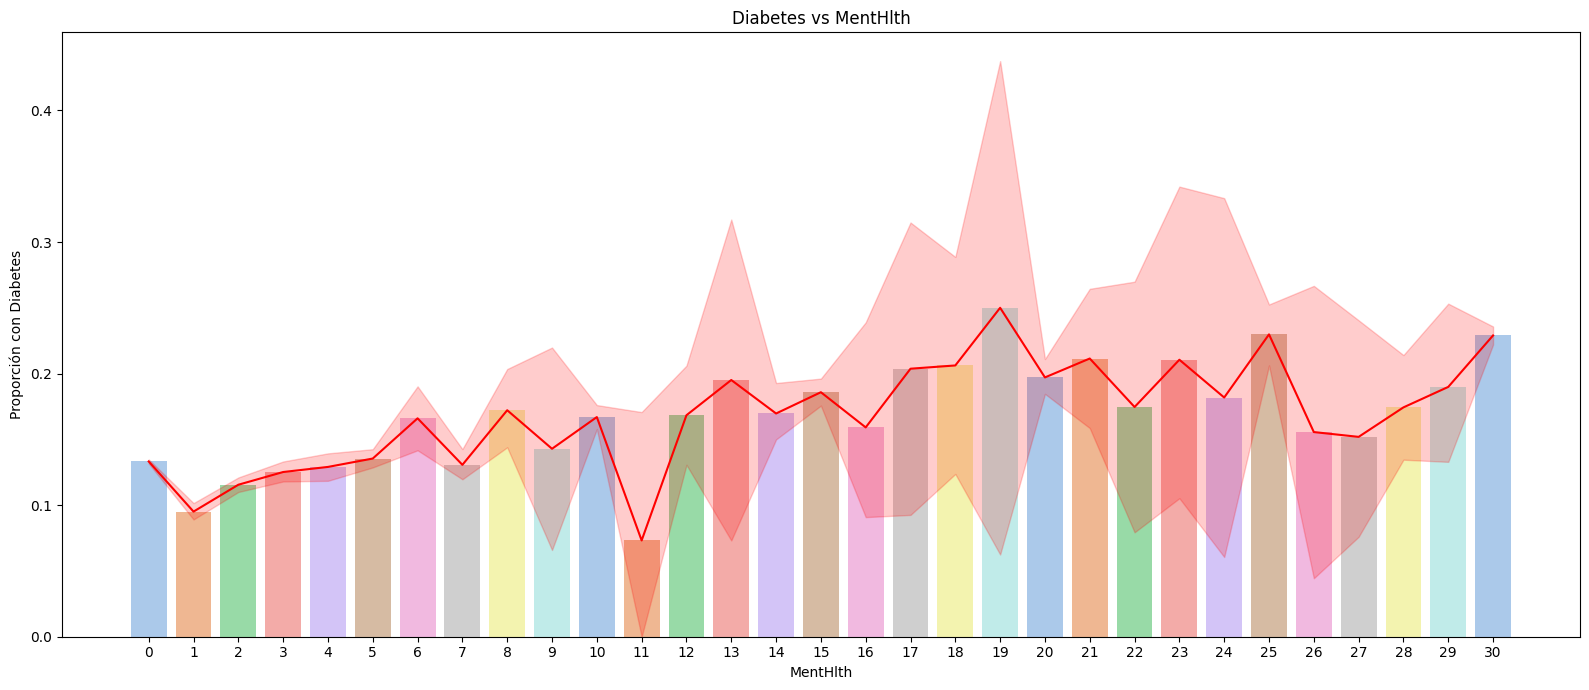

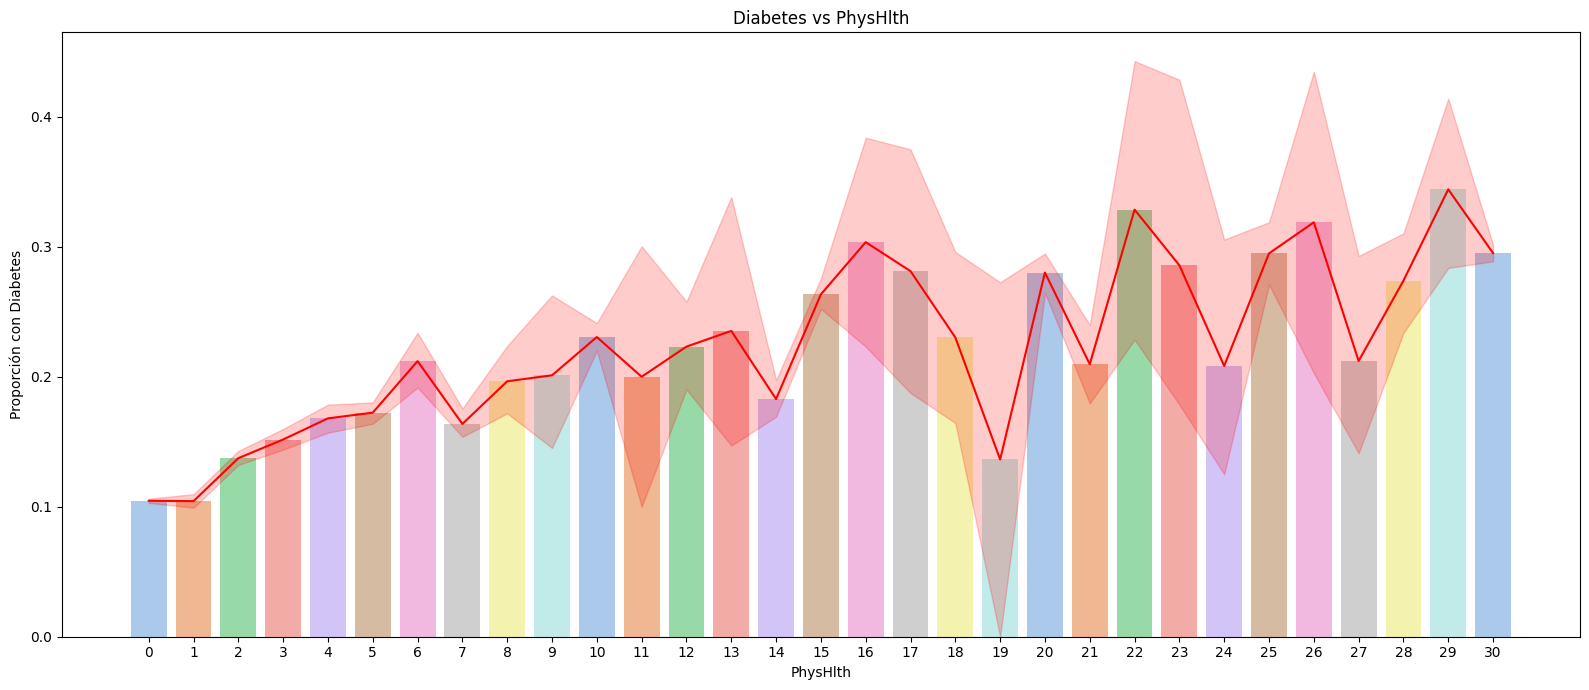

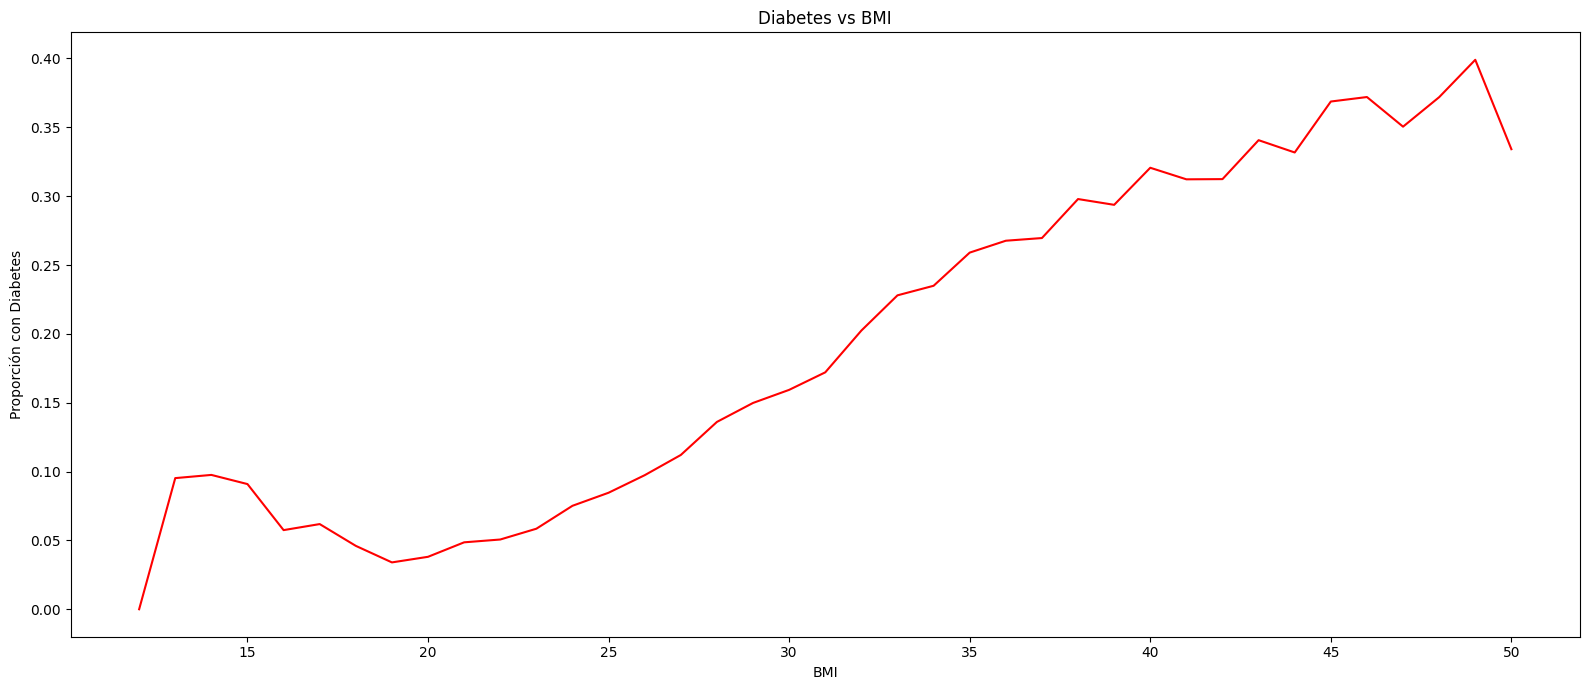

In [88]:
for col in numericas:
    
    if (col != "BMI"):
        plt.figure(figsize=(16, 7))
        sns.barplot(
            x=col, 
            y='Diabetes_binary', 
            data=df, 
            palette='pastel',
            errorbar=None  
        )
        
        sns.lineplot(
        x=col, 
        y='Diabetes_binary', 
        data=df,
        color='red',
        sort=True
        )
        plt.title(f'Diabetes vs {col}')
        plt.ylabel('Proporción con Diabetes')
        plt.tight_layout()
        plt.show()
        
             
plt.figure(figsize=(16, 7))
sns.lineplot(
    x='BMI', 
    y='Diabetes_binary', 
    data=df,
    color='red',
    estimator='mean', 
    errorbar=None
)
plt.title('Diabetes vs BMI')
plt.ylabel('Proporción con Diabetes')
plt.tight_layout()
plt.show()

**Interpretación:**

Los gráficos muestran la relación entre la salud mental `MentHith` y física `PhysHith` con la proporción de casos de diabetes. En ambos casos, se observa una tendencia clara: a medida que empeora el estado de salud (aumentan los valores en los ejes horizontales), la proporción de personas con diabetes incrementa. Para la salud mental, la línea de tendencia roja presenta un ascenso sostenido, aunque con cierta variabilidad en los valores intermedios, lo que sugiere que los días con mayor afectación mental están asociados a una mayor prevalencia de diabetes. Por otro lado, en la salud física, la tendencia es más marcada y consistente, especialmente en los valores más altos, indicando una fuerte correlación entre el deterioro físico y la presencia de diabetes. Estos resultados refuerzan la hipótesis de que tanto la salud mental como física están vinculadas al riesgo de diabetes, siendo el impacto particularmente evidente en estados de salud más críticos.

El gráfico de la relación entre el `BMI` y la proporción de diabetes muestra una tendencia claramente creciente y aparentemente lineal a medida que aumenta el índice de masa corporal, desde valores alrededor de 15 hasta aproximadamente 35-40 BMI. A partir de ese punto, la proporción de diabetes comienza a estabilizarse e incluso a descender ligeramente en el rango de valores más altos (40-50 BMI). Este comportamiento en las colas podría deberse a la menor cantidad de datos disponibles en dichos rangos extremos, lo que introduce una mayor variabilidad y ruido en las estimaciones. Por ejemplo, es posible que en algunos intervalos de BMI muy altos haya muy pocas observaciones, lo que resulta en proporciones que no necesariamente reflejan una tendencia poblacional real, sino fluctuaciones muestrales. Por lo tanto, aunque la relación positiva entre BMI y diabetes es evidente en la mayoría del rango, se debe tener precaución al interpretar las zonas extremas por posibles problemas de representatividad estadística.

---

Para evaluar la tendencia entre las variables númericas y la prevalencia de diabetes de manera más clara se implementó un análisis basado en categorización de rangos.

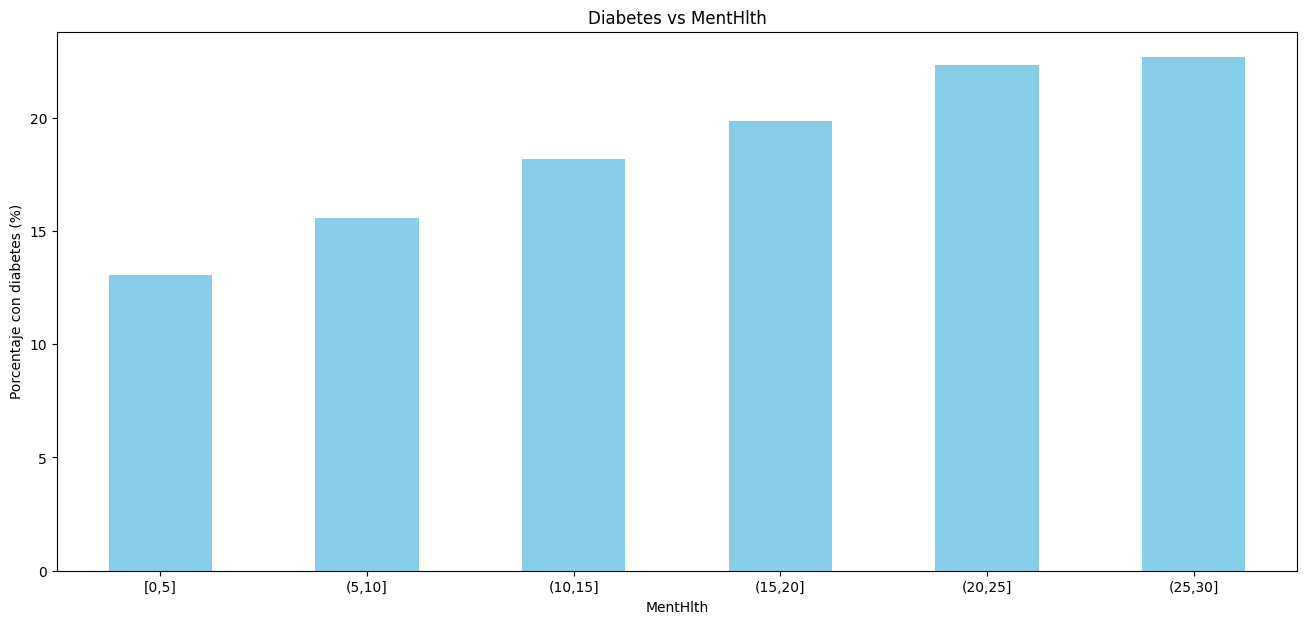

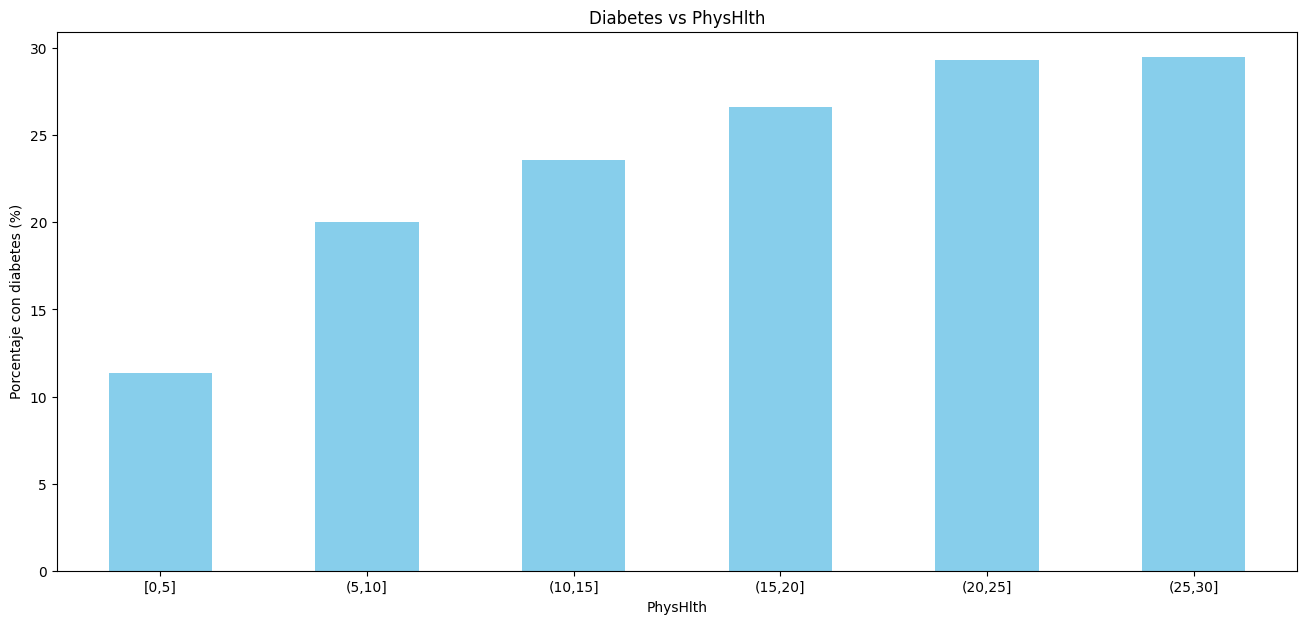

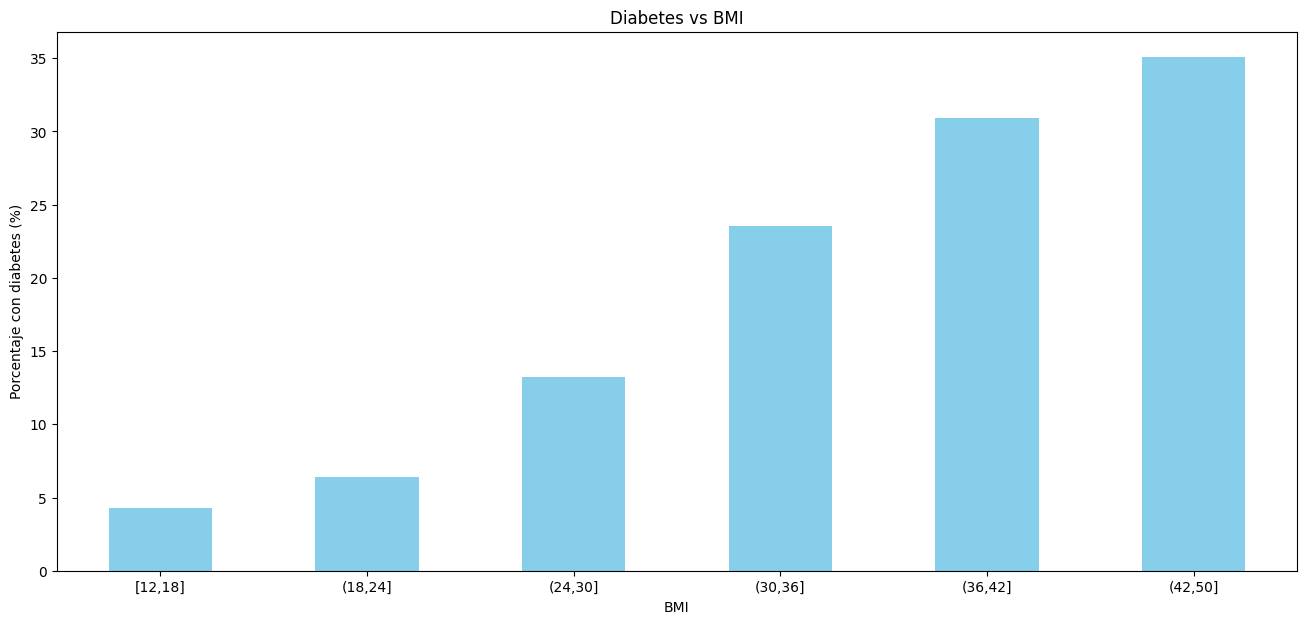

In [89]:
config_categorias = {
    "BMI": {
        "bins": [11, 19, 25, 31, 37, 43, 51],
        "labels": ['[12,18]', '(18,24]', '(24,30]', '(30,36]', '(36,42]', '(42,50]']
    },
    "MentHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    },
    "PhysHlth": {
        "bins": [-1, 6, 11, 16, 21, 26, 31],
        "labels": ['[0,5]', '(5,10]', '(10,15]', '(15,20]', '(20,25]', '(25,30]']
    }
}

for col in numericas:
    
    bins = config_categorias[col]["bins"]
    labels = config_categorias[col]["labels"]
    
    
    grupos = pd.cut(df[col], bins=bins, labels=labels)
    

    diabetes_percent = df.groupby(grupos)['Diabetes_binary'].mean() * 100
    
    
    plt.figure(figsize=(16, 7))
    diabetes_percent.plot(kind='bar', color='skyblue')
    
    plt.title(f'Diabetes vs {col}')
    plt.ylabel('Porcentaje con diabetes (%)')
    plt.xticks(rotation=0)
    plt.show()

**Interpretación:**

Estos gráficos corroboran claras asociaciones entre la diabetes y diversos factores relacionados con la salud física, mental y el Índice de Masa Corporal.

En primer lugar, se evidencia una relación directa entre el deterioro de la salud mental y el aumento en la proporción de personas con diabetes. A medida que se incrementan los días con problemas de salud mental, también aumenta el porcentaje de personas con diagnóstico de diabetes, lo que sugiere una posible interacción entre el bienestar psicológico y el desarrollo o manejo de esta enfermedad.

De manera similar, la salud física también muestra una tendencia marcada: las personas que reportan más días con limitaciones físicas o problemas de salud presentan una mayor prevalencia de diabetes. Esto podría indicar que la diabetes tiende a coexistir con otras condiciones físicas crónicas o que su presencia contribuye al deterioro del estado físico general.

Finalmente, el índice de masa corporal (IMC) muestra una relación especialmente clara: a medida que el IMC aumenta, también lo hace el porcentaje de personas con diabetes. Las tasas más altas se encuentran en los grupos con obesidad severa, lo que refuerza la fuerte asociación entre el exceso de peso y el riesgo de desarrollar diabetes.

## Análisis Multivariado

Para identificar relaciones lineales entre las variables del Dataset, se generó una matriz de correlación mediante un heatmap. Este gráfico muestra el coeficiente de correlación de Pearson (rango: -1 a 1) entre cada par de variables, utilizando una escala de colores (azul para correlaciones negativas, rojo para positivas). Los valores numéricos anotados permiten evaluar posibles dependencias entre variables.


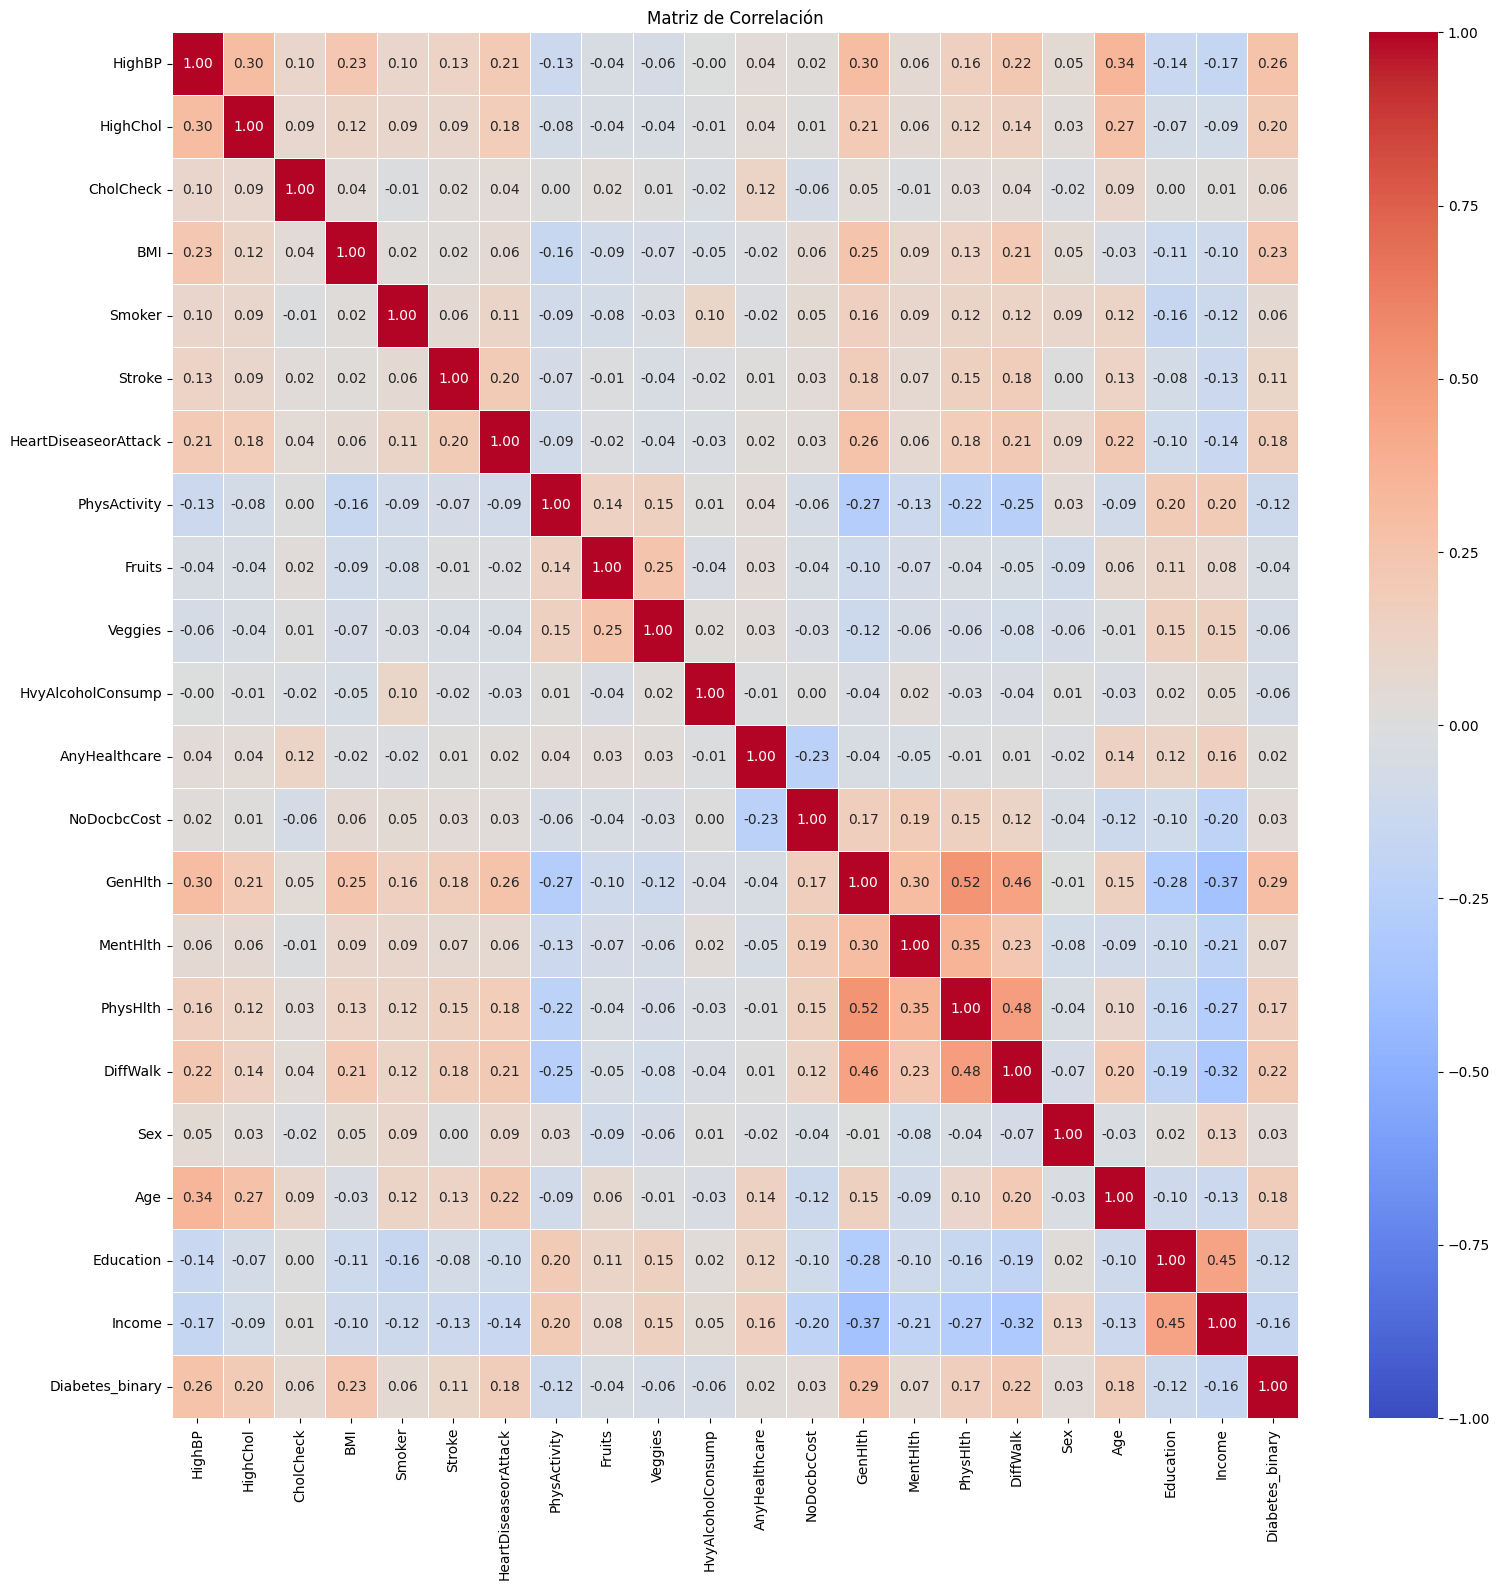

In [90]:
plt.figure(figsize=(16, 16))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          
    cmap="coolwarm",    
    vmin=-1, vmax=1, 
    linewidths=0.5      
)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

**Interpretación:**

El análisis de la matriz de correlación revela patrones clave entre las variables y su asociación con la diabetes (`Diabetes_binary`). Se destacan las siguientes observaciones:

1. **Variables con mayor correlación positiva con diabetes**:
    - Presión arterial alta `HighBP` (0.26) y índice de masa corporal `BMI` (0.23) muestran una asociación moderada pero significativa, lo que sugiere que estos factores están vinculados a un mayor riesgo de diabetes.
    - Salud general autopercibida `GenHith` (0.29) y dificultad para caminar `DiffWalk` (0.22) también presentan correlaciones positivas, indicando que un peor estado de salud físico y movilidad reducida pueden estar relacionados con la presencia de diabetes.

2. **Variables con correlaciones negativas**:
    - Actividad física `PhysActivity` (-0.12), nivel educativo `Education` (-0.12) y nivel de ingresos `Income` (-0.16) muestran una relación inversa débil con diabetes, lo que apunta a que estilos de vida más activos, mayores niveles educativos y recursos económicos podrían asociarse a menor prevalencia de la enfermedad.

3. **Relaciones entre variables predictoras**:
    - `GenHith` está fuertemente correlacionada con `PhysHith` (0.52) y `DiffWalk` (0.48), lo que refleja una interconexión entre salud física, movilidad y percepción general de salud.
    - `Education` e `Income` presentan una correlación positiva entre sí (0.45), sugiriendo que factores socioeconómicos podrían influir en conjunto en los resultados de salud.

4. **Correlaciones débiles o nulas**:
    - Variables como `AnyHealthcare`, `NoDocbcCost` o `Sex` muestran asociaciones cercanas a cero con diabetes, indicando que su impacto directo es marginal según estos datos.


### Multicolinealidad

A continuación hallamos el VIF el cual determina la fuerza de la correlación entre las variables independientes. Se pronostica tomando una variable y comparándola con todas las demás. La puntuación VIF de una variable independiente representa hasta qué punto la variable se explica por otras variables independientes.

- Un valor `VIF de 1`: Sin multicolinealidad (variable perfectamente independiente).
- Un valor `VIF entre 1 y 5`: Multicolinealidad baja a moderada (no se considera problemática).
- Un valor `VIF entre 5 y 10`: Multicolinealidad moderada a alta (considerada problemática).
- Un valor `VIF superior a 10`: Multicolinealidad alta (preocupación grave, requiere medidas).

In [91]:
def VIF_calculation(X):
    VIF = pd.DataFrame()
    VIF["variable"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop = True)
    return(VIF)

VIF_mat = VIF_calculation(X)
display(VIF_mat)

,variable,VIF
0,Education,29.507416
1,CholCheck,23.187436
2,AnyHealthcare,20.839710
3,BMI,18.149913
4,Income,14.156118
5,GenHlth,10.740162
6,Age,9.886830
7,Veggies,5.826886
8,PhysActivity,4.645314
9,Fruits,3.032775


**Interpretación:**

Los valores de VIF obtenidos indican la presencia de multicolinealidad entre las variables predictoras del modelo. Se observa que las variables `Education`, `CholCheck` y `AnyHealthcare` presentan los valores de VIF más elevados (29.51, 23.19 y 20.84, respectivamente), lo que sugiere una fuerte dependencia lineal con otras variables del modelo. Estos resultados superan ampliamente el umbral crítico de `VIF = 5`, e incluso el más estricto de `VIF = 10`, lo que implica que la multicolinealidad podría estar inflando la varianza de los coeficientes de regresión y, por ende, afectando la estabilidad e interpretación del modelo. Variables como `BMI`, `Income` y `GenHlth` también muestran valores preocupantes (18.15, 14.16 y 10.74), aunque en menor grado.

En contraste, las variables restantes (como `Veggies`, `PhysActivity`, `HighBP`, `HighChol` y aquellas con `VIF < 5`) no presentan multicolinealidad significativa, lo que indica que aportan información independiente al modelo. Especialmente, variables como `HvyAlcoholConsump`, `Stroke` y `NoDocbcCost` (`VIF < 1.3`) son prácticamente libres de redundancia.

Estos hallazgos resaltan la necesidad de depurar el modelo para garantizar estimaciones robustas y evitar conclusiones sesgadas.

### Tratamiento de Multicolinealidad (Modelo Logístico)

Procedemos a tratar la multicolinealidad mediante la eliminación iterativa de variables con Factor de Inflación de la Varianza (VIF) superior a 10. Este enfoque sistemático nos permite identificar y remover las variables que presentan alta correlación con otras variables predictoras, lo que podría distorsionar los coeficientes del modelo y afectar su interpretabilidad. El proceso se repite de forma iterativa hasta que todas las variables restantes muestran un VIF por debajo del umbral establecido, garantizando así la independencia entre los predictores y mejorando la estabilidad de las estimaciones del modelo. 

- Este proceso se realizó específicamente para evitar la multicolinealidad en el modelo de regresión logística, ya que este tipo de modelo es afectado críticamente por la presencia de multicolinealidad, la cual puede inflar la varianza de los coeficientes estimados, dificultar la identificación de variables significativas y comprometer la validez estadística de las conclusiones del modelo.

- Nótese que este tratamiento de multicolinealidad no fue necesario aplicar al modelo K-Nearest Neighbors (KNN), ya que este tipo de algoritmo no se ve afectado críticamente por la correlación entre variables, sino principalmente por la alta dimensionalidad (gran número de características) y la escala de los datos. Dado que nuestro dataset no presenta problemas de alta dimensionalidad, no se requirió este preprocesamiento específico para el modelo KNN.


In [92]:
# Crear una copia de X para no modificar el original
X_filtered = X.copy()
removed_features = []
threshold = 10

print("Proceso iterativo de eliminación por VIF:")
print("-----------------------------------------")

for i in range(X.shape[1]): 
    vif_df = VIF_calculation(X_filtered)  
    max_vif = vif_df['VIF'].iloc[0]
    max_feature = vif_df['variable'].iloc[0]
    
    if max_vif > threshold:
        print(f"Round {i+1}: Eliminando '{max_feature}' con VIF = {max_vif:.2f}")
        X_filtered = X_filtered.drop(columns=[max_feature])  
        removed_features.append(max_feature)
    else:
        print(f"\n¡Proceso completado! Todas las variables tienen VIF < {threshold}.")
        break

print("\nVariables eliminadas:", removed_features)
print(f"\nX original tiene {X.shape[1]} variables")
print(f"X filtrado tiene {X_filtered.shape[1]} variables con VIF < {threshold}")

Proceso iterativo de eliminación por VIF:
-----------------------------------------
Round 1: Eliminando 'Education' con VIF = 29.51
Round 2: Eliminando 'CholCheck' con VIF = 22.24
Round 3: Eliminando 'AnyHealthcare' con VIF = 18.13
Round 4: Eliminando 'BMI' con VIF = 14.66

¡Proceso completado! Todas las variables tienen VIF < 10.

Variables eliminadas: ['Education', 'CholCheck', 'AnyHealthcare', 'BMI']

X original tiene 21 variables
X filtrado tiene 17 variables con VIF < 10


## Creación del Conjunto de Entrenamiento y Prueba (Modelo Logístico)

Para evaluar de manera rigurosa y justa el desempeño final del modelo optimizado, es esencial probarlo en datos que no hayan sido vistos durante el proceso de ajuste de hiperparámetro. Por esta razón, se divide el dataset en subconjuntos de entrenamiento y prueba. El conjunto de entrenamiento (`X_train`, `y_train`) se utilizará para reentrenar el mejor modelo con todos los datos disponibles de entrenamiento, mientras que el conjunto de prueba (`X_test`, `y_test`) se reservará exclusivamente para la evaluación final, proporcionando una estimación no sesgada del rendimiento del modelo en datos nuevos.

Se divide las features (`X_filtered`) y la variable objetivo binaria (`y`), utilizando el parámetro `stratify` para garantizar que la proporción de las clases `Diabetes_binary` se mantenga igual en ambos conjuntos, preservando así el balance original.

Un 20% de los datos se asigna para prueba en ambos casos, utilizando una semilla (`random_state=42`) para asegurar la reproducibilidad de la partición.

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, stratify=y, random_state=42)

### Balanceo (Smote)

Para abordar el desbalanceo de clases presente en la variable objetivo, se aplicó la técnica de sobremuestreo `SMOTE` (Synthetic Minority Over-sampling Technique) exclusivamente al conjunto de entrenamiento. Esta técnica genera ejemplos sintéticos de la clase minoritaria, evitando el sobreajuste que podría producirse con un simple remuestreo duplicado de observaciones. Es crucial destacar que este proceso se aplica solo a los datos de entrenamiento para preservar la integridad del conjunto de prueba y obtener una evaluación realista del modelo.

In [94]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

### Encoding (Modelo Logístico)

Para entrenar el modelo de clasificación, es necesario preprocesar las variables numéricas, categóricas y binarias de manera adecuada. Se estandarizan las variables numéricas (excluyendo `BMI`), se aplica one-hot encoding a las variables categóricas (excluyendo `Education`) y se seleccionan directamente las variables binarias relevantes (excluyendo `CholCheck`y `AnyHealthcare`). Este procesamiento se realiza por separado para los conjuntos de entrenamiento y prueba.

In [95]:
scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numericas_clf = [col for col in numericas if col in X_filtered]
categoricas_clf = [col for col in categoricas if col in X_filtered]
binarias_clf = [col for col in binarias if col in X_filtered]

#Conjunto training clasificación
X_num = scaler.fit_transform(X_train_balanced[numericas_clf])
X_cat = ohe.fit_transform(X_train_balanced[categoricas_clf])
X_bin = X_train_balanced[binarias_clf]

X_train= np.hstack([X_num, X_cat, X_bin])

#Conjunto test clasificación
X_num = scaler.transform(X_test[numericas_clf])
X_cat = ohe.transform(X_test[categoricas_clf])
X_bin = X_test[binarias_clf]

X_test = np.hstack([X_num, X_cat, X_bin])

## Entrenamiento y Ajuste (Modelo Logístico)

Para establecer una línea base en el problema de clasificación de diabetes, se implementó un modelo de Regresión Logística. Este algoritmo fue seleccionado por su interpretabilidad, eficiencia computacional y capacidad para proporcionar probabilidades como output. El modelo fue entrenado utilizando el conjunto balanceado y se optimizaron sus hiperparámetros mediante validación cruzada para evitar overfitting y mejorar el rendimiento predictivo.

### Configuración de la Búsqueda de Hiperparámetro con LogisticRegressionCV

Para optimizar el rendimiento del modelo y encontrar la mejor combinación de hiperparámetro, se configura una búsqueda exhaustiva mediante `LogisticRegressionCV`. Esta estrategia prueba de manera sistemática todas las combinaciones de los valores especificados, utilizando validación cruzada para evaluar de forma robusta el desempeño de cada configuración.

- Se implementa la estrategia de validación cruzada con 5 folds.

Además, se define la métrica de evaluación:

- `roc_auc` para clasificación, que mide el area bajo la curva. 

El hiperparámetro a optimizar es:

- `C` para Regresión Logística, que controla la inversa de la fuerza de la regularización.

In [96]:
from sklearn.linear_model import LogisticRegressionCV
C = [0.01, 0.1, 1, 10, 100]

logreg_cv = LogisticRegressionCV(Cs=C,cv=5,penalty="l2",solver="liblinear",max_iter=1000,n_jobs=-1,scoring="roc_auc")

### Búsqueda de Hiperparámetro y Entrenamiento (Modelo Logístico)

Una vez configurada la estrategia de búsqueda, se procede a ejecutar el entrenamiento del modelo. Este paso es donde se implementa de manera práctica el flujo completo de machine learning definido teóricamente. El método `fit()` de cada objeto `LogisticRegressionCV` no solo entrena el modelo final con la mejor combinación de hiperparámetro encontrada, sino que realiza de manera automatizada y segura todo el proceso de validación cruzada, preprocesamiento y optimización.

In [97]:
logreg_cv.fit(X_train, y_train_balanced)

LogisticRegressionCV(Cs=[0.01, 0.1, 1, 10, 100], cv=5, max_iter=1000, n_jobs=-1,
                     scoring='roc_auc', solver='liblinear')

In [98]:
print("\n--- Resultados LogisticRegressionCV ---")
print("Mejor C:", logreg_cv.C_[0])  # Mejor valor de C encontrado
print("Mejor Score (AUC):", logreg_cv.scores_[1].mean(axis=0).max())  # Mejor score


--- Resultados LogisticRegressionCV ---
Mejor C: 0.01
Mejor Score (AUC): 0.8040784850246497


**Interpretación**

El proceso de optimización mediante `LogisticRegressionCV` identificó que el mejor modelo de Regresión Logística se obtiene con el siguiente parámetro:

- `C = 0.01`: Este valor indica un nivel alto de regularización, donde el modelo prioriza la generalización sobre el ajuste perfecto a los datos de entrenamiento. Un valor bajo de C (0.01) significa mayor regularización, lo que ayuda a prevenir el sobreajuste.

- **Mejor Score (AUC): 0.8040 (80.40%)**:  
 Este resultado representa un desempeño sólido y competitivo, entonces el modelo tiene una capacidad del 80.4% para distinguir entre clases positivas y negativas. En el contexto de problemas médicos con desbalanceo de clases, este es un resultado considerablemente bueno, aunque con margen para implementar modelos más avanzados para alcanzar los niveles de precisión requeridos en aplicaciones productivas.


## Evaluación del Modelo de Clasificación en el Conjunto de Prueba (Modelo Logístico)

Para completar el análisis del objetivo de clasificación binaria, se evaluó el desempeño del mejor modelo de Regresión Logística en el conjunto de prueba reservado para esta tarea. La evaluación de un modelo de clasificación requiere un análisis más multidimensional que la regresión, ya que es necesario considerar no solo la capacidad de predicción general (accuracy) sino también el equilibrio entre los diferentes tipos de error (falsos positivos y falsos negativos), lo cual es crucial dependiendo del contexto de aplicación.

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train_balanced`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación Logistic Regression
Accuracy: 0.7041942604856513
Precision: 0.2833124078825263
Recall: 0.7341915405290705
F1-score: 0.4088545769654955


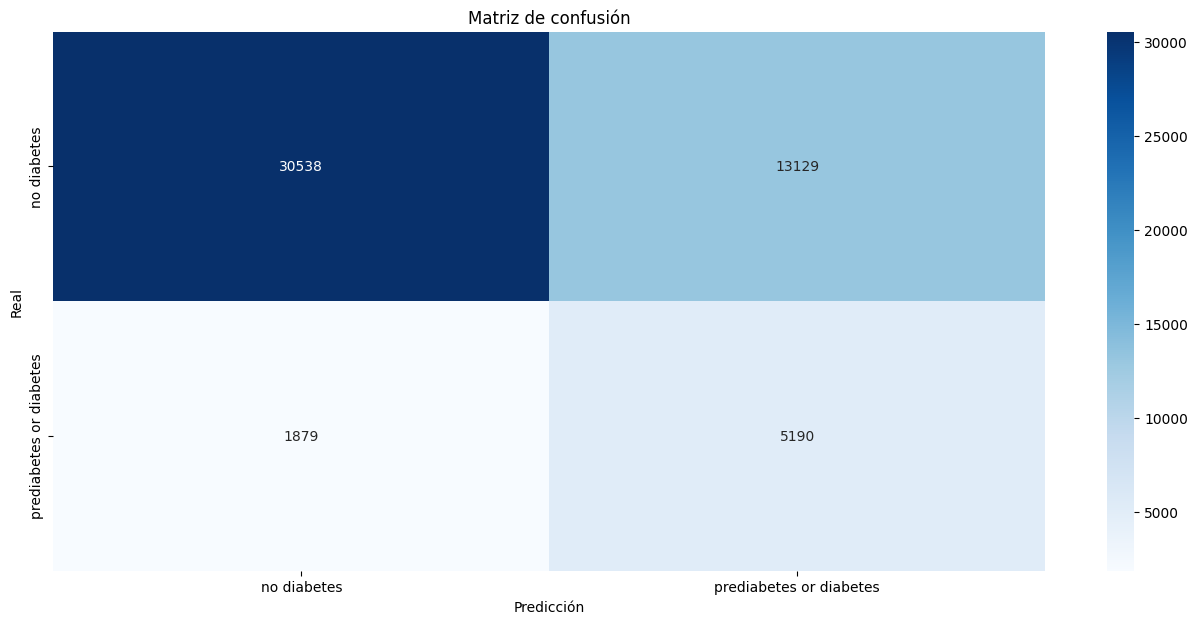

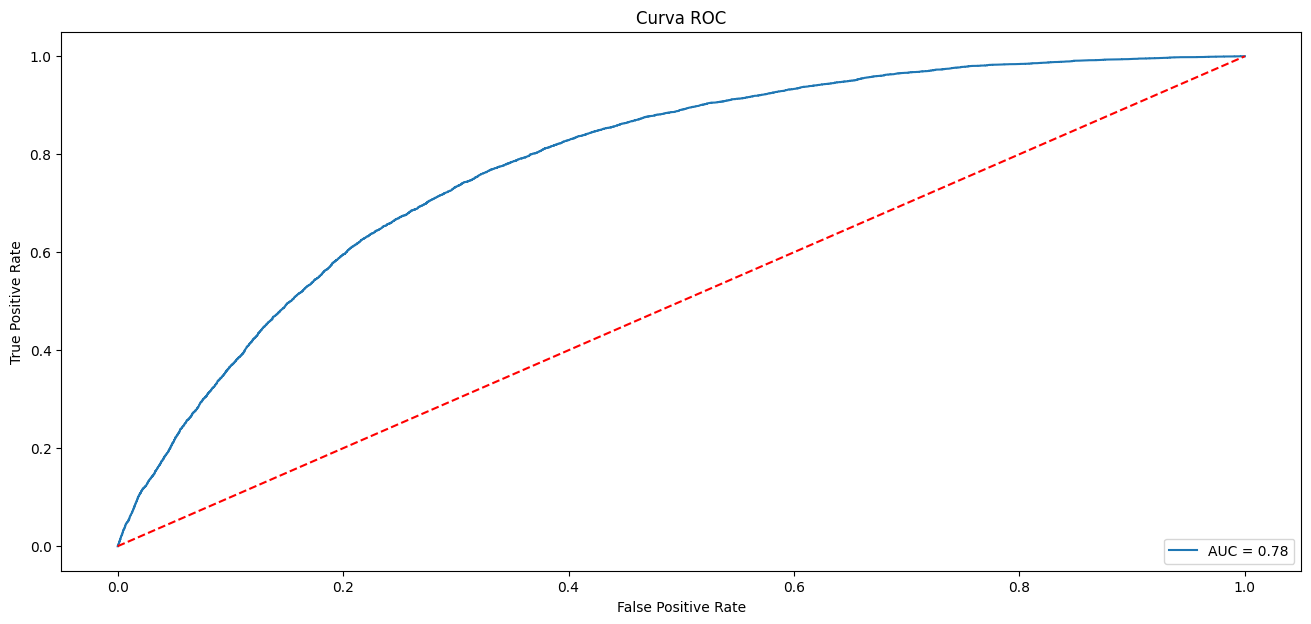

In [99]:
best_logreg = logreg_cv
best_logreg.fit(X_train, y_train_balanced)

y_pred_clf = best_logreg.predict(X_test)
y_pred_proba = best_logreg.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_clf)
prec = precision_score(y_test, y_pred_clf)
rec = recall_score(y_test, y_pred_clf)
f1 = f1_score(y_test, y_pred_clf)

print("Evaluación Logistic Regression")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_clf)
plt.figure(figsize=(16, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no diabetes","prediabetes or diabetes"], yticklabels=["no diabetes","prediabetes or diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(16, 7))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()


**Interpretación**

**El modelo de Regresión Logística con un umbral de VIF < 10** muestra un desempeño mixto con importantes áreas de oportunidad para su optimización:

- **Accuracy: 70.41%**: Esta métrica sugiere un desempeño aceptable a nivel global, pero enmascara limitaciones significativas en la capacidad predictiva para la clase positiva (diabetes), especialmente en un contexto de datos desbalanceados.

**Problemas Críticos Identificados:**
- **Precision: 28.33%**: Cuando el modelo predice diabetes, solo acierta aproximadamente 1 de cada 4 veces. Esta baja precisión indica una alta proporción de falsos positivos, lo que en el ámbito médico se traduciría en diagnósticos erróneos y costos asociados a pruebas adicionales innecesarias.
- **Recall: 73.41%**: El modelo detecta correctamente el 73.41% de los casos reales de diabetes, lo que representa una sensibilidad aceptable. Sin embargo, esto significa que aún falla en identificar aproximadamente 1 de cada 4 casos reales, lo que representa un riesgo clínico moderado.
- **F1-score: 40.88%**: El balance entre precisión y recall confirma el desempeño subóptimo del modelo para la clase positiva, reflejando la dificultad para equilibrar la identificación de casos reales sin generar demasiadas falsas alarmas.

**Diagnóstico del Modelo:**
El modelo presenta una combinación problemática: alta sensibilidad pero muy baja precisión. Esto indica que:
1. **Es capaz de detectar la mayoría de los casos reales** (fortaleza importante en aplicaciones médicas).
2. **Genera demasiadas falsas alarmas**, lo que reduce su confiabilidad para diagnósticos positivos.
3. **El equilibrio entre sensibilidad y especificidad es deficiente**, probablemente debido al desbalanceo entre clases.

En conclusión, si bien el modelo muestra una capacidad aceptable para detectar casos reales (recall), su alta tasa de falsos positivos (baja precisión) limita su utilidad práctica para implementación clínica directa, requiriendo ajustes adicionales para mejorar su confiabilidad diagnóstica.

## Creación del Conjunto de Entrenamiento y Prueba (Modelo KNN)

Para evaluar de manera rigurosa y justa el desempeño final del modelo optimizado, es esencial probarlo en datos que no hayan sido vistos durante el proceso de ajuste de hiperparámetro. Por esta razón, se divide el dataset en subconjuntos de entrenamiento y prueba. El conjunto de entrenamiento (`X_train`, `y_train`) se utilizará para reentrenar el mejor modelo con todos los datos disponibles de entrenamiento, mientras que el conjunto de prueba (`X_test`, `y_test`) se reservará exclusivamente para la evaluación final, proporcionando una estimación no sesgada del rendimiento del modelo en datos nuevos.

Se divide las features (`X`) y la variable objetivo binaria (`y`), utilizando el parámetro `stratify` para garantizar que la proporción de las clases `Diabetes_binary` se mantenga igual en ambos conjuntos, preservando así el balance original.

Un 20% de los datos se asigna para prueba en ambos casos, utilizando una semilla (`random_state=42`) para asegurar la reproducibilidad de la partición.

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

### Balanceo (Smote)

Para abordar el desbalanceo de clases presente en la variable objetivo, se aplicó la técnica de sobremuestreo `SMOTE` (Synthetic Minority Over-sampling Technique) exclusivamente al conjunto de entrenamiento. Esta técnica genera ejemplos sintéticos de la clase minoritaria, evitando el sobreajuste que podría producirse con un simple remuestreo duplicado de observaciones. Es crucial destacar que este proceso se aplica solo a los datos de entrenamiento para preservar la integridad del conjunto de prueba y obtener una evaluación realista del modelo.

In [101]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

### Encoding (Modelo KNN)

Para entrenar el modelo de clasificación, es necesario preprocesar las variables numéricas, categóricas y binarias de manera adecuada. Se estandarizan las variables numéricas, se aplica one-hot encoding a las variables categóricas  y se seleccionan directamente las variables binarias. Este procesamiento se realiza por separado para los conjuntos de entrenamiento y prueba

In [102]:
scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numericas_clf = [col for col in numericas if col in X]
categoricas_clf = [col for col in categoricas if col in X]
binarias_clf = [col for col in binarias if col in X]

#Conjunto training clasificación
X_num = scaler.fit_transform(X_train_balanced[numericas_clf])
X_cat = ohe.fit_transform(X_train_balanced[categoricas_clf])
X_bin = X_train_balanced[binarias_clf]

X_train= np.hstack([X_num, X_cat, X_bin])

#Conjunto test clasificación
X_num = scaler.transform(X_test[numericas_clf])
X_cat = ohe.transform(X_test[categoricas_clf])
X_bin = X_test[binarias_clf]

X_test = np.hstack([X_num, X_cat, X_bin])

## Entrenamiento y Ajuste (Modelo KNN)

Para abordar el problema de clasificación de diabetes, se implementó un modelo KNN (K-Vecinos Más Cercanos) como alternativa a los enfoques basados en regresión. Este algoritmo fue seleccionado por su naturaleza no paramétrica y su capacidad para capturar relaciones complejas en los datos sin asumir una forma funcional específica. El modelo fue entrenado utilizando el conjunto balanceado y se optimizaron sus hiperparámetros mediante validación cruzada para encontrar el equilibrio óptimo entre sesgo y varianza, mejorando así la capacidad de generalización del clasificador.

### Configuración de la Búsqueda de Hiperparámetro con KNN

Para optimizar el rendimiento del modelo y encontrar la mejor combinación de hiperparámetro, se configura una búsqueda exhaustiva mediante `GridSearchCV`. Esta estrategia prueba de manera sistemática todas las combinaciones de los valores especificados, utilizando validación cruzada para evaluar de forma robusta el desempeño de cada configuración.

- Se implementa la estrategia de validación cruzada con 5 folds.

Además, se define la métrica de evaluación:

- `roc_auc` para clasificación, que mide el area bajo la curva. 

El hiperparámetro a optimizar es:

- `n_neighbors` para KNN, que controla el número de vecinos más ceranos a la hora de realizar la predicción.

In [103]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Definir los parámetros a optimizar
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc')

### Búsqueda de Hiperparámetro y Entrenamiento (Modelo KNN) 

Una vez configurada la estrategia de búsqueda, se procede a ejecutar el entrenamiento del modelo. Este paso es donde se implementa de manera práctica el flujo completo de machine learning definido teóricamente. El método `fit()` de cada objeto `KNeighborsClassifier` no solo entrena el modelo final con la mejor combinación de hiperparámetro encontrada, sino que realiza de manera automatizada y segura todo el proceso de validación cruzada, preprocesamiento y optimización.

In [104]:
knn_cv.fit(X_train, y_train_balanced)
print("\n--- Resultados KNeighborsClassifierCV ---")
print("Mejor N:", knn_cv.best_params_)
print("Mejor Score (AUC):", knn_cv.best_score_)


--- Resultados KNeighborsClassifierCV ---
Mejor N: {'n_neighbors': 5}
Mejor Score (AUC): 0.8674457632100397


**Interpretación**

El proceso de optimización mediante búsqueda exhaustiva `GridSearchCV` identificó que la configuración óptima para el modelo KNN se alcanza con el siguiente parámetro:

- `n_neighbors = 5`: Este valor indica que el modelo basa sus predicciones en los 5 vecinos más cercanos. La elección de un valor moderado como 5 sugiere un equilibrio óptimo entre flexibilidad y generalización:
  - Un valor más bajo (ej: \( k = 1 \) o \( 3 \)) podría haber capturado ruido en los datos (sobreajuste).
  - Un valor más alto (ej: \( k = 15 \) o \( 20 \)) podría haber simplificado demasiado el modelo (subajuste).

- **Mejor Score (AUC): 0.8674 (86.74%)**:  
  El área bajo la curva ROC (AUC) obtenida mediante validación cruzada refleja un buen desempeño discriminativo. Un AUC de 86.74% indica que el modelo tiene una capacidad sobresaliente para distinguir entre pacientes con y sin diabetes, superando el desempeño de la regresión logística (80.40%). En el contexto de problemas médicos con desbalanceo de clases, este es un resultado bueno, aunque con margen para implementar modelos más avanzados para alcanzar los niveles de precisión requeridos en aplicaciones productivas.

### Evaluación del Modelo de Clasificación en el Conjunto de Prueba (Modelo KNN)

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train_balanced`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación KNN
Accuracy: 0.6910477767265847
Precision: 0.250839606253619
Recall: 0.61281652284623
F1-score: 0.3559718969555035


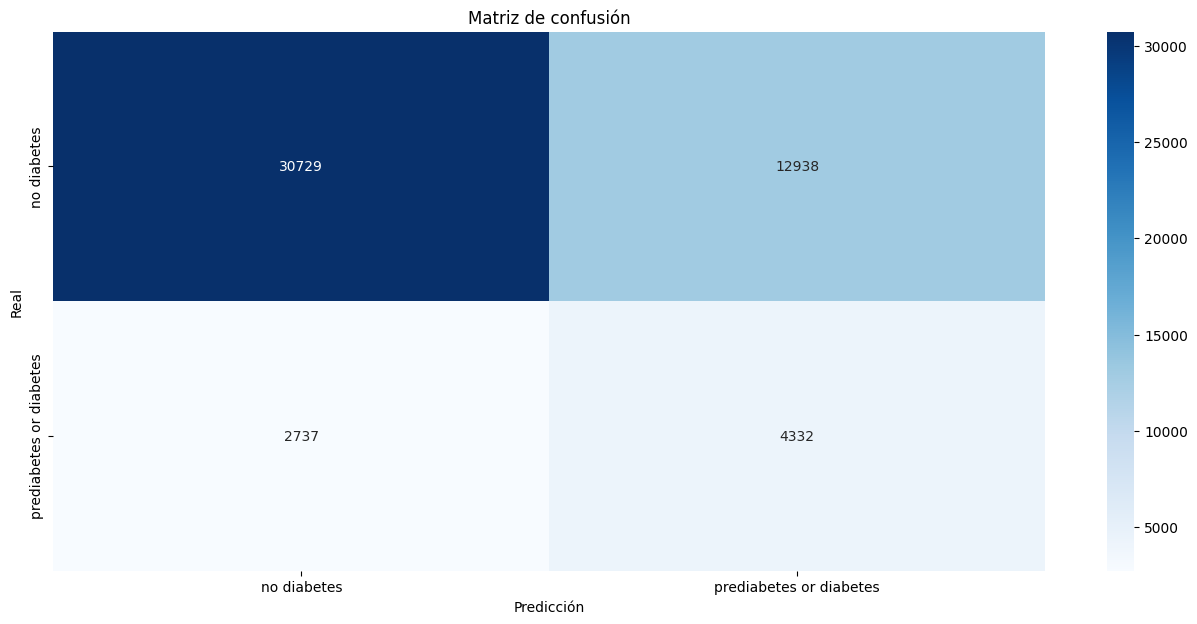

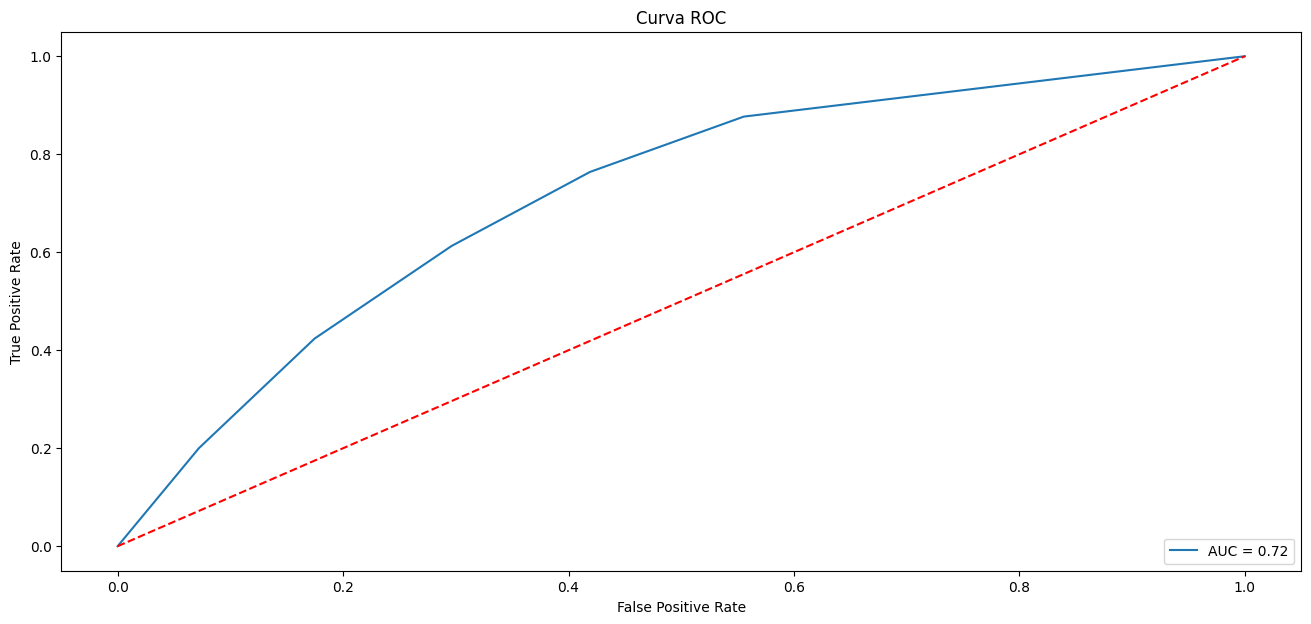

In [105]:
best_knn = knn_cv
best_knn.fit(X_train, y_train_balanced)

y_pred_clf = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_clf)
prec = precision_score(y_test, y_pred_clf)
rec = recall_score(y_test, y_pred_clf)
f1 = f1_score(y_test, y_pred_clf)

print("Evaluación KNN")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred_clf)
plt.figure(figsize=(16, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no diabetes","prediabetes or diabetes"], yticklabels=["no diabetes","prediabetes or diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(16, 7))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

**Interpretación**

**El modelo KNN sin eliminación de variables según el VIF** muestra un desempeño mixto que revela importantes limitaciones en su capacidad predictiva, particularmente en la identificación precisa de casos de diabetes:

- **Accuracy: 69.10%**: Esta métrica sugiere un desempeño aceptable a nivel global, pero enmascara graves deficiencias en la capacidad predictiva para la clase positiva (diabetes), especialmente en un contexto de datos desbalanceados.

**Problemas Críticos Identificados:**
- **Precision: 25.08%**: Cuando el modelo predice diabetes, solo acierta aproximadamente 1 de cada 4 veces. Esta tasa extremadamente baja de precision indica una alta proporción de falsos positivos, lo que en un contexto médico implicaría numerosos diagnósticos erróneos y costos asociados a pruebas innecesarias.
- **Recall: 61.28%**: El modelo detecta correctamente solo el 61.28% de los casos reales de diabetes, por lo que falla en identificar aproximadamente 4 de cada 10 casos reales. Esta sensibilidad moderada representa un riesgo clínico significativo al pasar por alto una considerable proporción de pacientes que sí tienen la condición.
- **F1-score: 35.60%**: El balance entre precision y recall confirma el desempeño subóptimo general del modelo para la clase positiva, reflejando la dificultad para equilibrar la identificación de casos reales sin generar demasiadas falsas alarmas.

**Diagnóstico del Modelo:**
El modelo presenta baja precision y recall moderado, lo que indica que:
1. **No es confiable para diagnósticos positivos** debido a su alta tasa de falsos positivos.
2. **Falla en detectar una proporción significativa de casos reales** (38.72% no detectados).
3. **El equilibrio entre sensibilidad y especificidad es deficiente**, probablemente debido a desbalanceo de clases o características no óptimas.

En conclusión, el modelo KNN en su configuración actual no es adecuado para implementación clínica debido a su alta tasa de falsos positivos y su capacidad limitada para detectar casos reales de diabetes, requiriendo optimización adicional o el uso de modelos alternativos.

## Conclusión de los Modelos Más Óptimos

El análisis comparativo entre los modelos de Regresión Logística y K-Nearest Neighbors (KNN) revela un desempeño contrastante, donde cada algoritmo presenta ventajas y limitaciones particulares en la tarea de clasificación de diabetes, sin que ninguno demuestre un rendimiento óptimo para implementación directa en un contexto clínico real.

- **En términos de capacidad predictiva general (Accuracy)**, el modelo KNN (**69.10%**) muestra un desempeño ligeramente inferior al de la Regresión Logística (**70.41%**), lo que sugiere que la naturaleza lineal de los datos podría estar favoreciendo al modelo logístico. Sin embargo, ambas métricas enmascaran problemas críticos en el desempeño específico para la clase positiva.

- **La Regresión Logística muestra un Recall significativamente más alto (73.41% vs 61.28%)**, lo que indica una efectividad muy superior para identificar casos reales de diabetes. Esta característica es crucial en el ámbito médico, donde omitir diagnósticos (falsos negativos) tiene consecuencias clínicas potencialmente graves.

- **Ambos modelos presentan una Precisión notablemente baja (~25-28%)**, reflejando una alta tasa de falsos positivos. Esta limitación compartida sugiere problemas estructurales en los datos o en el enfoque de modelado, probablemente relacionados con el desbalanceo de clases o la necesidad de mejores características predictivas.

- **El F1-score**, que balancea Precision y Recall, confirma el mejor desempeño relativo de la Regresión Logística (**40.88% vs 35.60%**), principalmente debido a su superior capacidad para detectar casos positivos reales.

**Evaluación Final:**
Ninguno de los modelos en su estado actual resulta adecuado para implementación clínica directa debido a sus altas tasas de falsos positivos. Sin embargo, la Regresión Logística emerge como la opción más adecuada para desarrollo futuro debido a su mayor sensibilidad (Recall), característica crítica en aplicaciones médicas donde los falsos negativos son inaceptables.

En conclusión, mientras la Regresión Logística ofrece mejores resultados en la detección de casos reales, ambos modelos requieren optimización significativa antes de ser considerados para aplicaciones prácticas en el diagnóstico de diabetes.

## Modelos con otras configuraciones probadas

En el proceso de desarrollo de los modelos, se exploraron diversas estrategias de preprocesamiento relacionadas con el tratamiento de la multicolinealidad. Esta sección presenta los resultados de modelos entrenados con diferentes umbrales en la eliminación de variables mediante Factor de Inflación de la Varianza (VIF), así como modelos que no incluyeron este filtro. El objetivo de este análisis comparativo es evaluar el impacto de la rigurosidad en el manejo de la multicolinealidad sobre el desempeño predictivo final de los algoritmos, determinando así el equilibrio óptimo entre la pureza estadística de los predictores y la capacidad predictiva del modelo.

Es importante destacar que todas las configuraciones presentadas en esta sección mostraron un rendimiento inferior en las métricas de evaluación clave (`Accuracy`, `Precision`, `Recall` y `F1-score`) en comparación con los modelos seleccionados como óptimos en las secciones anteriores. Estas variantes se incluyen con fines ilustrativos para demostrar cómo el manejo inadecuado de la multicolinealidad afecta negativamente el desempeño del modelo y justificar la selección de los parámetros finales.

### Evaluación del Modelo Logístico sin Eliminación de Variables

A continuación, se muestra el desempeño del modelo de Regresión Logística utilizando los mismos parámetros de construcción y optimización aplicados anteriormente, pero prescindiendo del proceso de eliminación de variables por alta multicolinealidad. El objetivo de este análisis comparativo es cuantificar específicamente el impacto que tiene el tratamiento de la multicolinealidad en el rendimiento del modelo, aislando este factor como variable de estudio mientras se mantienen constantes todos los demás aspectos del proceso de modelado.

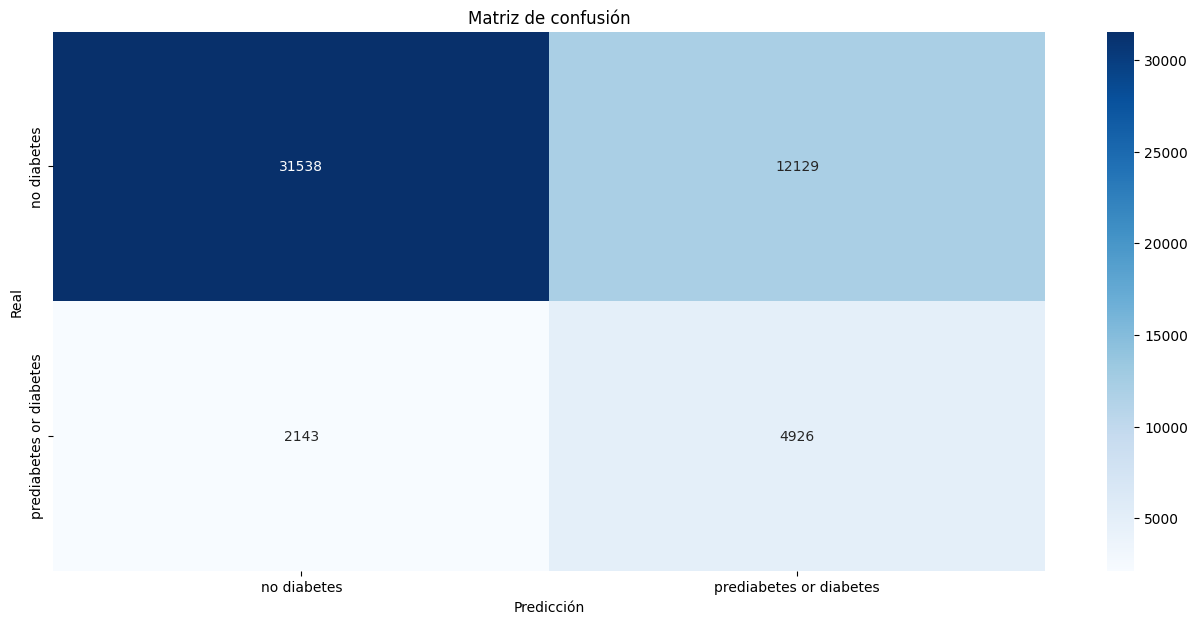

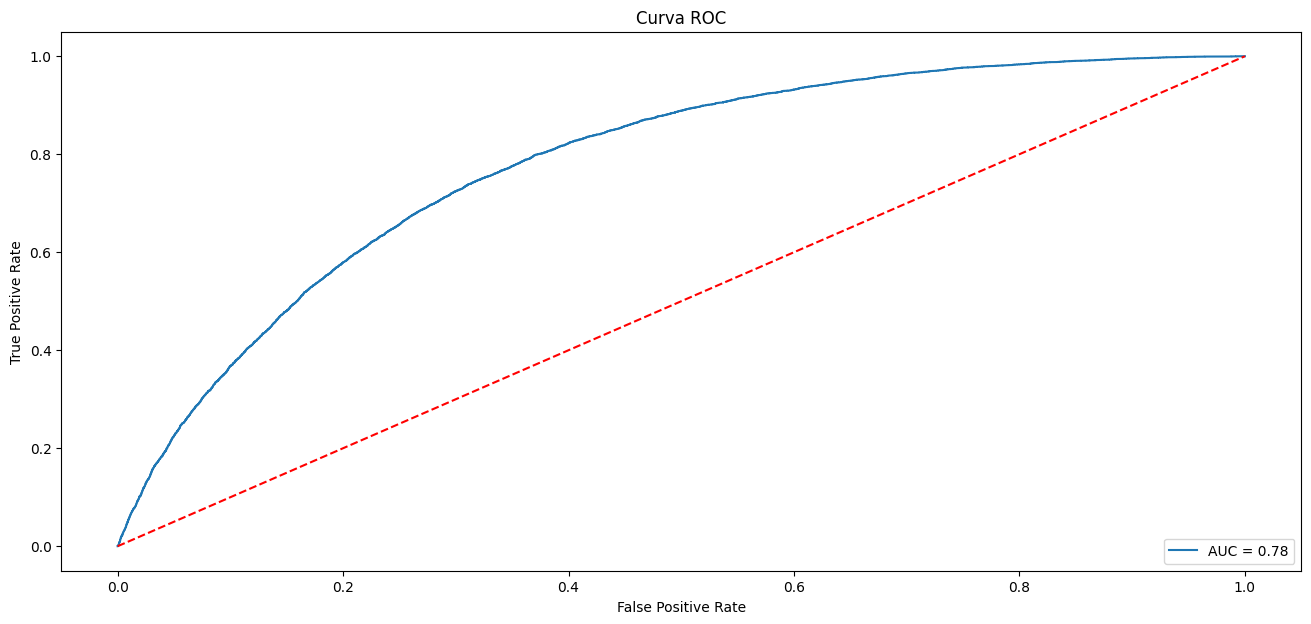

In [108]:
from IPython.display import Image, display

display(Image(filename="C:/Users/david/Downloads/Matriz_logi_all.png"))
display(Image(filename="C:/Users\david/Downloads/curva_logi_all.png"))

**Interpretación**

El análisis comparativo entre el modelo con eliminación de variables por multicolinealidad utilizando un umbral de 10 (seleccionado como óptimo) y el modelo sin eliminación de variables revela diferencias significativas en el desempeño que demuestran el impacto crítico del tratamiento de multicolinealidad:

**Análisis de Métricas:**

1. **Accuracy:**
   - **Sin eliminación**: 71.87% 
   - **Con eliminación***: 70.42%
   - **Interpretación**: El modelo sin eliminación muestra un accuracy ligeramente superior (1.45 puntos porcentuales), lo que sugiere que la inclusión de variables correlacionadas puede mejorar marginalmente la capacidad predictiva general, pero a un costo potencial en la estabilidad del modelo.

2. **Precision:**
   - **Sin eliminación**: 28.88%
   - **Con eliminación**: 28.33%
   - **Interpretación:** La mejora en precision (0.55 puntos) es mínima, manteniéndose ambos modelos en un rango críticamente bajo que indica una alta tasa de falsos positivos.

3. **Recall:**
   - **Sin eliminación**: 69.68%
   - **Con eliminación**: 73.42%
   - **Interpretación**: Diferencia crucial. El modelo con eliminación de variables muestra una superioridad significativa (3.74 puntos) en recall, demostrando una mejor capacidad para detectar casos reales de diabetes. Esta es una ventaja decisiva en aplicaciones médicas.

4. **F1-score:**
   - **Sin eliminación**: 40.84%
   - **Con eliminación**: 40.89%
   - **Interpretación**: Ambos modelos mantienen un F1-score prácticamente idéntico, pero el modelo con eliminación de variables logra un mejor balance entre precision y recall.

Aunque el modelo sin eliminación muestra un accuracy ligeramente superior, esta ventaja es engañosa y se ve contrarrestada por su menor capacidad para identificar casos positivos reales (recall más bajo). En problemas médicos donde los falsos negativos tienen consecuencias graves, el modelo con eliminación de variables es claramente preferible.

### Evaluación del Modelo Logístico con un Umbral de VIF < 20

A continuación, se analiza el desempeño del modelo de Regresión Logística utilizando un umbral menos restrictivo (VIF > 20) para la eliminación iterativa de variables por multicolinealidad. Este enfoque permite conservar un mayor número de variables en el dataset, evaluando así el impacto de mantener predictores con niveles moderados de correlación en el rendimiento del modelo. La configuración mantiene todos los demás parámetros de preprocesamiento y entrenamiento idénticos a los utilizados en los modelos anteriores, aislando el efecto del umbral de VIF como variable de estudio.


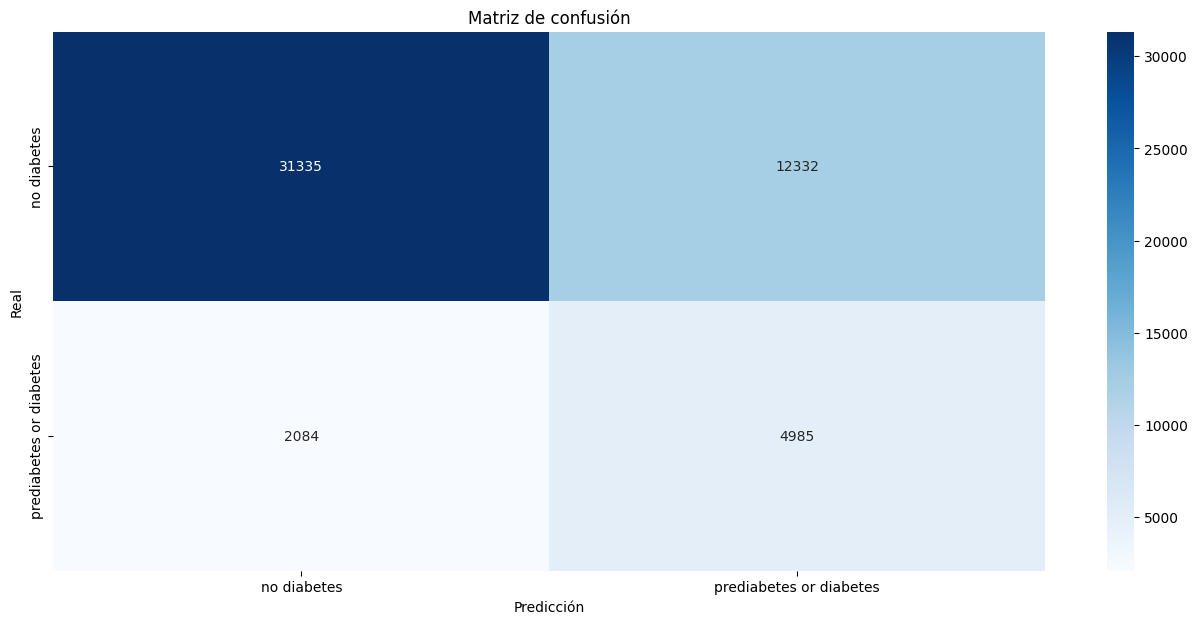

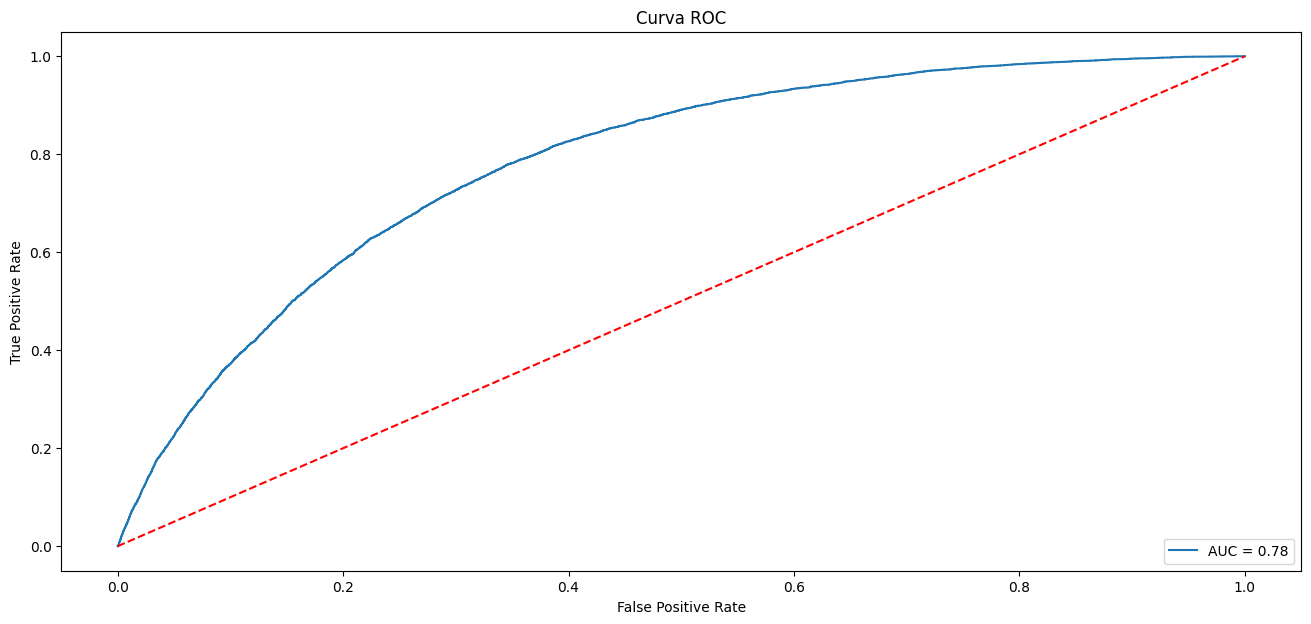

In [109]:
from IPython.display import Image, display

display(Image(filename="C:/Users/david/Downloads/matriz_logi_20.png"))
display(Image(filename="C:/Users/david/Downloads/curva_logi_20.png"))

**Interpretación**

1. **Accuracy y Precision:** El modelo con umbral VIF > 20 muestra una mejora marginal en accuracy (+1.1%) y precision (+0.5%), lo que sugiere que al ser menos restrictivo con la multicolinealidad se incluyen variables que aportan información útil para la clasificación general.

2. **Recall - Diferencia Crítica:** Se observa una pérdida significativa de recall (-2.9%), lo que indica que el modelo VIF < 20 falla en detectar aproximadamente un 3% más de casos reales de diabetes comparado con el modelo óptimo. Esto representa una desventaja crítica en el contexto médico.

3. **F1-score:** Ambos modelos mantienen esencialmente el mismo score de F1 (40.9% vs 40.8%), lo que indica un balance similar entre precision y recall, pero con diferente distribución.

4. **Estabilidad vs Sensibilidad:** El modelo menos restrictivo (VIF < 20) gana en capacidad predictiva general pero pierde en sensibilidad para detectar casos positivos.

El modelo con umbral VIF < 10 sigue siendo superior para aplicaciones médicas donde la detección de casos reales (recall) es la prioridad principal.

### Evaluación del Modelo KNN con un Umbral de VIF < 10

A continuación, se analiza el desempeño del modelo K-Nearest Neighbors (KNN) utilizando un umbral de VIF > 10 para la eliminación iterativa de variables por multicolinealidad. A diferencia de los modelos de Regresión Logística donde la multicolinealidad afecta directamente la estimación de coeficientes, en KNN el impacto se manifiesta en la calidad de la métrica de distancia y la ponderación de características redundantes. Este enfoque permite evaluar cómo influye la retención de variables moderadamente correlacionadas en la capacidad de clasificación de un modelo basado en instancias.

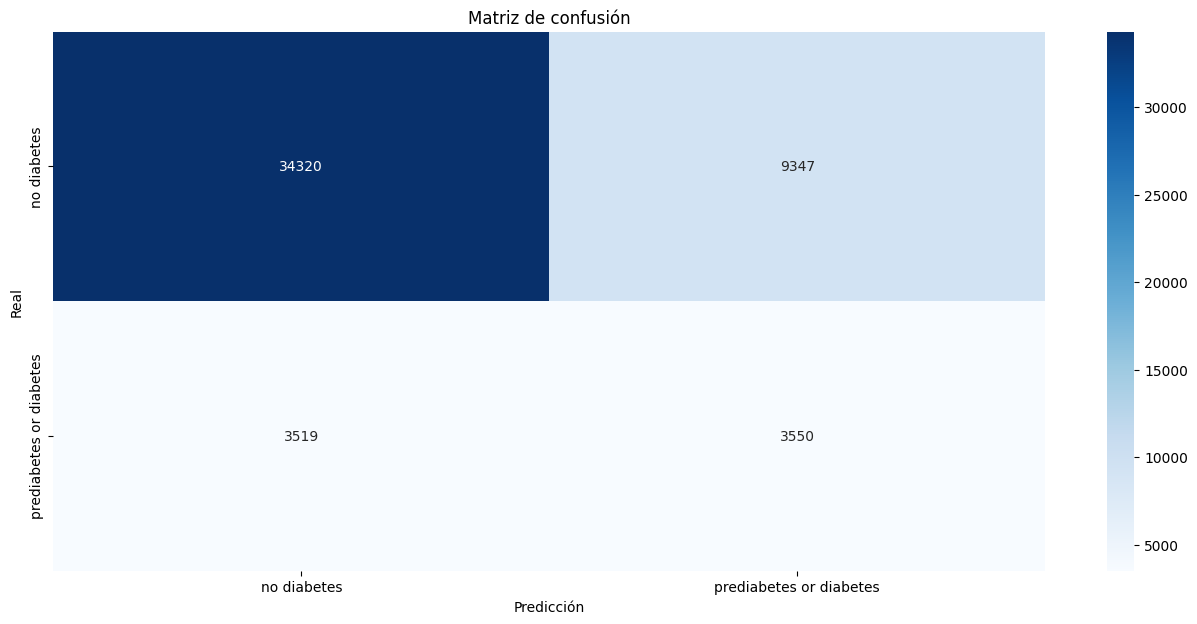

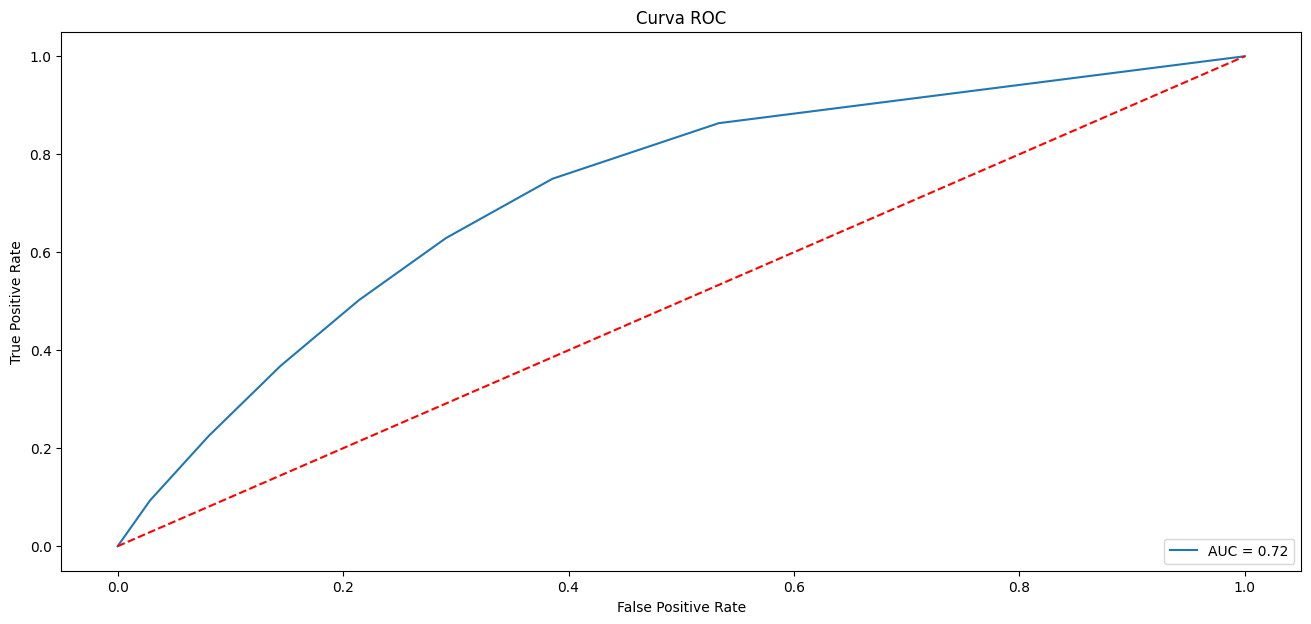

In [ ]:
from IPython.display import Image, display

display(Image(filename="C:/Users/david/Downloads/matriz_knn_10.png"))
display(Image(filename="C:/Users/david/Downloads/curva_knn_10.png"))

**Interpretación**

El análisis comparativo entre el modelo con eliminación de variables por multicolinealidad utilizando un umbral de 10 y el modelo sin eliminación de variables (seleccionado como óptimo) revela diferencias significativas en el desempeño que demuestran el impacto crítico del tratamiento de multicolinealidad:

1. **Accuracy**
   - El modelo con VIF < 10 muestra un accuracy significativamente mayor (74.64% vs 69.10%), pero esta mejora es engañosa.
   - El aumento de +5.54% sugiere mejor clasificación general, pero oculta un grave problema en la detección de casos positivos.

2. **Precision:**
   - La precision mejora en 2.45% (25.08% vs 27.53%), indicando una reducción moderada en falsos positivos.
   - Sin embargo, sigue siendo críticamente baja (solo 27.5% de aciertos en predicciones positivas).

3. **Recall**
   - Diferencia más significativa: El recall cae 11.06% (61.28% vs 50.22%).
   - Esto significa que el modelo VIF < 10 falla en detectar 1 de cada 2 casos reales de diabetes.
   - Para aplicaciones médicas, esta pérdida de sensibilidad es inaceptable.

4. **F1-score.**
   - Ambos modelos mantienen prácticamente el mismo F1-score (~35.6%), pero con distribuciones muy diferentes.
   - El modelo óptimo logra este balance con mejor recall, mientras el modelo VIF < 10 lo logra con mejor precision pero recall muy bajo.

El modelo KNN con umbral VIF < 10, si bien muestra una mejora engañosa en accuracy (+5.54%) y precision (+2.45%), resulta clínicamente inferior al modelo óptimo debido a su pérdida crítica de recall (-11.06%). En el contexto de predicción de diabetes, donde la detección de casos reales es prioritaria, este trade-off es inaceptable.

### Evaluación del Modelo KNN con un Umbral de VIF < 20

A continuación, se analiza el desempeño del modelo K-Nearest Neighbors (KNN) utilizando un umbral de VIF > 20 para la eliminación iterativa de variables por multicolinealidad. A diferencia de los modelos de Regresión Logística donde la multicolinealidad afecta directamente la estimación de coeficientes, en KNN el impacto se manifiesta en la calidad de la métrica de distancia y la ponderación de características redundantes. Este enfoque permite evaluar cómo influye la retención de variables moderadamente correlacionadas en la capacidad de clasificación de un modelo basado en instancias.

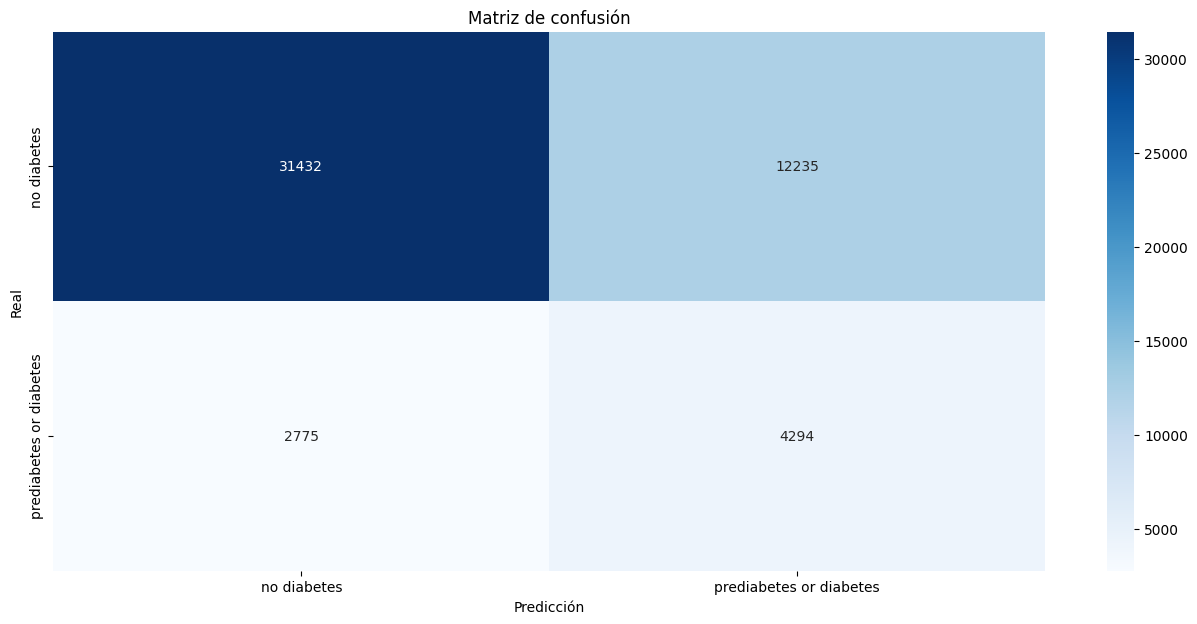

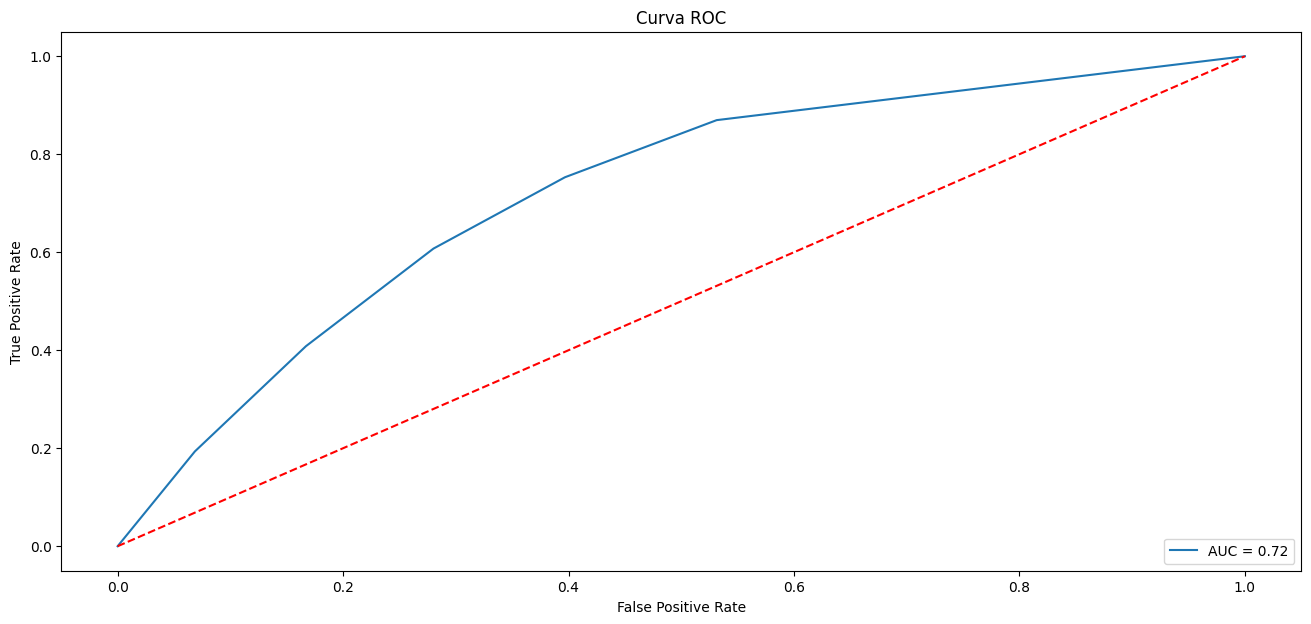

In [112]:
from IPython.display import Image, display

display(Image(filename="C:/Users/david/Downloads/matriz_knn_20.png"))
display(Image(filename="C:/Users/david/Downloads/curva_knn_20.png"))

**Interpretación**

Ambos modelos muestran el mismo patrón de trade-off: sacrifican precisión para ganar recall. El modelo con el umbral de VIF < 20 presenta más falsos positivos, lo que baja la precisión y genera ruido clínico (muchos pacientes sanos etiquetados como riesgo). El modelo más optimo consigue un recall mayor (0.61), lo que es positivo en un contexto médico porque se prioriza no dejar pasar casos de riesgo.

Entonces, el modelo más óptimo optimiza un poco más el recall, es preferible detectar a la mayoría de pacientes en riesgo aunque eso implique etiquetar a varios sanos por error. En un problema de salud pública como la diabetes, esta estrategia es razonable porque prioriza no dejar escapar pacientes que sí necesitan atención.

## Conclusión de los Modelos con otras configuraciones probadas

El proceso de exploración y evaluación de diferentes configuraciones en el tratamiento de la multicolinealidad demostró ser fundamental para identificar el modelo óptimo. La comparación sistemática de múltiples escenarios desde la inclusión total de variables hasta la aplicación de umbrales progresivamente más restrictivos permitió comprender cómo la estructura de los datos y las relaciones entre variables impactan el desempeño de los algoritmos.  

Esta metodología iterativa no solo validó la importancia de controlar la multicolinealidad en modelos sensibles como la regresión logística, sino que también destacó cómo el equilibrio entre la retención de información y la eliminación de ruido es clave para maximizar la capacidad predictiva. La rigurosidad en esta fase de experimentación aseguró que la selección final del modelo estuviera respaldada por evidencia empírica sólida, descartando configuraciones subóptimas y priorizando aquellas con el mejor balance entre interpretabilidad, estabilidad y rendimiento general.  